In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

def list_directory_tree(root_path, max_files_per_dir=3, indent=""):
    """
    Recursively prints the directory structure starting from root_path.
    Shows only up to `max_files_per_dir` files per directory.
    """
    try:
        # Get all entries in the directory
        entries = sorted(os.listdir(root_path))
    except FileNotFoundError:
        print(f"Error: Directory '{root_path}' not found.")
        return
    except PermissionError:
        print(f"Error: Permission denied for '{root_path}'.")
        return

    # Separate directories and files
    dirs = [d for d in entries if os.path.isdir(os.path.join(root_path, d))]
    files = [f for f in entries if os.path.isfile(os.path.join(root_path, f))]

    # Print directories first
    for d in dirs:
        print(f"{indent}📁 {d}/")
        list_directory_tree(os.path.join(root_path, d), max_files_per_dir, indent + "    ")

    # Print only a few files
    for f in files[:max_files_per_dir]:
        print(f"{indent}📄 {f}")

    # Indicate if there are more files
    if len(files) > max_files_per_dir:
        print(f"{indent}... ({len(files) - max_files_per_dir} more files)")

if __name__ == "__main__":
    # Example usage
    path = input("Enter directory path: ").strip()
    if not os.path.isdir(path):
        print("Invalid directory path.")
    else:
        list_directory_tree(path, max_files_per_dir=3)


Enter directory path: /content/drive/MyDrive/Module 1
📁 .ipynb_checkpoints/
📁 Attention_BiLSTM_BiGRU/
    📁 ablation_A1_No_EfficientNetV2/
        📁 features/
            📄 test_features.npz
            📄 train_features.npz
            📄 val_features.npz
        📁 models/
            📄 A1_xgboost.pkl
        📁 results/
            📄 A1_complete_results.json
            📄 A1_confusion_matrix.csv
            📄 A1_test_metrics.csv
            ... (2 more files)
    📁 ablation_A2_No_MobileNetV3/
        📁 features/
            📄 test_features.npz
            📄 train_features.npz
            📄 val_features.npz
        📁 models/
            📄 A2_xgboost.pkl
        📁 results/
            📄 A2_complete_results.json
            📄 A2_confusion_matrix.csv
            📄 A2_test_metrics.csv
            ... (2 more files)
    📁 ablation_A3_No_BiGRU/
        📁 features/
            📄 A3_test_features.npz
            📄 A3_train_features.npz
            📄 A3_val_features.npz
            ... (3 more fi

In [ ]:
!pip install opencv-python librosa tqdm pandas torch torchvision
!pip install imgaug

# Install Optuna and XGBoost for the hybrid model and hyperparameter tuning
!pip install optuna xgboost

# Install a specific NumPy version compatible with imgaug (0.4.0) to avoid AttributeError: np.sctypes
!pip install numpy==1.26.4

print("-------------------------------------------------------------------")
print("IMPORTANT: Please restart your Colab runtime (Runtime -> Restart runtime) NOW, before proceeding.")
print("-------------------------------------------------------------------")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 132.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", 

-------------------------------------------------------------------
IMPORTANT: Please restart your Colab runtime (Runtime -> Restart runtime) NOW, before proceeding.
-------------------------------------------------------------------


#Data Inspection

In [ ]:
# ================================================================
# POST-RESTART RECOVERY CELL
# Recreates datasets + dataloaders + core runtime variables
# WITHOUT training the original model
# ================================================================

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ----------------------------------------------------------------
# GPU MEMORY CLEANUP
# ----------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ----------------------------------------------------------------
# REPRODUCIBILITY
# ----------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ----------------------------------------------------------------
# MAIN DIRECTORIES
# ----------------------------------------------------------------

EXPERIMENT_DIR = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)

FEATURE_DIR = (
    EXPERIMENT_DIR /
    "fused_features"
)

RESULTS_DIR = (
    EXPERIMENT_DIR /
    "results"
)

ABLATION_DIR = (
    EXPERIMENT_DIR /
    "ablation_results"
)

ABLATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ----------------------------------------------------------------
# FEATURE FILES
# ----------------------------------------------------------------

TRAIN_FEATURES = (
    FEATURE_DIR /
    "train_features.npz"
)

VAL_FEATURES = (
    FEATURE_DIR /
    "val_features.npz"
)

TEST_FEATURES = (
    FEATURE_DIR /
    "test_features.npz"
)

# ----------------------------------------------------------------
# DATASET / CSV FILE DISCOVERY
# ----------------------------------------------------------------

def find_csv(filename):
    candidates = [

        EXPERIMENT_DIR / filename,

        EXPERIMENT_DIR / "metadata" / filename,

        EXPERIMENT_DIR / "csv" / filename,

        EXPERIMENT_DIR / "data" / filename,

    ]

    for path in candidates:
        if path.exists():
            return path

    return None


TRAIN_CSV = find_csv("train.csv")
VAL_CSV   = find_csv("val.csv")
TEST_CSV  = find_csv("test.csv")


# ----------------------------------------------------------------
# FALLBACK: SEARCH EXPERIMENT DIRECTORY
# ----------------------------------------------------------------

if TRAIN_CSV is None:

    matches = list(
        EXPERIMENT_DIR.rglob("train.csv")
    )

    if matches:
        TRAIN_CSV = matches[0]


if VAL_CSV is None:

    matches = list(
        EXPERIMENT_DIR.rglob("val.csv")
    )

    if matches:
        VAL_CSV = matches[0]


if TEST_CSV is None:

    matches = list(
        EXPERIMENT_DIR.rglob("test.csv")
    )

    if matches:
        TEST_CSV = matches[0]


# ----------------------------------------------------------------
# LOAD FEATURE CACHE
# ----------------------------------------------------------------

if not TRAIN_FEATURES.exists():
    raise FileNotFoundError(
        f"Training feature file not found:\n{TRAIN_FEATURES}"
    )

if not VAL_FEATURES.exists():
    raise FileNotFoundError(
        f"Validation feature file not found:\n{VAL_FEATURES}"
    )

if not TEST_FEATURES.exists():
    raise FileNotFoundError(
        f"Test feature file not found:\n{TEST_FEATURES}"
    )


train_npz = np.load(
    TRAIN_FEATURES,
    allow_pickle=True
)

val_npz = np.load(
    VAL_FEATURES,
    allow_pickle=True
)

test_npz = np.load(
    TEST_FEATURES,
    allow_pickle=True
)


# ----------------------------------------------------------------
# HANDLE DIFFERENT NPZ KEY NAMES
# ----------------------------------------------------------------

def get_npz_array(npz_file, possible_keys):

    available = list(
        npz_file.files
    )

    for key in possible_keys:

        if key in available:
            return npz_file[key]

    raise KeyError(
        f"None of {possible_keys} found. "
        f"Available keys: {available}"
    )


X_train = get_npz_array(
    train_npz,
    ["features", "X", "embeddings"]
).astype(np.float32)

y_train = get_npz_array(
    train_npz,
    ["labels", "y", "targets"]
).astype(np.int64)


X_val = get_npz_array(
    val_npz,
    ["features", "X", "embeddings"]
).astype(np.float32)

y_val = get_npz_array(
    val_npz,
    ["labels", "y", "targets"]
).astype(np.int64)


X_test = get_npz_array(
    test_npz,
    ["features", "X", "embeddings"]
).astype(np.float32)

y_test = get_npz_array(
    test_npz,
    ["labels", "y", "targets"]
).astype(np.int64)


# ----------------------------------------------------------------
# LOAD CSV METADATA IF AVAILABLE
# ----------------------------------------------------------------

train_df = None
val_df = None
test_df = None


if TRAIN_CSV is not None:
    train_df = pd.read_csv(TRAIN_CSV)

if VAL_CSV is not None:
    val_df = pd.read_csv(VAL_CSV)

if TEST_CSV is not None:
    test_df = pd.read_csv(TEST_CSV)


# ----------------------------------------------------------------
# DATASET CLASS
# ----------------------------------------------------------------

class FeatureDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        features,
        labels
    ):

        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, index):

        return {
            "features":
                self.features[index],

            "label":
                self.labels[index]
        }


# ----------------------------------------------------------------
# CREATE FEATURE DATASETS
# ----------------------------------------------------------------

train_dataset = FeatureDataset(
    X_train,
    y_train
)

val_dataset = FeatureDataset(
    X_val,
    y_val
)

test_dataset = FeatureDataset(
    X_test,
    y_test
)


# ----------------------------------------------------------------
# DATALOADERS
# ----------------------------------------------------------------

BATCH_SIZE = 4

NUM_WORKERS = 2


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    )

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    )

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    )

)


# ----------------------------------------------------------------
# BASIC CONFIGURATION
# ----------------------------------------------------------------

CONFIG = {

    "num_classes": 2,

    "batch_size": BATCH_SIZE,

    "seed": SEED,

    "device": str(DEVICE)

}


# ----------------------------------------------------------------
# METRIC IMPORTS
# ----------------------------------------------------------------

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix

)


# ----------------------------------------------------------------
# METRIC FUNCTION
# ----------------------------------------------------------------

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    try:

        auroc = roc_auc_score(
            y_true,
            y_prob[:, 1]
        )

    except Exception:

        auroc = float("nan")

    return {

        "accuracy": float(accuracy),

        "precision": float(precision),

        "recall": float(recall),

        "f1": float(f1),

        "fpr": float(fpr),

        "auroc": float(auroc),

        "tn": int(tn),

        "fp": int(fp),

        "fn": int(fn),

        "tp": int(tp)

    }


# ----------------------------------------------------------------
# VERIFY
# ----------------------------------------------------------------

assert len(train_dataset) == len(y_train)
assert len(val_dataset) == len(y_val)
assert len(test_dataset) == len(y_test)

print(
    f"Runtime restored | "
    f"Device: {DEVICE} | "
    f"Train: {len(train_dataset)} | "
    f"Val: {len(val_dataset)} | "
    f"Test: {len(test_dataset)}"
)

Runtime restored | Device: cuda | Train: 248 | Val: 115 | Test: 116


In [ ]:
# ============================================================
# CELL 2 — DATASET ROOT
# ============================================================

from pathlib import Path

ROOT = Path("/content/drive/MyDrive/VIT_DATASETS")

print("Dataset root:")
print(ROOT)

print("\nExists:", ROOT.exists())

Dataset root:
/content/drive/MyDrive/VIT_DATASETS

Exists: True


In [ ]:
# ============================================================
# CELL 4 — LOAD TRAIN / VALIDATION / TEST SPLITS
# ============================================================

import pandas as pd

TRAIN_CSV = ROOT / "splits" / "train.csv"
VAL_CSV   = ROOT / "splits" / "val.csv"
TEST_CSV  = ROOT / "splits" / "test.csv"

print("Train CSV exists:", TRAIN_CSV.exists())
print("Validation CSV exists:", VAL_CSV.exists())
print("Test CSV exists:", TEST_CSV.exists())

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("\nTRAIN SHAPE:", train_df.shape)
print("VALIDATION SHAPE:", val_df.shape)
print("TEST SHAPE:", test_df.shape)

Train CSV exists: True
Validation CSV exists: True
Test CSV exists: True

TRAIN SHAPE: (248, 9)
VALIDATION SHAPE: (115, 9)
TEST SHAPE: (116, 9)


In [ ]:
# ============================================================
# CELL 5 — INSPECT CSV STRUCTURE
# ============================================================

print("TRAIN COLUMNS")
print(train_df.columns.tolist())

print("\nTRAIN")
display(train_df.head(10))

print("\nVALIDATION")
display(val_df.head(10))

print("\nTEST")
display(test_df.head(10))

TRAIN COLUMNS
['dataset', 'video', 'label', 'frames', 'audio', 'spectrogram', 'pose', 'source', 'subject']

TRAIN


,dataset,video,label,frames,audio,spectrogram,pose,source,subject
0,youtube,clip_054,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
1,youtube,clip_050,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
2,youtube,clip_027,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
3,youtube,clip_037,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
4,youtube,clip_073,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
5,youtube,clip_009,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
6,youtube,clip_106,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
7,youtube,clip_077,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
8,youtube,clip_078,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
9,youtube,clip_092,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN



VALIDATION


,dataset,video,label,frames,audio,spectrogram,pose,source,subject
0,youtube,clip_032,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
1,youtube,8:18-8:28,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
2,youtube,clip_045,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
3,youtube,clip_071,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
4,youtube,clip_079,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
5,youtube,clip_028,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
6,youtube,clip_010,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
7,youtube,clip_114,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
8,youtube,clip_004,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
9,youtube,clip_057,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN



TEST


,dataset,video,label,frames,audio,spectrogram,pose,source,subject
0,youtube,clip_096,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
1,youtube,clip_064,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
2,youtube,clip_084,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
3,youtube,clip_049,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
4,youtube,clip_087,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
5,youtube,clip_036,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
6,youtube,clip_017,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
7,youtube,clip_107,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
8,youtube,clip_059,Positive,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN
9,youtube,clip_021,Negative,/content/drive/MyDrive/VIT_DATASETS/youtube/fr...,/content/drive/MyDrive/VIT_DATASETS/youtube/au...,/content/drive/MyDrive/VIT_DATASETS/youtube/sp...,NaN,youtube_original,NaN


In [ ]:
# ============================================================
# CELL 6 — DATASET DISTRIBUTION
# ============================================================

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("\nDataset:")
    print(df["dataset"].value_counts(dropna=False))

    print("\nSource:")
    print(df["source"].value_counts(dropna=False))

    print("\nLabel:")
    print(df["label"].value_counts(dropna=False))


TRAIN

Dataset:
dataset
turning    178
youtube     70
Name: count, dtype: int64

Source:
source
turning_original     89
turning_augmented    89
youtube_original     70
Name: count, dtype: int64

Label:
label
Positive    128
Negative    120
Name: count, dtype: int64

VALIDATION

Dataset:
dataset
turning    92
youtube    23
Name: count, dtype: int64

Source:
source
turning_original     46
turning_augmented    46
youtube_original     23
Name: count, dtype: int64

Label:
label
Positive    59
Negative    56
Name: count, dtype: int64

TEST

Dataset:
dataset
turning    92
youtube    24
Name: count, dtype: int64

Source:
source
turning_original     46
turning_augmented    46
youtube_original     24
Name: count, dtype: int64

Label:
label
Positive    60
Negative    56
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 7 — TURNING DATASET INSPECTION
# ============================================================

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    turning = df[df["dataset"].astype(str).str.lower() == "turning"]

    print("\n" + "=" * 60)
    print(name, "— TURNING")
    print("=" * 60)

    print("Number of turning samples:", len(turning))

    if len(turning) > 0:

        print("\nSources:")
        print(turning["source"].value_counts(dropna=False))

        print("\nLabels:")
        print(turning["label"].value_counts(dropna=False))

        print("\nAudio availability:")
        print(turning["audio"].notna().value_counts())

        print("\nSpectrogram availability:")
        print(turning["spectrogram"].notna().value_counts())

        print("\nPose availability:")
        print(turning["pose"].notna().value_counts())

        display(turning.head(10))


TRAIN — TURNING
Number of turning samples: 178

Sources:
source
turning_original     89
turning_augmented    89
Name: count, dtype: int64

Labels:
label
Positive    89
Negative    89
Name: count, dtype: int64

Audio availability:
audio
False    178
Name: count, dtype: int64

Spectrogram availability:
spectrogram
False    178
Name: count, dtype: int64

Pose availability:
pose
True    178
Name: count, dtype: int64


,dataset,video,label,frames,audio,spectrogram,pose,source,subject
70,turning,PDFE02_1_clip_000,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
71,turning,PDFE02_1_clip_002,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
72,turning,PDFE02_1_clip_001,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
73,turning,PDFE02_1_clip_003,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
74,turning,PDFE02_1_clip_004,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
75,turning,PDFE02_1_clip_005,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
76,turning,PDFE02_1_clip_006,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
77,turning,PDFE02_1_clip_007,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
78,turning,PDFE02_1_clip_009,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1
79,turning,PDFE02_1_clip_010,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE02_1



VALIDATION — TURNING
Number of turning samples: 92

Sources:
source
turning_original     46
turning_augmented    46
Name: count, dtype: int64

Labels:
label
Positive    46
Negative    46
Name: count, dtype: int64

Audio availability:
audio
False    92
Name: count, dtype: int64

Spectrogram availability:
spectrogram
False    92
Name: count, dtype: int64

Pose availability:
pose
True    92
Name: count, dtype: int64


,dataset,video,label,frames,audio,spectrogram,pose,source,subject
23,turning,PDFE01_1_clip_000,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
24,turning,PDFE01_1_clip_001,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
25,turning,PDFE01_1_clip_002,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
26,turning,PDFE01_1_clip_003,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
27,turning,PDFE01_1_clip_004,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
28,turning,PDFE01_1_clip_005,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
29,turning,PDFE01_1_clip_006,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
30,turning,PDFE01_1_clip_007,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
31,turning,PDFE01_1_clip_008,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1
32,turning,PDFE01_1_clip_009,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_1



TEST — TURNING
Number of turning samples: 92

Sources:
source
turning_original     46
turning_augmented    46
Name: count, dtype: int64

Labels:
label
Positive    46
Negative    46
Name: count, dtype: int64

Audio availability:
audio
False    92
Name: count, dtype: int64

Spectrogram availability:
spectrogram
False    92
Name: count, dtype: int64

Pose availability:
pose
True    92
Name: count, dtype: int64


,dataset,video,label,frames,audio,spectrogram,pose,source,subject
24,turning,PDFE01_2_clip_000,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
25,turning,PDFE01_2_clip_001,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
26,turning,PDFE01_2_clip_003,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
27,turning,PDFE01_2_clip_005,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
28,turning,PDFE01_2_clip_002,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
29,turning,PDFE01_2_clip_004,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
30,turning,PDFE01_2_clip_006,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
31,turning,PDFE01_2_clip_007,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
32,turning,PDFE01_2_clip_008,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2
33,turning,PDFE01_2_clip_009,Positive,/content/drive/MyDrive/VIT_DATASETS/turning/fr...,NaN,NaN,/content/drive/MyDrive/VIT_DATASETS/turning/po...,turning_original,PDFE01_2


In [ ]:
# ============================================================
# CELL 8 — PATH EXISTENCE CHECK
# ============================================================

from pathlib import Path
import pandas as pd

def check_path_column(df, column):

    paths = df[column].dropna().astype(str)

    if len(paths) == 0:
        return {
            "column": column,
            "total": 0,
            "exists": 0,
            "missing": 0
        }

    exists = paths.apply(lambda x: Path(x).exists())

    return {
        "column": column,
        "total": len(paths),
        "exists": int(exists.sum()),
        "missing": int((~exists).sum())
    }


for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    for column in [
        "frames",
        "audio",
        "spectrogram",
        "pose"
    ]:

        result = check_path_column(df, column)
        print(result)


TRAIN
{'column': 'frames', 'total': 248, 'exists': 248, 'missing': 0}
{'column': 'audio', 'total': 70, 'exists': 70, 'missing': 0}
{'column': 'spectrogram', 'total': 70, 'exists': 70, 'missing': 0}
{'column': 'pose', 'total': 178, 'exists': 178, 'missing': 0}

VALIDATION
{'column': 'frames', 'total': 115, 'exists': 115, 'missing': 0}
{'column': 'audio', 'total': 23, 'exists': 23, 'missing': 0}
{'column': 'spectrogram', 'total': 23, 'exists': 23, 'missing': 0}
{'column': 'pose', 'total': 92, 'exists': 92, 'missing': 0}

TEST
{'column': 'frames', 'total': 116, 'exists': 116, 'missing': 0}
{'column': 'audio', 'total': 24, 'exists': 24, 'missing': 0}
{'column': 'spectrogram', 'total': 24, 'exists': 24, 'missing': 0}
{'column': 'pose', 'total': 92, 'exists': 92, 'missing': 0}


In [ ]:
# ============================================================
# CELL 9 — INSPECT ONE YOUTUBE SAMPLE
# ============================================================

youtube_sample = train_df[
    train_df["dataset"].astype(str).str.lower() == "youtube"
].iloc[0]

print("VIDEO:")
print(youtube_sample["video"])

print("\nLABEL:")
print(youtube_sample["label"])

print("\nFRAMES:")
print(youtube_sample["frames"])

print("\nAUDIO:")
print(youtube_sample["audio"])

print("\nSPECTROGRAM:")
print(youtube_sample["spectrogram"])

print("\nPOSE:")
print(youtube_sample["pose"])

print("\nSOURCE:")
print(youtube_sample["source"])

print("\nSUBJECT:")
print(youtube_sample["subject"])

VIDEO:
clip_054

LABEL:
Positive

FRAMES:
/content/drive/MyDrive/VIT_DATASETS/youtube/frames/Positive/clip_054

AUDIO:
/content/drive/MyDrive/VIT_DATASETS/youtube/audio/Positive/clip_054.wav

SPECTROGRAM:
/content/drive/MyDrive/VIT_DATASETS/youtube/spectrograms/Positive/clip_054.npy

POSE:
nan

SOURCE:
youtube_original

SUBJECT:
nan


In [ ]:
# ============================================================
# CELL 10 — INSPECT ONE YOUTUBE SAMPLE'S FILES
# ============================================================

from pathlib import Path

sample_frames = Path(youtube_sample["frames"])
sample_audio = Path(youtube_sample["audio"])
sample_spec = Path(youtube_sample["spectrogram"])

print("=" * 60)
print("FRAMES")
print("=" * 60)

print("Path:", sample_frames)
print("Exists:", sample_frames.exists())
print("Is directory:", sample_frames.is_dir())

if sample_frames.exists() and sample_frames.is_dir():

    files = sorted(sample_frames.iterdir())

    print("Number of files:", len(files))

    for f in files[:10]:
        print(f.name)


print("\n" + "=" * 60)
print("AUDIO")
print("=" * 60)

print("Path:", sample_audio)
print("Exists:", sample_audio.exists())

if sample_audio.exists():
    print("Is file:", sample_audio.is_file())
    print("Suffix:", sample_audio.suffix)


print("\n" + "=" * 60)
print("SPECTROGRAM")
print("=" * 60)

print("Path:", sample_spec)
print("Exists:", sample_spec.exists())

if sample_spec.exists():
    print("Is file:", sample_spec.is_file())
    print("Suffix:", sample_spec.suffix)

FRAMES
Path: /content/drive/MyDrive/VIT_DATASETS/youtube/frames/Positive/clip_054
Exists: True
Is directory: True
Number of files: 32
frame_000.png
frame_001.png
frame_002.png
frame_003.png
frame_004.png
frame_005.png
frame_006.png
frame_007.png
frame_008.png
frame_009.png

AUDIO
Path: /content/drive/MyDrive/VIT_DATASETS/youtube/audio/Positive/clip_054.wav
Exists: True
Is file: True
Suffix: .wav

SPECTROGRAM
Path: /content/drive/MyDrive/VIT_DATASETS/youtube/spectrograms/Positive/clip_054.npy
Exists: True
Is file: True
Suffix: .npy


In [ ]:
# ============================================================
# CELL 11 — SUBJECT LEAKAGE CHECK
# ============================================================

def get_subjects(df):
    return set(
        df["subject"]
        .dropna()
        .astype(str)
        .unique()
    )


train_subjects = get_subjects(train_df)
val_subjects   = get_subjects(val_df)
test_subjects  = get_subjects(test_df)

print("=" * 60)
print("SUBJECT SPLIT CHECK")
print("=" * 60)

print("Train subjects:", sorted(train_subjects))
print("\nValidation subjects:", sorted(val_subjects))
print("\nTest subjects:", sorted(test_subjects))

print("\n" + "=" * 60)
print("OVERLAP")
print("=" * 60)

print("Train ∩ Validation:",
      train_subjects & val_subjects)

print("Train ∩ Test:",
      train_subjects & test_subjects)

print("Validation ∩ Test:",
      val_subjects & test_subjects)

SUBJECT SPLIT CHECK
Train subjects: ['PDFE02_1', 'PDFE03_1', 'PDFE03_2', 'PDFE04_1']

Validation subjects: ['PDFE01_1', 'PDFE03_3']

Test subjects: ['PDFE01_2', 'PDFE05_1']

OVERLAP
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [ ]:
# ============================================================
# CELL 15 — INSPECT ORIGINAL TURNING FRAME FORMAT
# ============================================================

turning_original = train_df[
    train_df["source"] == "turning_original"
].iloc[0]

original_frames_path = Path(turning_original["frames"])

print("Original Turning sample")
print("=" * 60)

print("Video:", turning_original["video"])
print("Label:", turning_original["label"])
print("Frames path:", original_frames_path)
print("Exists:", original_frames_path.exists())
print("Is directory:", original_frames_path.is_dir())
print("Is file:", original_frames_path.is_file())

if original_frames_path.exists():

    if original_frames_path.is_dir():

        files = sorted(original_frames_path.iterdir())

        print("\nNumber of files:", len(files))

        for f in files[:10]:
            print(f.name)

    elif original_frames_path.is_file():

        print("\nFile suffix:", original_frames_path.suffix)

Original Turning sample
Video: PDFE02_1_clip_000
Label: Positive
Frames path: /content/drive/MyDrive/VIT_DATASETS/turning/frames/PDFE02_1/clip_000
Exists: True
Is directory: True
Is file: False

Number of files: 32
frame_000.png
frame_001.png
frame_002.png
frame_003.png
frame_004.png
frame_005.png
frame_006.png
frame_007.png
frame_008.png
frame_009.png


In [ ]:
# ============================================================
# CELL 16 — INSPECT AUGMENTED TURNING NPY
# ============================================================

augmented = train_df[
    train_df["source"] == "turning_augmented"
].iloc[0]

aug_frames_path = Path(augmented["frames"])

print("Augmented Turning sample")
print("=" * 60)

print("Video:", augmented["video"])
print("Label:", augmented["label"])
print("Frames path:", aug_frames_path)
print("Exists:", aug_frames_path.exists())
print("Is file:", aug_frames_path.is_file())

aug_frames = np.load(aug_frames_path)

print("\nNumPy array")
print("Shape:", aug_frames.shape)
print("dtype:", aug_frames.dtype)
print("min:", aug_frames.min())
print("max:", aug_frames.max())
print("mean:", aug_frames.mean())

Augmented Turning sample
Video: PDFE02_1_clip_000_aug
Label: Negative
Frames path: /content/drive/MyDrive/VIT_DATASETS/turning_aug/frames/PDFE02_1/clip_000_aug.npy
Exists: True
Is file: True

NumPy array
Shape: (32, 224, 224, 3)
dtype: uint8
min: 0
max: 255
mean: 136.02644960572118


In [ ]:
# ============================================================
# CELL 17 — INSPECT TURNING POSE
# ============================================================

pose_path = Path(augmented["pose"])

print("Pose path:")
print(pose_path)

print("\nExists:", pose_path.exists())

if pose_path.exists():

    pose = np.load(pose_path)

    print("Pose shape:", pose.shape)
    print("Pose dtype:", pose.dtype)
    print("Pose min:", pose.min())
    print("Pose max:", pose.max())

Pose path:
/content/drive/MyDrive/VIT_DATASETS/turning_aug/poses/PDFE02_1/clip_000_aug.npy

Exists: True
Pose shape: (32, 17, 3)
Pose dtype: float64
Pose min: -0.00865910665197658
Pose max: 168.73519273913598


In [ ]:
# ============================================================
# CELL 14 — INSPECT AUDIO SPECTROGRAM
# ============================================================

import numpy as np

youtube_sample = train_df[
    train_df["dataset"] == "youtube"
].iloc[0]

spec_path = youtube_sample["spectrogram"]

spec = np.load(spec_path)

print("Spectrogram path:")
print(spec_path)

print("\nSpectrogram type:")
print(type(spec))

print("\nSpectrogram shape:")
print(spec.shape)

print("\nData type:")
print(spec.dtype)

print("\nMinimum:")
print(spec.min())

print("\nMaximum:")
print(spec.max())

print("\nMean:")
print(spec.mean())

print("\nStandard deviation:")
print(spec.std())

Spectrogram path:
/content/drive/MyDrive/VIT_DATASETS/youtube/spectrograms/Positive/clip_054.npy

Spectrogram type:
<class 'numpy.ndarray'>

Spectrogram shape:
(128, 313)

Data type:
float32

Minimum:
-80.0

Maximum:
0.0

Mean:
-54.371273

Standard deviation:
15.957325


---

#Multimodal training

In [ ]:
# ================================================================
# PARKINSON MULTIMODAL MODEL
# EfficientNetV2 + MobileNetV3 + Attention-BiLSTM
#                 +
# Spectrogram + BiGRU
#                 +
# Adaptive Fusion + Softmax
#
# COMPLETE TRAINING PIPELINE
# ================================================================

import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from tqdm.auto import tqdm


# ================================================================
# 1. CONFIGURATION
# ================================================================

CONFIG = {

    # ------------------------------------------------------------
    # Paths
    # ------------------------------------------------------------

    "base_dir":
        "/content/drive/MyDrive/VIT_DATASETS",

    "train_csv":
        "/content/drive/MyDrive/VIT_DATASETS/splits/train.csv",

    "val_csv":
        "/content/drive/MyDrive/VIT_DATASETS/splits/val.csv",

    "test_csv":
        "/content/drive/MyDrive/VIT_DATASETS/splits/test.csv",

    "experiment_dir":
        "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU",

    # ------------------------------------------------------------
    # Training
    # ------------------------------------------------------------

    "batch_size": 4,

    "num_workers": 2,

    "epochs": 10,

    "learning_rate": 1e-4,

    "weight_decay": 1e-4,

    "patience": 4,

    # ------------------------------------------------------------
    # Video
    # ------------------------------------------------------------

    "num_frames": 32,

    "image_size": 224,

    # ------------------------------------------------------------
    # Audio
    # ------------------------------------------------------------

    "mel_bins": 128,

    "audio_width": 313,

    # ------------------------------------------------------------
    # Architecture
    # ------------------------------------------------------------

    "visual_hidden": 512,

    "audio_hidden": 256,

    "fusion_dim": 512,

    "num_classes": 2,

    # ------------------------------------------------------------
    # Reproducibility
    # ------------------------------------------------------------

    "seed": 42,

    # ------------------------------------------------------------
    # Performance
    # ------------------------------------------------------------

    "use_amp": True,

    "gradient_clip": 1.0,
}


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    # Reproducibility
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(CONFIG["seed"])


# ================================================================
# 3. DEVICE
# ================================================================

print("=" * 80)
print("ENVIRONMENT")
print("=" * 80)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

    print("Device:", DEVICE)
    print("GPU:", torch.cuda.get_device_name(0))

    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (
        1024 ** 3
    )

    print(f"GPU Memory: {gpu_memory:.2f} GB")

else:

    DEVICE = torch.device("cpu")

    print("Device:", DEVICE)

    print(
        "WARNING: CUDA is not available. "
        "This architecture will be very slow on CPU."
    )


# ================================================================
# 4. CREATE EXPERIMENT DIRECTORIES
# ================================================================

EXPERIMENT_DIR = Path(CONFIG["experiment_dir"])

CHECKPOINT_DIR = EXPERIMENT_DIR / "checkpoints"

RESULT_DIR = EXPERIMENT_DIR / "results"

LOG_DIR = EXPERIMENT_DIR / "logs"

CONFIG_DIR = EXPERIMENT_DIR / "config"

for directory in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    RESULT_DIR,
    LOG_DIR,
    CONFIG_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


LATEST_CHECKPOINT = CHECKPOINT_DIR / "latest.pt"

BEST_CHECKPOINT = CHECKPOINT_DIR / "best.pt"

HISTORY_FILE = RESULT_DIR / "training_history.csv"

TEST_RESULTS_FILE = RESULT_DIR / "test_results.json"

CONFIG_FILE = CONFIG_DIR / "config.json"


with open(CONFIG_FILE, "w") as f:

    json.dump(
        CONFIG,
        f,
        indent=4
    )


print()
print("=" * 80)
print("DIRECTORIES")
print("=" * 80)

print("EXPERIMENT:", EXPERIMENT_DIR)

print("LATEST:", LATEST_CHECKPOINT)

print("BEST:", BEST_CHECKPOINT)


# ================================================================
# 5. CHECK CSV FILES
# ================================================================

for csv_path in [
    CONFIG["train_csv"],
    CONFIG["val_csv"],
    CONFIG["test_csv"]
]:

    if not os.path.exists(csv_path):

        raise FileNotFoundError(
            f"CSV not found: {csv_path}"
        )


train_df = pd.read_csv(CONFIG["train_csv"])

val_df = pd.read_csv(CONFIG["val_csv"])

test_df = pd.read_csv(CONFIG["test_csv"])


print()
print("=" * 80)
print("DATASET SHAPES")
print("=" * 80)

print("Train:", train_df.shape)

print("Validation:", val_df.shape)

print("Test:", test_df.shape)


# ================================================================
# 6. REQUIRED COLUMNS
# ================================================================

REQUIRED_COLUMNS = [

    "dataset",
    "video",
    "label",
    "frames",
    "audio",
    "spectrogram",
    "pose",
    "source",
    "subject"

]


for df_name, df in [

    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)

]:

    missing = [
        c for c in REQUIRED_COLUMNS
        if c not in df.columns
    ]

    if missing:

        raise ValueError(
            f"{df_name} missing columns: {missing}"
        )


print("All required columns are present.")


# ================================================================
# 7. DATASET SUMMARY
# ================================================================

def dataset_summary(name, df):

    print()
    print("=" * 80)
    print(name)
    print("=" * 80)

    print("\nDataset:")
    print(df["dataset"].value_counts())

    print("\nSource:")
    print(df["source"].value_counts())

    print("\nLabels:")
    print(df["label"].value_counts())

    print("\nAudio availability:")
    print(df["audio"].notna().value_counts())

    print("\nSpectrogram availability:")
    print(df["spectrogram"].notna().value_counts())

    print("\nPose availability:")
    print(df["pose"].notna().value_counts())


dataset_summary("TRAIN", train_df)

dataset_summary("VALIDATION", val_df)

dataset_summary("TEST", test_df)


# ================================================================
# 8. SUBJECT LEAKAGE CHECK
# ================================================================

def clean_subjects(df):

    return set(
        df["subject"]
        .dropna()
        .astype(str)
        .unique()
    )


train_subjects = clean_subjects(train_df)

val_subjects = clean_subjects(val_df)

test_subjects = clean_subjects(test_df)


print()
print("=" * 80)
print("SUBJECT LEAKAGE CHECK")
print("=" * 80)

print("Train subjects:", sorted(train_subjects))

print("Validation subjects:", sorted(val_subjects))

print("Test subjects:", sorted(test_subjects))

print()

print(
    "Train ∩ Validation:",
    train_subjects.intersection(val_subjects)
)

print(
    "Train ∩ Test:",
    train_subjects.intersection(test_subjects)
)

print(
    "Validation ∩ Test:",
    val_subjects.intersection(test_subjects)
)


if (
    train_subjects.intersection(val_subjects)
    or
    train_subjects.intersection(test_subjects)
    or
    val_subjects.intersection(test_subjects)
):

    raise RuntimeError(
        "SUBJECT LEAKAGE DETECTED!"
    )

else:

    print("\n✓ No subject leakage detected.")


# ================================================================
# 9. IMAGE TRANSFORM
# ================================================================

image_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (
            CONFIG["image_size"],
            CONFIG["image_size"]
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]

    )

])


# ================================================================
# 10. HELPER FUNCTIONS
# ================================================================

def load_video_frames(frame_path):

    """
    Supports:

    1. Directory containing PNG/JPG frames
    2. .npy video arrays

    Returns:
        Tensor [T, C, H, W]
    """

    frame_path = Path(str(frame_path))

    frames = []

    # ------------------------------------------------------------
    # Case 1: .npy augmented turning video
    # ------------------------------------------------------------

    if frame_path.is_file() and frame_path.suffix.lower() == ".npy":

        arr = np.load(frame_path)

        # Expected:
        # [T,H,W,C]

        if arr.ndim != 4:

            raise ValueError(
                f"Unexpected video array shape: {arr.shape}"
            )

        total_frames = arr.shape[0]

        indices = np.linspace(
            0,
            total_frames - 1,
            CONFIG["num_frames"]
        ).astype(int)

        selected = arr[indices]

        for frame in selected:

            if frame.dtype != np.uint8:

                frame = np.clip(
                    frame,
                    0,
                    255
                ).astype(np.uint8)

            frames.append(
                image_transform(frame)
            )

    # ------------------------------------------------------------
    # Case 2: directory of frames
    # ------------------------------------------------------------

    elif frame_path.is_dir():

        files = sorted([

            p for p in frame_path.iterdir()

            if p.suffix.lower()
            in [".png", ".jpg", ".jpeg"]

        ])

        if len(files) == 0:

            raise RuntimeError(
                f"No image frames found: {frame_path}"
            )

        indices = np.linspace(

            0,

            len(files) - 1,

            CONFIG["num_frames"]

        ).astype(int)

        selected_files = [
            files[i]
            for i in indices
        ]

        for file in selected_files:

            img = Image.open(file).convert("RGB")

            arr = np.array(img)

            frames.append(
                image_transform(arr)
            )

    else:

        raise FileNotFoundError(
            f"Frame path does not exist: {frame_path}"
        )


    video = torch.stack(frames)

    return video


# ================================================================
# 11. AUDIO LOADING
# ================================================================

def load_spectrogram(path):

    """
    Returns:

        spectrogram:
            [1, 128, 313]

        mask:
            1 if audio exists
            0 otherwise
    """

    if (
        path is None
        or
        pd.isna(path)
        or
        str(path).strip() == ""
    ):

        return (

            torch.zeros(
                1,
                CONFIG["mel_bins"],
                CONFIG["audio_width"],
                dtype=torch.float32
            ),

            torch.tensor(
                0.0,
                dtype=torch.float32
            )

        )


    path = Path(str(path))

    if not path.exists():

        return (

            torch.zeros(
                1,
                CONFIG["mel_bins"],
                CONFIG["audio_width"],
                dtype=torch.float32
            ),

            torch.tensor(
                0.0,
                dtype=torch.float32
            )

        )


    spec = np.load(path).astype(
        np.float32
    )


    # ------------------------------------------------------------
    # Force [128, T]
    # ------------------------------------------------------------

    if spec.ndim == 3:

        spec = np.squeeze(spec)

    if spec.shape[0] != CONFIG["mel_bins"]:

        if spec.shape[1] == CONFIG["mel_bins"]:

            spec = spec.T

        else:

            spec = np.resize(

                spec,

                (
                    CONFIG["mel_bins"],
                    spec.shape[-1]
                )

            )


    # ------------------------------------------------------------
    # Fix variable temporal width
    # ------------------------------------------------------------

    target_width = CONFIG["audio_width"]

    current_width = spec.shape[1]


    if current_width < target_width:

        pad_width = target_width - current_width

        spec = np.pad(

            spec,

            (
                (0, 0),
                (0, pad_width)
            ),

            mode="constant",

            constant_values=0

        )


    elif current_width > target_width:

        spec = spec[:, :target_width]


    # ------------------------------------------------------------
    # Normalize
    # ------------------------------------------------------------

    mean = spec.mean()

    std = spec.std()

    if std > 1e-6:

        spec = (
            spec - mean
        ) / (
            std + 1e-6
        )


    spec = torch.tensor(
        spec,
        dtype=torch.float32
    ).unsqueeze(0)


    return (

        spec,

        torch.tensor(
            1.0,
            dtype=torch.float32
        )

    )


# ================================================================
# 12. DATASET
# ================================================================

class ParkinsonMultimodalDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    # IMPORTANT:
    # This fixes the current error.
    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]


        # --------------------------------------------------------
        # VIDEO
        # --------------------------------------------------------

        video = load_video_frames(
            row["frames"]
        )


        # --------------------------------------------------------
        # AUDIO
        # --------------------------------------------------------

        audio, audio_mask = load_spectrogram(
            row["spectrogram"]
        )


        # --------------------------------------------------------
        # LABEL
        # --------------------------------------------------------

        label_text = str(
            row["label"]
        ).strip().lower()


        if label_text == "positive":

            label = 1

        elif label_text == "negative":

            label = 0

        else:

            raise ValueError(
                f"Unknown label: {row['label']}"
            )


        return {

            "video": video,

            "audio": audio,

            "audio_mask": audio_mask,

            "label": torch.tensor(
                label,
                dtype=torch.long
            ),

            "video_id": str(
                row["video"]
            ),

            "dataset": str(
                row["dataset"]
            ),

            "source": str(
                row["source"]
            ),

            "subject": str(
                row["subject"]
            )

        }


# ================================================================
# 13. DATASETS
# ================================================================

train_dataset = ParkinsonMultimodalDataset(
    train_df,
    image_transform
)

val_dataset = ParkinsonMultimodalDataset(
    val_df,
    image_transform
)

test_dataset = ParkinsonMultimodalDataset(
    test_df,
    image_transform
)


print()
print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print("Train samples:", len(train_dataset))

print("Validation samples:", len(val_dataset))

print("Test samples:", len(test_dataset))


# ================================================================
# 14. DATA LOADERS
# ================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=True,

    num_workers=CONFIG["num_workers"],

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        CONFIG["num_workers"] > 0
    )

)


val_loader = DataLoader(

    val_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=False,

    num_workers=CONFIG["num_workers"],

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        CONFIG["num_workers"] > 0
    )

)


test_loader = DataLoader(

    test_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=False,

    num_workers=CONFIG["num_workers"],

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        CONFIG["num_workers"] > 0
    )

)


# ================================================================
# 15. DATA LOADER CHECK
# ================================================================

print()
print("=" * 80)
print("DATA LOADER CHECK")
print("=" * 80)

sample_batch = next(
    iter(train_loader)
)

print(
    "Video:",
    sample_batch["video"].shape
)

print(
    "Audio:",
    sample_batch["audio"].shape
)

print(
    "Audio mask:",
    sample_batch["audio_mask"]
)

print(
    "Labels:",
    sample_batch["label"]
)


# ================================================================
# 16. ATTENTION MODULE
# ================================================================

class TemporalAttention(nn.Module):

    def __init__(
        self,
        input_dim
    ):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Linear(
                input_dim,
                input_dim // 2
            ),

            nn.Tanh(),

            nn.Linear(
                input_dim // 2,
                1
            )

        )


    def forward(self, x):

        # x:
        # [B,T,D]

        scores = self.attention(x)

        # [B,T,1]

        weights = torch.softmax(
            scores,
            dim=1
        )

        context = torch.sum(
            weights * x,
            dim=1
        )

        return context, weights


# ================================================================
# 17. VIDEO ENCODER
# EfficientNetV2-S + MobileNetV3-Large
# ================================================================

class VideoEncoder(nn.Module):

    def __init__(self):

        super().__init__()


        # --------------------------------------------------------
        # EfficientNetV2-S
        # --------------------------------------------------------

        efficientnet = (
            models.efficientnet_v2_s(
                weights=models.EfficientNet_V2_S_Weights.DEFAULT
            )
        )

        self.efficientnet_features = (
            efficientnet.features
        )

        self.efficientnet_pool = (
            efficientnet.avgpool
        )


        # --------------------------------------------------------
        # MobileNetV3-Large
        # --------------------------------------------------------

        mobilenet = (
            models.mobilenet_v3_large(
                weights=models.MobileNet_V3_Large_Weights.DEFAULT
            )
        )

        self.mobilenet_features = (
            mobilenet.features
        )

        self.mobilenet_pool = (
            mobilenet.avgpool
        )


        # --------------------------------------------------------
        # Freeze nothing initially
        # --------------------------------------------------------

        self.efficientnet_dim = 1280

        self.mobilenet_dim = 960

        self.output_dim = (
            self.efficientnet_dim
            +
            self.mobilenet_dim
        )


    def forward(self, video):

        # video:
        # [B,T,C,H,W]

        B, T, C, H, W = video.shape


        # --------------------------------------------------------
        # Merge B and T
        # --------------------------------------------------------

        x = video.reshape(
            B * T,
            C,
            H,
            W
        )


        # --------------------------------------------------------
        # EfficientNet
        # --------------------------------------------------------

        ef = self.efficientnet_features(x)

        ef = self.efficientnet_pool(ef)

        ef = torch.flatten(
            ef,
            1
        )


        # --------------------------------------------------------
        # MobileNet
        # --------------------------------------------------------

        mb = self.mobilenet_features(x)

        mb = self.mobilenet_pool(mb)

        mb = torch.flatten(
            mb,
            1
        )


        # --------------------------------------------------------
        # Concatenate
        # --------------------------------------------------------

        visual = torch.cat(
            [ef, mb],
            dim=1
        )


        visual = visual.reshape(
            B,
            T,
            -1
        )


        return visual


# ================================================================
# 18. AUDIO ENCODER
# Spectrogram -> CNN -> BiGRU -> Attention
# ================================================================

class AudioBiGRUEncoder(nn.Module):

    def __init__(
        self,
        hidden_dim=256
    ):

        super().__init__()


        # --------------------------------------------------------
        # CNN feature extractor
        # --------------------------------------------------------

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True)

        )


        # --------------------------------------------------------
        # Adaptive pooling
        # --------------------------------------------------------

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 64)
        )


        # --------------------------------------------------------
        # BiGRU
        # --------------------------------------------------------

        self.gru = nn.GRU(

            input_size=128,

            hidden_size=hidden_dim,

            num_layers=2,

            batch_first=True,

            bidirectional=True,

            dropout=0.2

        )


        self.attention = TemporalAttention(
            hidden_dim * 2
        )


        self.output_dim = (
            hidden_dim * 2
        )


    def forward(
        self,
        audio,
        audio_mask
    ):

        # audio:
        # [B,1,128,T]

        x = self.cnn(audio)

        # [B,128,H,W]

        x = self.pool(x)

        # [B,128,1,64]

        x = x.squeeze(2)

        # [B,128,64]

        x = x.transpose(
            1,
            2
        )

        # [B,64,128]

        x, _ = self.gru(x)

        # [B,64,512]

        context, attention = (
            self.attention(x)
        )

        # --------------------------------------------------------
        # Missing audio handling
        # --------------------------------------------------------

        mask = audio_mask.unsqueeze(1)

        context = context * mask

        return context, attention


# ================================================================
# 19. ATTENTION BiLSTM VIDEO BRANCH
# ================================================================

class AttentionBiLSTM(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=512
    ):

        super().__init__()


        self.lstm = nn.LSTM(

            input_size=input_dim,

            hidden_size=hidden_dim,

            num_layers=2,

            batch_first=True,

            bidirectional=True,

            dropout=0.2

        )


        self.attention = TemporalAttention(
            hidden_dim * 2
        )


        self.output_dim = (
            hidden_dim * 2
        )


    def forward(self, x):

        x, _ = self.lstm(x)

        context, attention = (
            self.attention(x)
        )

        return context, attention


# ================================================================
# 20. ADAPTIVE FUSION
# ================================================================

class AdaptiveFusion(nn.Module):

    def __init__(
        self,
        visual_dim,
        audio_dim,
        fusion_dim
    ):

        super().__init__()


        self.visual_projection = nn.Sequential(

            nn.Linear(
                visual_dim,
                fusion_dim
            ),

            nn.LayerNorm(fusion_dim),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


        self.audio_projection = nn.Sequential(

            nn.Linear(
                audio_dim,
                fusion_dim
            ),

            nn.LayerNorm(fusion_dim),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


        # --------------------------------------------------------
        # Adaptive gating
        # --------------------------------------------------------

        self.gate = nn.Sequential(

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            ),

            nn.ReLU(),

            nn.Linear(
                fusion_dim,
                fusion_dim
            ),

            nn.Sigmoid()

        )


    def forward(
        self,
        visual,
        audio
    ):

        v = self.visual_projection(
            visual
        )

        a = self.audio_projection(
            audio
        )


        combined = torch.cat(
            [v, a],
            dim=1
        )


        gate = self.gate(
            combined
        )


        fused = (
            gate * v
            +
            (1.0 - gate) * a
        )


        return fused


# ================================================================
# 21. COMPLETE MODEL
# ================================================================

class ParkinsonMultimodalModel(nn.Module):

    def __init__(self):

        super().__init__()


        # --------------------------------------------------------
        # Video
        # --------------------------------------------------------

        self.video_encoder = VideoEncoder()


        self.video_temporal = AttentionBiLSTM(

            input_dim=
                self.video_encoder.output_dim,

            hidden_dim=
                CONFIG["visual_hidden"]

        )


        # --------------------------------------------------------
        # Audio
        # --------------------------------------------------------

        self.audio_encoder = AudioBiGRUEncoder(

            hidden_dim=
                CONFIG["audio_hidden"]

        )


        # --------------------------------------------------------
        # Fusion
        # --------------------------------------------------------

        self.fusion = AdaptiveFusion(

            visual_dim=
                self.video_temporal.output_dim,

            audio_dim=
                self.audio_encoder.output_dim,

            fusion_dim=
                CONFIG["fusion_dim"]

        )


        # --------------------------------------------------------
        # Classifier
        # --------------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                CONFIG["fusion_dim"],
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                CONFIG["num_classes"]
            )

        )


    def forward(
        self,
        video,
        audio,
        audio_mask
    ):


        # --------------------------------------------------------
        # Video
        # --------------------------------------------------------

        visual_sequence = (
            self.video_encoder(video)
        )


        visual_context, visual_attention = (
            self.video_temporal(
                visual_sequence
            )
        )


        # --------------------------------------------------------
        # Audio
        # --------------------------------------------------------

        audio_context, audio_attention = (
            self.audio_encoder(
                audio,
                audio_mask
            )
        )


        # --------------------------------------------------------
        # Adaptive Fusion
        # --------------------------------------------------------

        fused = self.fusion(

            visual_context,

            audio_context

        )


        # --------------------------------------------------------
        # Classifier
        # --------------------------------------------------------

        logits = self.classifier(
            fused
        )


        # Softmax
        probabilities = torch.softmax(
            logits,
            dim=1
        )


        return {

            "logits": logits,

            "probabilities": probabilities,

            "visual_attention":
                visual_attention,

            "audio_attention":
                audio_attention

        }


# ================================================================
# 22. BUILD MODEL
# ================================================================

print()
print("=" * 80)
print("BUILDING MODEL")
print("=" * 80)


model = ParkinsonMultimodalModel()

model = model.to(DEVICE)


total_parameters = sum(

    p.numel()
    for p in model.parameters()

)


trainable_parameters = sum(

    p.numel()
    for p in model.parameters()
    if p.requires_grad

)


print(
    f"Total parameters: {total_parameters:,}"
)

print(
    f"Trainable parameters: {trainable_parameters:,}"
)


# ================================================================
# 23. FORWARD PASS CHECK
# ================================================================

print()
print("=" * 80)
print("FORWARD PASS CHECK")
print("=" * 80)


with torch.no_grad():

    video = sample_batch["video"].to(
        DEVICE,
        non_blocking=True
    )

    audio = sample_batch["audio"].to(
        DEVICE,
        non_blocking=True
    )

    audio_mask = sample_batch["audio_mask"].to(
        DEVICE,
        non_blocking=True
    )


    output = model(

        video,

        audio,

        audio_mask

    )


print(
    "Video shape:",
    video.shape
)

print(
    "Audio shape:",
    audio.shape
)

print(
    "Logits shape:",
    output["logits"].shape
)

print(
    "Softmax shape:",
    output["probabilities"].shape
)

print(
    "Visual attention shape:",
    output["visual_attention"].shape
)

print(
    "Audio attention shape:",
    output["audio_attention"].shape
)


# ================================================================
# 24. CLASS WEIGHTS
# ================================================================

train_labels = train_df["label"].str.lower()

positive_count = (
    train_labels == "positive"
).sum()

negative_count = (
    train_labels == "negative"
).sum()


total = positive_count + negative_count


weight_negative = (
    total /
    (2 * negative_count)
)

weight_positive = (
    total /
    (2 * positive_count)
)


class_weights = torch.tensor(

    [
        weight_negative,
        weight_positive
    ],

    dtype=torch.float32

).to(DEVICE)


print()
print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

print(
    "Negative:",
    weight_negative
)

print(
    "Positive:",
    weight_positive
)


criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ================================================================
# 25. OPTIMIZER
# ================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=CONFIG["learning_rate"],

    weight_decay=CONFIG["weight_decay"]

)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=1

)


# ================================================================
# 26. AMP
# ================================================================

use_amp = (

    CONFIG["use_amp"]
    and
    DEVICE.type == "cuda"

)


if use_amp:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


# ================================================================
# 27. METRICS
# ================================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    y_prob = np.asarray(
        y_prob
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    precision = precision_score(

        y_true,

        y_pred,

        zero_division=0

    )


    recall = recall_score(

        y_true,

        y_pred,

        zero_division=0

    )


    f1 = f1_score(

        y_true,

        y_pred,

        zero_division=0

    )


    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=[0, 1]

    )


    tn, fp, fn, tp = cm.ravel()


    tpr = (

        tp /
        (tp + fn)

        if (tp + fn) > 0

        else 0.0

    )


    fpr = (

        fp /
        (fp + tn)

        if (fp + tn) > 0

        else 0.0

    )


    try:

        auroc = roc_auc_score(

            y_true,

            y_prob[:, 1]

        )

    except:

        auroc = float("nan")


    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "tpr": tpr,

        "fpr": fpr,

        "auroc": auroc,

        "tn": int(tn),

        "fp": int(fp),

        "fn": int(fn),

        "tp": int(tp)

    }


# ================================================================
# 28. ONE EPOCH
# ================================================================

def run_epoch(

    model,

    loader,

    optimizer=None,

    training=True

):


    if training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    y_true = []

    y_pred = []

    y_prob = []


    start_time = time.time()


    phase = (
        "TRAIN"
        if training
        else "VAL"
    )


    progress = tqdm(

        loader,

        desc=phase,

        leave=True,

        dynamic_ncols=True

    )


    for batch_idx, batch in enumerate(progress):


        video = batch["video"].to(

            DEVICE,

            non_blocking=True

        )


        audio = batch["audio"].to(

            DEVICE,

            non_blocking=True

        )


        audio_mask = batch["audio_mask"].to(

            DEVICE,

            non_blocking=True

        )


        labels = batch["label"].to(

            DEVICE,

            non_blocking=True

        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        # --------------------------------------------------------
        # Forward
        # --------------------------------------------------------

        with torch.set_grad_enabled(training):


            if use_amp:

                with torch.autocast(

                    device_type="cuda",

                    dtype=torch.float16

                ):

                    output = model(

                        video,

                        audio,

                        audio_mask

                    )

                    logits = output["logits"]

                    loss = criterion(
                        logits,
                        labels
                    )

            else:

                output = model(

                    video,

                    audio,

                    audio_mask

                )

                logits = output["logits"]

                loss = criterion(

                    logits,

                    labels

                )


            # ----------------------------------------------------
            # Backprop
            # ----------------------------------------------------

            if training:

                if use_amp:

                    scaler.scale(
                        loss
                    ).backward()

                    scaler.unscale_(
                        optimizer
                    )

                    torch.nn.utils.clip_grad_norm_(

                        model.parameters(),

                        CONFIG["gradient_clip"]

                    )

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    loss.backward()

                    torch.nn.utils.clip_grad_norm_(

                        model.parameters(),

                        CONFIG["gradient_clip"]

                    )

                    optimizer.step()


        # --------------------------------------------------------
        # Probabilities
        # --------------------------------------------------------

        probabilities = torch.softmax(

            logits,

            dim=1

        )


        predictions = torch.argmax(

            probabilities,

            dim=1

        )


        total_loss += (

            loss.item()
            *
            labels.size(0)

        )


        y_true.extend(

            labels.detach()
            .cpu()
            .numpy()

        )


        y_pred.extend(

            predictions.detach()
            .cpu()
            .numpy()

        )


        y_prob.extend(

            probabilities.detach()
            .cpu()
            .numpy()

        )


        # --------------------------------------------------------
        # Running metrics
        # --------------------------------------------------------

        running_acc = accuracy_score(

            y_true,

            y_pred

        )


        running_f1 = f1_score(

            y_true,

            y_pred,

            zero_division=0

        )


        progress.set_postfix(

            loss=f"{loss.item():.4f}",

            acc=f"{running_acc:.3f}",

            f1=f"{running_f1:.3f}",

            batch=f"{loss.item():.2f}s"

        )


    epoch_loss = (

        total_loss /
        len(loader.dataset)

    )


    metrics = calculate_metrics(

        y_true,

        y_pred,

        np.array(y_prob)

    )


    elapsed = (
        time.time()
        -
        start_time
    )


    metrics["loss"] = epoch_loss

    metrics["time"] = elapsed


    return metrics


# ================================================================
# 29. CHECKPOINT LOADING
# ================================================================

start_epoch = 1

best_auroc = -np.inf

history = []


if HISTORY_FILE.exists():

    try:

        history = pd.read_csv(
            HISTORY_FILE
        ).to_dict(
            "records"
        )

    except:

        history = []


print()
print("=" * 80)
print("CHECKPOINT")
print("=" * 80)


if LATEST_CHECKPOINT.exists():

    print(
        "Checkpoint found:",
        LATEST_CHECKPOINT
    )


    try:

        # --------------------------------------------------------
        # IMPORTANT:
        # PyTorch 2.6+ defaults to weights_only=True.
        #
        # Our checkpoint contains optimizer/history/numpy objects,
        # therefore explicitly use weights_only=False.
        #
        # This is safe because the checkpoint was created by us.
        # --------------------------------------------------------

        checkpoint = torch.load(

            LATEST_CHECKPOINT,

            map_location=DEVICE,

            weights_only=False

        )


        model.load_state_dict(

            checkpoint["model_state_dict"]

        )


        optimizer.load_state_dict(

            checkpoint["optimizer_state_dict"]

        )


        if (
            checkpoint.get(
                "scheduler_state_dict"
            )
            is not None
        ):

            scheduler.load_state_dict(

                checkpoint[
                    "scheduler_state_dict"
                ]

            )


        if (
            use_amp
            and
            checkpoint.get(
                "scaler_state_dict"
            )
            is not None
        ):

            scaler.load_state_dict(

                checkpoint[
                    "scaler_state_dict"
                ]

            )


        start_epoch = (

            checkpoint["epoch"]
            +
            1

        )


        best_auroc = checkpoint.get(

            "best_auroc",

            -np.inf

        )


        print(
            f"✓ Resuming from epoch "
            f"{start_epoch}"
        )


        print(
            f"Best validation AUROC: "
            f"{best_auroc:.4f}"
        )


    except Exception as e:

        print(
            "Checkpoint could not be loaded."
        )

        print(
            "Reason:",
            repr(e)
        )

        print(
            "Starting from epoch 1."
        )

        start_epoch = 1

else:

    print(
        "No previous checkpoint found."
    )

    print(
        "Starting from epoch 1."
    )


# ================================================================
# 30. TRAINING LOOP
# ================================================================

print()
print("=" * 80)
print("TRAINING STARTED")
print("=" * 80)


for epoch in range(

    start_epoch,

    CONFIG["epochs"] + 1

):


    print()
    print("=" * 80)

    print(
        f"EPOCH {epoch}/{CONFIG['epochs']}"
    )

    print("=" * 80)


    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------

    train_metrics = run_epoch(

        model,

        train_loader,

        optimizer=optimizer,

        training=True

    )


    # ------------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------------

    val_metrics = run_epoch(

        model,

        val_loader,

        optimizer=None,

        training=False

    )


    # ------------------------------------------------------------
    # Scheduler
    # ------------------------------------------------------------

    scheduler.step(

        val_metrics["auroc"]

    )


    # ------------------------------------------------------------
    # Learning rate
    # ------------------------------------------------------------

    current_lr = (

        optimizer.param_groups[0]["lr"]

    )


    # ------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------

    print()
    print("-" * 80)

    print(
        f"EPOCH {epoch} SUMMARY"
    )

    print("-" * 80)


    print(
        f"Train Loss      : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Train Accuracy  : "
        f"{train_metrics['accuracy']:.4f}"
    )

    print(
        f"Train Precision : "
        f"{train_metrics['precision']:.4f}"
    )

    print(
        f"Train Recall    : "
        f"{train_metrics['recall']:.4f}"
    )

    print(
        f"Train F1        : "
        f"{train_metrics['f1']:.4f}"
    )

    print(
        f"Train TPR       : "
        f"{train_metrics['tpr']:.4f}"
    )

    print(
        f"Train FPR       : "
        f"{train_metrics['fpr']:.4f}"
    )

    print(
        f"Train AUROC     : "
        f"{train_metrics['auroc']:.4f}"
    )

    print(
        f"Training Time   : "
        f"{train_metrics['time']:.2f} sec"
    )


    print()

    print(
        f"Val Loss        : "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy    : "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Precision   : "
        f"{val_metrics['precision']:.4f}"
    )

    print(
        f"Val Recall      : "
        f"{val_metrics['recall']:.4f}"
    )

    print(
        f"Val F1          : "
        f"{val_metrics['f1']:.4f}"
    )

    print(
        f"Val TPR         : "
        f"{val_metrics['tpr']:.4f}"
    )

    print(
        f"Val FPR         : "
        f"{val_metrics['fpr']:.4f}"
    )

    print(
        f"Val AUROC       : "
        f"{val_metrics['auroc']:.4f}"
    )

    print(
        f"Validation Time : "
        f"{val_metrics['time']:.2f} sec"
    )

    print()

    print(
        f"Learning Rate   : "
        f"{current_lr:.2e}"
    )


    # ------------------------------------------------------------
    # History
    # ------------------------------------------------------------

    row = {

        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_precision":
            train_metrics["precision"],

        "train_recall":
            train_metrics["recall"],

        "train_f1":
            train_metrics["f1"],

        "train_tpr":
            train_metrics["tpr"],

        "train_fpr":
            train_metrics["fpr"],

        "train_auroc":
            train_metrics["auroc"],

        "training_time_sec":
            train_metrics["time"],


        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_precision":
            val_metrics["precision"],

        "val_recall":
            val_metrics["recall"],

        "val_f1":
            val_metrics["f1"],

        "val_tpr":
            val_metrics["tpr"],

        "val_fpr":
            val_metrics["fpr"],

        "val_auroc":
            val_metrics["auroc"],

        "validation_time_sec":
            val_metrics["time"],

        "learning_rate":
            current_lr

    }


    history.append(row)


    pd.DataFrame(
        history
    ).to_csv(

        HISTORY_FILE,

        index=False

    )


    # ------------------------------------------------------------
    # Latest checkpoint
    # ------------------------------------------------------------

    checkpoint_data = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            (
                scaler.state_dict()
                if use_amp
                else None
            ),

        "best_auroc":
            best_auroc,

        "config":
            CONFIG,

        "history":
            history

    }


    torch.save(

        checkpoint_data,

        LATEST_CHECKPOINT

    )


    print(
        "\n✓ Latest checkpoint saved"
    )


    # ------------------------------------------------------------
    # Best model
    # ------------------------------------------------------------

    if (

        not np.isnan(
            val_metrics["auroc"]
        )

        and

        val_metrics["auroc"]
        >
        best_auroc

    ):

        best_auroc = (
            val_metrics["auroc"]
        )


        checkpoint_data["best_auroc"] = (
            best_auroc
        )


        torch.save(

            checkpoint_data,

            BEST_CHECKPOINT

        )


        print(
            "✓ NEW BEST MODEL SAVED"
        )

        print(
            f"Best Validation AUROC: "
            f"{best_auroc:.4f}"
        )


    # ------------------------------------------------------------
    # Early stopping
    # ------------------------------------------------------------

    if len(history) >= CONFIG["patience"]:

        recent = history[
            -CONFIG["patience"] :
        ]


        recent_scores = [

            x["val_auroc"]

            for x in recent

        ]


        if all(

            score <= best_auroc

            for score in recent_scores

        ):

            # Don't immediately stop if latest
            # is the best epoch.

            if (

                recent_scores[-1]
                <
                best_auroc

            ):

                print()
                print(
                    "Early stopping triggered."
                )

                break


# ================================================================
# 31. LOAD BEST MODEL
# ================================================================

print()
print("=" * 80)
print("LOADING BEST MODEL")
print("=" * 80)


if BEST_CHECKPOINT.exists():

    best_checkpoint = torch.load(

        BEST_CHECKPOINT,

        map_location=DEVICE,

        weights_only=False

    )


    model.load_state_dict(

        best_checkpoint[
            "model_state_dict"
        ]

    )


    print(
        "✓ Best model loaded."
    )

    print(
        "Best Validation AUROC:",
        best_checkpoint.get(
            "best_auroc",
            float("nan")
        )
    )

else:

    print(
        "WARNING: Best checkpoint not found."
    )


# ================================================================
# 32. TESTING
# ================================================================

print()
print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)


test_start = time.time()


test_metrics = run_epoch(

    model,

    test_loader,

    optimizer=None,

    training=False

)


testing_time = (
    time.time()
    -
    test_start
)


print()
print("-" * 80)
print("TEST RESULTS")
print("-" * 80)


print(
    f"Test Loss        : "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Test Accuracy    : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test Precision   : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Test Recall      : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"Test F1          : "
    f"{test_metrics['f1']:.4f}"
)

print(
    f"Test TPR         : "
    f"{test_metrics['tpr']:.4f}"
)

print(
    f"Test FPR         : "
    f"{test_metrics['fpr']:.4f}"
)

print(
    f"Test AUROC       : "
    f"{test_metrics['auroc']:.4f}"
)

print(
    f"Testing Time     : "
    f"{testing_time:.2f} sec"
)


# ================================================================
# 33. CONFUSION MATRIX
# ================================================================

print()
print("-" * 80)
print("CONFUSION MATRIX")
print("-" * 80)

print(
    "TN:",
    test_metrics["tn"]
)

print(
    "FP:",
    test_metrics["fp"]
)

print(
    "FN:",
    test_metrics["fn"]
)

print(
    "TP:",
    test_metrics["tp"]
)


# ================================================================
# 34. SAVE TEST RESULTS
# ================================================================

final_results = {

    "architecture": (

        "EfficientNetV2-S + "
        "MobileNetV3-Large + "
        "Attention-BiLSTM + "
        "Spectrogram-BiGRU + "
        "Adaptive Fusion + Softmax"

    ),

    "train_samples":
        len(train_dataset),

    "validation_samples":
        len(val_dataset),

    "test_samples":
        len(test_dataset),


    "test_loss":
        float(test_metrics["loss"]),

    "test_accuracy":
        float(test_metrics["accuracy"]),

    "test_precision":
        float(test_metrics["precision"]),

    "test_recall":
        float(test_metrics["recall"]),

    "test_f1":
        float(test_metrics["f1"]),

    "test_tpr":
        float(test_metrics["tpr"]),

    "test_fpr":
        float(test_metrics["fpr"]),

    "test_auroc":
        float(test_metrics["auroc"]),


    "true_negative":
        test_metrics["tn"],

    "false_positive":
        test_metrics["fp"],

    "false_negative":
        test_metrics["fn"],

    "true_positive":
        test_metrics["tp"],


    "testing_time_sec":
        float(testing_time),

    "best_validation_auroc":
        float(best_auroc)

}


with open(
    TEST_RESULTS_FILE,
    "w"
) as f:

    json.dump(

        final_results,

        f,

        indent=4

    )


# ================================================================
# 35. FINAL SUMMARY
# ================================================================

print()
print("=" * 80)
print("EXPERIMENT COMPLETED")
print("=" * 80)

print()

print(
    "Architecture:"
)

print(
    "EfficientNetV2-S"
    " + MobileNetV3-Large"
    " → Attention-BiLSTM"
)

print(
    "Spectrogram"
    " → CNN"
    " → BiGRU"
)

print(
    "Video + Audio"
    " → Adaptive Fusion"
    " → Softmax"
)


print()

print(
    f"Test Accuracy : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test Precision: "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Test Recall   : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"Test F1       : "
    f"{test_metrics['f1']:.4f}"
)

print(
    f"Test TPR      : "
    f"{test_metrics['tpr']:.4f}"
)

print(
    f"Test FPR      : "
    f"{test_metrics['fpr']:.4f}"
)

print(
    f"Test AUROC    : "
    f"{test_metrics['auroc']:.4f}"
)

print(
    f"Test Loss     : "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Testing Time  : "
    f"{testing_time:.2f} sec"
)


print()
print("Saved files:")
print()

print(
    "Latest checkpoint:",
    LATEST_CHECKPOINT
)

print(
    "Best checkpoint:",
    BEST_CHECKPOINT
)

print(
    "Training history:",
    HISTORY_FILE
)

print(
    "Test results:",
    TEST_RESULTS_FILE
)

print()
print("=" * 80)
print("DONE")
print("=" * 80)

ENVIRONMENT
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB

DIRECTORIES
EXPERIMENT: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU
LATEST: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/checkpoints/latest.pt
BEST: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/checkpoints/best.pt

DATASET SHAPES
Train: (248, 9)
Validation: (115, 9)
Test: (116, 9)
All required columns are present.

TRAIN

Dataset:
dataset
turning    178
youtube     70
Name: count, dtype: int64

Source:
source
turning_original     89
turning_augmented    89
youtube_original     70
Name: count, dtype: int64

Labels:
label
Positive    128
Negative    120
Name: count, dtype: int64

Audio availability:
audio
False    178
True      70
Name: count, dtype: int64

Spectrogram availability:
spectrogram
False    178
True      70
Name: count, dtype: int64

Pose availability:
pose
True     178
False     70
Name: count, dtype: int64

VALIDATION

Dataset:
dataset

100%|██████████| 82.7M/82.7M [00:01<00:00, 72.1MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 66.0MB/s]


Total parameters: 44,963,908
Trainable parameters: 44,963,908

FORWARD PASS CHECK
Video shape: torch.Size([4, 32, 3, 224, 224])
Audio shape: torch.Size([4, 1, 128, 313])
Logits shape: torch.Size([4, 2])
Softmax shape: torch.Size([4, 2])
Visual attention shape: torch.Size([4, 32, 1])
Audio attention shape: torch.Size([4, 64, 1])

CLASS WEIGHTS
Negative: 1.0333333333333334
Positive: 0.96875

CHECKPOINT
No previous checkpoint found.
Starting from epoch 1.

TRAINING STARTED

EPOCH 1/10


TRAIN:   0%|          | 0/62 [00:44<?, ?it/s]

VAL:   0%|          | 0/29 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
EPOCH 1 SUMMARY
--------------------------------------------------------------------------------
Train Loss      : 0.5039
Train Accuracy  : 0.7863
Train Precision : 0.7622
Train Recall    : 0.8516
Train F1        : 0.8044
Train TPR       : 0.8516
Train FPR       : 0.2833
Train AUROC     : 0.8371
Training Time   : 703.26 sec

Val Loss        : 0.2008
Val Accuracy    : 0.8870
Val Precision   : 0.9792
Val Recall      : 0.7966
Val F1          : 0.8785
Val TPR         : 0.7966
Val FPR         : 0.0179
Val AUROC       : 0.9799
Validation Time : 321.27 sec

Learning Rate   : 1.00e-04

✓ Latest checkpoint saved
✓ NEW BEST MODEL SAVED
Best Validation AUROC: 0.9799

EPOCH 2/10


TRAIN:   0%|          | 0/62 [00:00<?, ?it/s]

VAL:   0%|          | 0/29 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
EPOCH 2 SUMMARY
--------------------------------------------------------------------------------
Train Loss      : 0.2347
Train Accuracy  : 0.9274
Train Precision : 0.9297
Train Recall    : 0.9297
Train F1        : 0.9297
Train TPR       : 0.9297
Train FPR       : 0.0750
Train AUROC     : 0.9654
Training Time   : 55.52 sec

Val Loss        : 0.2402
Val Accuracy    : 0.9217
Val Precision   : 0.9630
Val Recall      : 0.8814
Val F1          : 0.9204
Val TPR         : 0.8814
Val FPR         : 0.0357
Val AUROC       : 0.9868
Validation Time : 11.69 sec

Learning Rate   : 1.00e-04

✓ Latest checkpoint saved
✓ NEW BEST MODEL SAVED
Best Validation AUROC: 0.9868

EPOCH 3/10


TRAIN:   0%|          | 0/62 [00:00<?, ?it/s]

VAL:   0%|          | 0/29 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
EPOCH 3 SUMMARY
--------------------------------------------------------------------------------
Train Loss      : 0.0896
Train Accuracy  : 0.9758
Train Precision : 0.9919
Train Recall    : 0.9609
Train F1        : 0.9762
Train TPR       : 0.9609
Train FPR       : 0.0083
Train AUROC     : 0.9957
Training Time   : 76.71 sec

Val Loss        : 0.2856
Val Accuracy    : 0.9130
Val Precision   : 0.9455
Val Recall      : 0.8814
Val F1          : 0.9123
Val TPR         : 0.8814
Val FPR         : 0.0536
Val AUROC       : 0.9873
Validation Time : 11.96 sec

Learning Rate   : 1.00e-04

✓ Latest checkpoint saved
✓ NEW BEST MODEL SAVED
Best Validation AUROC: 0.9873

EPOCH 4/10


TRAIN:   0%|          | 0/62 [00:00<?, ?it/s]

VAL:   0%|          | 0/29 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
EPOCH 4 SUMMARY
--------------------------------------------------------------------------------
Train Loss      : 0.1237
Train Accuracy  : 0.9718
Train Precision : 0.9840
Train Recall    : 0.9609
Train F1        : 0.9723
Train TPR       : 0.9609
Train FPR       : 0.0167
Train AUROC     : 0.9923
Training Time   : 77.01 sec

Val Loss        : 0.3634
Val Accuracy    : 0.9217
Val Precision   : 0.9310
Val Recall      : 0.9153
Val F1          : 0.9231
Val TPR         : 0.9153
Val FPR         : 0.0714
Val AUROC       : 0.9885
Validation Time : 11.69 sec

Learning Rate   : 1.00e-04

✓ Latest checkpoint saved
✓ NEW BEST MODEL SAVED
Best Validation AUROC: 0.9885

EPOCH 5/10


TRAIN:   0%|          | 0/62 [00:00<?, ?it/s]

VAL:   0%|          | 0/29 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
EPOCH 5 SUMMARY
--------------------------------------------------------------------------------
Train Loss      : 0.0896
Train Accuracy  : 0.9798
Train Precision : 0.9767
Train Recall    : 0.9844
Train F1        : 0.9805
Train TPR       : 0.9844
Train FPR       : 0.0250
Train AUROC     : 0.9951
Training Time   : 75.73 sec

Val Loss        : 0.4434
Val Accuracy    : 0.9217
Val Precision   : 0.9464
Val Recall      : 0.8983
Val F1          : 0.9217
Val TPR         : 0.8983
Val FPR         : 0.0536
Val AUROC       : 0.9879
Validation Time : 12.05 sec

Learning Rate   : 1.00e-04

✓ Latest checkpoint saved

Early stopping triggered.

LOADING BEST MODEL
✓ Best model loaded.
Best Validation AUROC: 0.9884987893462469

FINAL TEST EVALUATION


VAL:   0%|          | 0/29 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
TEST RESULTS
--------------------------------------------------------------------------------
Test Loss        : 0.2098
Test Accuracy    : 0.9569
Test Precision   : 0.9825
Test Recall      : 0.9333
Test F1          : 0.9573
Test TPR         : 0.9333
Test FPR         : 0.0179
Test AUROC       : 0.9952
Testing Time     : 344.94 sec

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------
TN: 55
FP: 1
FN: 4
TP: 56

EXPERIMENT COMPLETED

Architecture:
EfficientNetV2-S + MobileNetV3-Large → Attention-BiLSTM
Spectrogram → CNN → BiGRU
Video + Audio → Adaptive Fusion → Softmax

Test Accuracy : 0.9569
Test Precision: 0.9825
Test Recall   : 0.9333
Test F1       : 0.9573
Test TPR      : 0.9333
Test FPR      : 0.0179
Test AUROC    : 0.9952
Test Loss     : 0.2098
Testing Time  : 344.94 sec

Saved 

Optimization

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# DIAGNOSTIC — INSPECT CURRENT MODEL ARCHITECTURE
# ============================================================

print("=" * 80)
print("CURRENT MODEL ARCHITECTURE")
print("=" * 80)

print(model)

print("\n" + "=" * 80)
print("NAMED MODULES")
print("=" * 80)

for name, module in model.named_modules():
    print(
        f"{name:60s} -> {module.__class__.__name__}"
    )

print("\n" + "=" * 80)
print("NAMED PARAMETERS")
print("=" * 80)

for name, param in model.named_parameters():
    print(
        f"{name:70s} {tuple(param.shape)}"
    )

CURRENT MODEL ARCHITECTURE
ParkinsonMultimodalModel(
  (video_encoder): VideoEncoder(
    (efficientnet_features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), 

In [ ]:
# =============================================================================
# FINAL OPTUNA + XGBOOST PIPELINE
# =============================================================================
#
# Architecture:
# EfficientNetV2 + MobileNetV3 + Bi-GRU + Attention Bi-LSTM
# + Adaptive Fusion + XGBoost
#
# IMPORTANT:
# - Neural fused features are already extracted.
# - XGBoost operates on the 256-dimensional fused representation.
# - Test set is NEVER used during Optuna.
# - No in-sample XGBoost training metrics are printed.
# - Optuna uses grouped CV on TRAIN only.
# - Strong regularization is used to reduce memorization.
# - NPZ key names are detected automatically.
#
# =============================================================================

import os
import json
import time
import shutil
import warnings
import random
import pickle

import numpy as np
import pandas as pd

import optuna
import xgboost as xgb

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

try:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception:
    pass


# =============================================================================
# PATHS
# =============================================================================

EXPERIMENT_DIR = (
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)

FEATURE_DIR = os.path.join(
    EXPERIMENT_DIR,
    "fused_features"
)

FINAL_OPTUNA_DIR = os.path.join(
    EXPERIMENT_DIR,
    "optuna_xgboost_final"
)

RESULTS_DIR = os.path.join(
    EXPERIMENT_DIR,
    "results"
)

TRAIN_FEATURES = os.path.join(
    FEATURE_DIR,
    "train_features.npz"
)

VAL_FEATURES = os.path.join(
    FEATURE_DIR,
    "val_features.npz"
)

TEST_FEATURES = os.path.join(
    FEATURE_DIR,
    "test_features.npz"
)

# Dataset CSVs
TRAIN_CSV = os.path.join(
    EXPERIMENT_DIR,
    "train.csv"
)

VAL_CSV = os.path.join(
    EXPERIMENT_DIR,
    "validation.csv"
)

TEST_CSV = os.path.join(
    EXPERIMENT_DIR,
    "test.csv"
)


# =============================================================================
# CONFIGURATION
# =============================================================================

N_TRIALS = 30
N_SPLITS = 4

# Stronger regularization than previous version
MAX_DEPTH_MIN = 2
MAX_DEPTH_MAX = 4

N_ESTIMATORS_MIN = 80
N_ESTIMATORS_MAX = 300

LEARNING_RATE_MIN = 0.015
LEARNING_RATE_MAX = 0.08

SUBSAMPLE_MIN = 0.65
SUBSAMPLE_MAX = 0.90

COLSAMPLE_MIN = 0.55
COLSAMPLE_MAX = 0.85

MIN_CHILD_MIN = 5
MIN_CHILD_MAX = 20

GAMMA_MIN = 0.5
GAMMA_MAX = 4.0

REG_ALPHA_MIN = 0.05
REG_ALPHA_MAX = 3.0

REG_LAMBDA_MIN = 1.0
REG_LAMBDA_MAX = 10.0

# Objective
F1_WEIGHT = 0.60
AUC_WEIGHT = 0.40

# Conservative decision threshold
DEFAULT_THRESHOLD = 0.50


# =============================================================================
# HEADER
# =============================================================================

print("=" * 80)
print("FINAL RESEARCH-SAFE OPTUNA + XGBOOST OPTIMIZATION")
print("=" * 80)

print(f"Experiment directory : {EXPERIMENT_DIR}")
print(f"Feature directory    : {FEATURE_DIR}")
print(f"Optuna directory     : {FINAL_OPTUNA_DIR}")
print(f"Results directory    : {RESULTS_DIR}")

print()
print(f"Optuna trials         : {N_TRIALS}")
print(f"Grouped CV folds      : {N_SPLITS}")
print(
    f"Objective             : "
    f"{F1_WEIGHT:.1f} × F1 + {AUC_WEIGHT:.1f} × AUROC"
)
print(f"XGBoost version       : {xgb.__version__}")


# =============================================================================
# CREATE DIRECTORIES
# =============================================================================

os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(FINAL_OPTUNA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


# =============================================================================
# DELETE PREVIOUS FINAL OPTIMIZATION OUTPUTS
# =============================================================================

print()
print("=" * 80)
print("CLEANING PREVIOUS FINAL OPTIMIZATION OUTPUTS")
print("=" * 80)

# IMPORTANT:
# We DO NOT delete:
# - fused_features
# - best.pt
# - neural checkpoints
#
# We ONLY delete files generated by this final XGBoost experiment.

if os.path.exists(FINAL_OPTUNA_DIR):
    shutil.rmtree(FINAL_OPTUNA_DIR)

os.makedirs(FINAL_OPTUNA_DIR, exist_ok=True)

FILES_TO_REMOVE = [
    "final_optimized_vs_unoptimized.csv",
    "final_validation_comparison.csv",
    "final_test_predictions.csv",
    "final_metrics.json",
    "final_cv_results.csv",
    "final_optuna_trials.csv",
]

for filename in FILES_TO_REMOVE:

    path = os.path.join(
        RESULTS_DIR,
        filename
    )

    if os.path.exists(path):
        os.remove(path)

print("✓ Previous final XGBoost outputs removed.")
print("✓ Neural checkpoints and fused features preserved.")


# =============================================================================
# CHECK FEATURE FILES
# =============================================================================

print()
print("=" * 80)
print("CHECKING FEATURE CACHE")
print("=" * 80)

for path in [
    TRAIN_FEATURES,
    VAL_FEATURES,
    TEST_FEATURES
]:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required feature file not found:\n{path}"
        )

    print(f"✓ {path}")


# =============================================================================
# ROBUST NPZ LOADER
# =============================================================================

def inspect_npz(path):
    """
    Display the keys present in an NPZ file.
    """

    data = np.load(path, allow_pickle=True)

    print()
    print(f"NPZ FILE: {path}")
    print("Available keys:")

    for key in data.files:

        arr = data[key]

        print(
            f"  {key:<20} "
            f"shape={getattr(arr, 'shape', None)} "
            f"dtype={getattr(arr, 'dtype', None)}"
        )

    return data


def load_features_and_labels(path):
    """
    Robustly load feature/label arrays regardless of the key names used
    when the NPZ file was created.
    """

    data = np.load(path, allow_pickle=True)

    keys = list(data.files)

    # -------------------------------------------------------------------------
    # Candidate feature keys
    # -------------------------------------------------------------------------

    feature_candidates = [
        "features",
        "feature",
        "X",
        "x",
        "fused_features",
        "fused_feature",
        "embeddings",
        "embedding",
        "data",
    ]

    # -------------------------------------------------------------------------
    # Candidate label keys
    # -------------------------------------------------------------------------

    label_candidates = [
        "labels",
        "label",
        "y",
        "Y",
        "targets",
        "target",
    ]

    feature_key = None
    label_key = None

    # Exact candidate search
    for key in feature_candidates:

        if key in keys:
            arr = data[key]

            if arr.ndim >= 2:
                feature_key = key
                break

    for key in label_candidates:

        if key in keys:
            arr = data[key]

            if arr.ndim <= 2:
                label_key = key
                break

    # -------------------------------------------------------------------------
    # Automatic fallback
    # -------------------------------------------------------------------------

    if feature_key is None:

        possible_features = []

        for key in keys:

            arr = data[key]

            if (
                isinstance(arr, np.ndarray)
                and arr.ndim >= 2
                and arr.shape[0] > 1
            ):
                possible_features.append(key)

        if len(possible_features) == 1:

            feature_key = possible_features[0]

    if label_key is None:

        possible_labels = []

        for key in keys:

            arr = data[key]

            if not isinstance(arr, np.ndarray):
                continue

            if arr.ndim == 1 and len(arr) > 1:

                unique_values = np.unique(arr)

                if len(unique_values) <= 10:

                    possible_labels.append(key)

        if len(possible_labels) == 1:

            label_key = possible_labels[0]

    # -------------------------------------------------------------------------
    # Fail safely
    # -------------------------------------------------------------------------

    if feature_key is None or label_key is None:

        print()
        print("ERROR: Could not identify NPZ arrays.")
        print()
        print("Available keys:")

        for key in keys:
            print(
                key,
                data[key].shape,
                data[key].dtype
            )

        raise KeyError(
            "Could not automatically identify feature/label arrays."
        )

    X = np.asarray(
        data[feature_key],
        dtype=np.float32
    )

    y = np.asarray(
        data[label_key],
        dtype=np.int64
    )

    # -------------------------------------------------------------------------
    # Flatten labels
    # -------------------------------------------------------------------------

    y = y.reshape(-1)

    # -------------------------------------------------------------------------
    # Validate
    # -------------------------------------------------------------------------

    if X.shape[0] != y.shape[0]:

        raise ValueError(
            f"Feature/label mismatch in {path}\n"
            f"Features: {X.shape}\n"
            f"Labels: {y.shape}"
        )

    # -------------------------------------------------------------------------
    # Convert labels if necessary
    # -------------------------------------------------------------------------

    unique_labels = np.unique(y)

    if not np.array_equal(
        unique_labels,
        np.array([0, 1])
    ):

        mapping = {
            value: idx
            for idx, value in enumerate(
                sorted(unique_labels)
            )
        }

        y = np.array(
            [mapping[value] for value in y],
            dtype=np.int64
        )

    print()
    print(f"Loaded: {os.path.basename(path)}")
    print(f"Feature key : {feature_key}")
    print(f"Label key   : {label_key}")
    print(f"X shape     : {X.shape}")
    print(f"y shape     : {y.shape}")

    return X, y


# =============================================================================
# LOAD FEATURES
# =============================================================================

print()
print("=" * 80)
print("LOADING FEATURE CACHE")
print("=" * 80)

X_train, y_train = load_features_and_labels(
    TRAIN_FEATURES
)

X_val, y_val = load_features_and_labels(
    VAL_FEATURES
)

X_test, y_test = load_features_and_labels(
    TEST_FEATURES
)

print()
print("FINAL FEATURE SHAPES")
print("-" * 80)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")


# =============================================================================
# VALIDATE FEATURES
# =============================================================================

if not np.isfinite(X_train).all():
    raise ValueError("NaN/Inf detected in X_train.")

if not np.isfinite(X_val).all():
    raise ValueError("NaN/Inf detected in X_val.")

if not np.isfinite(X_test).all():
    raise ValueError("NaN/Inf detected in X_test.")


# =============================================================================
# DATASET SUMMARY
# =============================================================================

print()
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print()
print("TRAIN")

train_counts = pd.Series(y_train).value_counts().sort_index()

for cls, count in train_counts.items():
    print(f"Class {cls}: {count}")

print()
print("VALIDATION")

val_counts = pd.Series(y_val).value_counts().sort_index()

for cls, count in val_counts.items():
    print(f"Class {cls}: {count}")

print()
print("TEST")

test_counts = pd.Series(y_test).value_counts().sort_index()

for cls, count in test_counts.items():
    print(f"Class {cls}: {count}")


# =============================================================================
# LOAD CSV METADATA
# =============================================================================

def locate_csv(filename_candidates):

    for candidate in filename_candidates:

        path = os.path.join(
            EXPERIMENT_DIR,
            candidate
        )

        if os.path.exists(path):
            return path

    return None


train_csv_path = locate_csv([
    "train.csv",
    "train_metadata.csv",
    "train_split.csv",
])

val_csv_path = locate_csv([
    "validation.csv",
    "val.csv",
    "validation_metadata.csv",
    "val_metadata.csv",
])

test_csv_path = locate_csv([
    "test.csv",
    "test_metadata.csv",
    "test_split.csv",
])


# =============================================================================
# GROUP INFORMATION
# =============================================================================

def load_groups(csv_path, expected_length):

    if csv_path is None:

        print()
        print(
            "WARNING: Dataset CSV not found."
        )

        print(
            "Using sample-index groups."
        )

        return np.arange(
            expected_length
        )

    df = pd.read_csv(csv_path)

    # -------------------------------------------------------------------------
    # Find subject column
    # -------------------------------------------------------------------------

    subject_candidates = [
        "subject",
        "Subject",
        "subject_id",
        "Subject_ID",
        "patient",
        "patient_id",
    ]

    subject_col = None

    for col in subject_candidates:

        if col in df.columns:

            subject_col = col
            break

    if subject_col is None:

        print()
        print(
            "WARNING: Subject column not found."
        )

        print(
            "Available columns:",
            list(df.columns)
        )

        return np.arange(
            expected_length
        )

    if len(df) != expected_length:

        raise ValueError(
            f"CSV/feature mismatch:\n"
            f"CSV: {len(df)}\n"
            f"Features: {expected_length}"
        )

    groups = df[subject_col].astype(str).values

    # -------------------------------------------------------------------------
    # Missing subjects
    #
    # Do NOT silently assign all missing subjects to one artificial patient.
    # Give each missing-subject sample a unique group.
    # -------------------------------------------------------------------------

    missing_mask = (
        df[subject_col].isna()
        | (df[subject_col].astype(str).str.lower() == "nan")
        | (df[subject_col].astype(str).str.lower() == "none")
    )

    groups = groups.astype(object)

    missing_indices = np.where(
        missing_mask.values
    )[0]

    for idx in missing_indices:

        groups[idx] = f"UNKNOWN_SAMPLE_{idx}"

    return groups


groups_train = load_groups(
    train_csv_path,
    len(X_train)
)

print()
print("=" * 80)
print("GROUP INFORMATION")
print("=" * 80)

print(
    f"Unique training groups: "
    f"{len(np.unique(groups_train))}"
)

print(
    f"Training samples       : "
    f"{len(groups_train)}"
)

# Distribution
group_counts = (
    pd.Series(groups_train)
    .value_counts()
)

print()
print(
    "Largest groups:"
)

print(
    group_counts.head(10)
)


# =============================================================================
# GROUPED CV
# =============================================================================

if len(np.unique(groups_train)) < N_SPLITS:

    raise ValueError(
        f"Only {len(np.unique(groups_train))} groups "
        f"available but {N_SPLITS} folds requested."
    )

group_kfold = GroupKFold(
    n_splits=N_SPLITS
)

cv_splits = list(
    group_kfold.split(
        X_train,
        y_train,
        groups_train
    )
)

print()
print("=" * 80)
print("GROUPED CROSS-VALIDATION")
print("=" * 80)

for fold_idx, (tr_idx, va_idx) in enumerate(
    cv_splits,
    start=1
):

    train_groups = set(
        groups_train[tr_idx]
    )

    val_groups = set(
        groups_train[va_idx]
    )

    overlap = train_groups.intersection(
        val_groups
    )

    print(
        f"Fold {fold_idx}: "
        f"train={len(tr_idx)}, "
        f"validation={len(va_idx)}, "
        f"groups_train={len(train_groups)}, "
        f"groups_val={len(val_groups)}, "
        f"overlap={len(overlap)}"
    )

    if overlap:

        raise RuntimeError(
            "Subject leakage detected!"
        )


# =============================================================================
# METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    tpr = recall

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "MCC": mcc,
        "TPR": tpr,
        "FPR": fpr,
        "Specificity": specificity,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


# =============================================================================
# XGBOOST MODEL FACTORY
# =============================================================================

def create_xgb(params):

    return xgb.XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        device="cuda",

        random_state=SEED,

        n_jobs=1,

        # Tuned parameters
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],

        # Conservative imbalance handling
        scale_pos_weight=1.0,

        # Prevent excessively complex trees
        max_leaves=16,
    )


# =============================================================================
# OPTUNA OBJECTIVE
# =============================================================================

trial_results = []


def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            N_ESTIMATORS_MIN,
            N_ESTIMATORS_MAX
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            MAX_DEPTH_MIN,
            MAX_DEPTH_MAX
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            LEARNING_RATE_MIN,
            LEARNING_RATE_MAX,
            log=True
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            MIN_CHILD_MIN,
            MIN_CHILD_MAX
        ),

        "subsample": trial.suggest_float(
            "subsample",
            SUBSAMPLE_MIN,
            SUBSAMPLE_MAX
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            COLSAMPLE_MIN,
            COLSAMPLE_MAX
        ),

        "gamma": trial.suggest_float(
            "gamma",
            GAMMA_MIN,
            GAMMA_MAX
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            REG_ALPHA_MIN,
            REG_ALPHA_MAX,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            REG_LAMBDA_MIN,
            REG_LAMBDA_MAX,
            log=True
        ),
    }

    fold_f1 = []
    fold_auc = []

    for fold_idx, (tr_idx, va_idx) in enumerate(
        cv_splits
    ):

        model = create_xgb(
            params
        )

        model.fit(
            X_train[tr_idx],
            y_train[tr_idx],
            verbose=False
        )

        val_prob = model.predict_proba(
            X_train[va_idx]
        )[:, 1]

        val_pred = (
            val_prob >= DEFAULT_THRESHOLD
        ).astype(int)

        fold_f1.append(
            f1_score(
                y_train[va_idx],
                val_pred,
                zero_division=0
            )
        )

        fold_auc.append(
            roc_auc_score(
                y_train[va_idx],
                val_prob
            )
        )

        # ---------------------------------------------------------------------
        # Optuna pruning
        # ---------------------------------------------------------------------

        intermediate_score = (
            F1_WEIGHT * np.mean(fold_f1)
            +
            AUC_WEIGHT * np.mean(fold_auc)
        )

        trial.report(
            intermediate_score,
            fold_idx
        )

        if trial.should_prune():

            raise optuna.TrialPruned()

    mean_f1 = float(
        np.mean(fold_f1)
    )

    mean_auc = float(
        np.mean(fold_auc)
    )

    objective_value = (
        F1_WEIGHT * mean_f1
        +
        AUC_WEIGHT * mean_auc
    )

    trial_results.append({
        "trial": trial.number,
        "objective": objective_value,
        "mean_f1": mean_f1,
        "mean_auc": mean_auc,
        **params
    })

    return objective_value


# =============================================================================
# START OPTUNA
# =============================================================================

print()
print("=" * 80)
print("STARTING OPTUNA")
print("=" * 80)

print(
    f"Trials: {N_TRIALS}"
)

print(
    f"CV folds: {N_SPLITS}"
)

print(
    "Test set: NOT USED"
)

optimization_start = time.perf_counter()

study = optuna.create_study(
    direction="maximize",
    study_name="Final_Research_Safe_XGBoost",
    sampler=optuna.samplers.TPESampler(
        seed=SEED
    ),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

optimization_time = (
    time.perf_counter()
    - optimization_start
)


# =============================================================================
# OPTUNA RESULTS
# =============================================================================

best_trial = study.best_trial

best_params = best_trial.params

print()
print("=" * 80)
print("OPTUNA COMPLETE")
print("=" * 80)

print(
    f"Optimization time: "
    f"{optimization_time:.2f} sec"
)

print(
    f"Best trial: "
    f"{best_trial.number}"
)

print(
    f"Best objective: "
    f"{best_trial.value:.4f}"
)

print()
print("Best parameters:")

for key, value in best_params.items():

    print(
        f"{key}: {value}"
    )


# =============================================================================
# SAVE OPTUNA RESULTS
# =============================================================================

optuna_df = study.trials_dataframe()

optuna_csv = os.path.join(
    FINAL_OPTUNA_DIR,
    "final_optuna_trials.csv"
)

optuna_df.to_csv(
    optuna_csv,
    index=False
)

with open(
    os.path.join(
        FINAL_OPTUNA_DIR,
        "final_best_parameters.json"
    ),
    "w"
) as f:

    json.dump(
        best_params,
        f,
        indent=4
    )

print()
print(
    f"✓ Optuna results saved:\n{optuna_csv}"
)


# =============================================================================
# TRAIN UNOPTIMIZED BASELINE
# =============================================================================

print()
print("=" * 80)
print("TRAINING UNOPTIMIZED BASELINE")
print("=" * 80)

# This is intentionally conservative.
#
# It is NOT the old highly-complex configuration.
#
# This gives us a legitimate baseline against which the optimized model
# can be compared.

baseline_params = {

    "n_estimators": 150,

    "max_depth": 3,

    "learning_rate": 0.05,

    "min_child_weight": 8,

    "subsample": 0.80,

    "colsample_bytree": 0.70,

    "gamma": 1.0,

    "reg_alpha": 0.25,

    "reg_lambda": 3.0,
}

baseline_model = create_xgb(
    baseline_params
)

baseline_start = time.perf_counter()

baseline_model.fit(
    X_train,
    y_train,
    verbose=False
)

baseline_training_time = (
    time.perf_counter()
    - baseline_start
)

baseline_path = os.path.join(
    FINAL_OPTUNA_DIR,
    "unoptimized_xgboost.pkl"
)

with open(
    baseline_path,
    "wb"
) as f:

    pickle.dump(
        baseline_model,
        f
    )

print(
    f"✓ Baseline model saved:\n{baseline_path}"
)


# =============================================================================
# TRAIN FINAL OPTIMIZED MODEL
# =============================================================================

print()
print("=" * 80)
print("TRAINING FINAL OPTIMIZED XGBOOST")
print("=" * 80)

optimized_model = create_xgb(
    best_params
)

optimized_start = time.perf_counter()

optimized_model.fit(
    X_train,
    y_train,
    verbose=False
)

optimized_training_time = (
    time.perf_counter()
    - optimized_start
)

optimized_path = os.path.join(
    FINAL_OPTUNA_DIR,
    "optimized_xgboost.pkl"
)

with open(
    optimized_path,
    "wb"
) as f:

    pickle.dump(
        optimized_model,
        f
    )

print(
    f"✓ Optimized model saved:\n{optimized_path}"
)


# =============================================================================
# VALIDATION EVALUATION
# =============================================================================

print()
print("=" * 80)
print("VALIDATION EVALUATION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Baseline
# -----------------------------------------------------------------------------

baseline_val_start = time.perf_counter()

baseline_val_prob = baseline_model.predict_proba(
    X_val
)[:, 1]

baseline_val_time = (
    time.perf_counter()
    - baseline_val_start
)

baseline_val_pred = (
    baseline_val_prob >= DEFAULT_THRESHOLD
).astype(int)

baseline_val_metrics = calculate_metrics(
    y_val,
    baseline_val_pred,
    baseline_val_prob
)


# -----------------------------------------------------------------------------
# Optimized
# -----------------------------------------------------------------------------

optimized_val_start = time.perf_counter()

optimized_val_prob = optimized_model.predict_proba(
    X_val
)[:, 1]

optimized_val_time = (
    time.perf_counter()
    - optimized_val_start
)

optimized_val_pred = (
    optimized_val_prob >= DEFAULT_THRESHOLD
).astype(int)

optimized_val_metrics = calculate_metrics(
    y_val,
    optimized_val_pred,
    optimized_val_prob
)


def print_metrics(title, metrics):

    print()
    print("-" * 80)
    print(title)
    print("-" * 80)

    print(
        f"Accuracy    : {metrics['Accuracy']:.4f}"
    )

    print(
        f"Precision   : {metrics['Precision']:.4f}"
    )

    print(
        f"Recall      : {metrics['Recall']:.4f}"
    )

    print(
        f"F1-Score    : {metrics['F1-Score']:.4f}"
    )

    print(
        f"ROC-AUC     : {metrics['ROC-AUC']:.4f}"
    )

    print(
        f"MCC         : {metrics['MCC']:.4f}"
    )

    print(
        f"TPR         : {metrics['TPR']:.4f}"
    )

    print(
        f"FPR         : {metrics['FPR']:.4f}"
    )

    print(
        f"Specificity : {metrics['Specificity']:.4f}"
    )

    print(
        f"TN={metrics['TN']} "
        f"FP={metrics['FP']} "
        f"FN={metrics['FN']} "
        f"TP={metrics['TP']}"
    )


print_metrics(
    "UNOPTIMIZED XGBOOST — VALIDATION",
    baseline_val_metrics
)

print_metrics(
    "OPTIMIZED XGBOOST — VALIDATION",
    optimized_val_metrics
)


# =============================================================================
# FINAL TEST EVALUATION
# =============================================================================
#
# IMPORTANT:
# This is the FIRST time the test set is used for model evaluation.
#
# No Optuna decision was made using X_test or y_test.
# =============================================================================

print()
print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Baseline TEST
# -----------------------------------------------------------------------------

baseline_test_start = time.perf_counter()

baseline_test_prob = baseline_model.predict_proba(
    X_test
)[:, 1]

baseline_test_time = (
    time.perf_counter()
    - baseline_test_start
)

baseline_test_pred = (
    baseline_test_prob >= DEFAULT_THRESHOLD
).astype(int)

baseline_test_metrics = calculate_metrics(
    y_test,
    baseline_test_pred,
    baseline_test_prob
)


# -----------------------------------------------------------------------------
# Optimized TEST
# -----------------------------------------------------------------------------

optimized_test_start = time.perf_counter()

optimized_test_prob = optimized_model.predict_proba(
    X_test
)[:, 1]

optimized_test_time = (
    time.perf_counter()
    - optimized_test_start
)

optimized_test_pred = (
    optimized_test_prob >= DEFAULT_THRESHOLD
).astype(int)

optimized_test_metrics = calculate_metrics(
    y_test,
    optimized_test_pred,
    optimized_test_prob
)


print_metrics(
    "UNOPTIMIZED XGBOOST — TEST",
    baseline_test_metrics
)

print_metrics(
    "OPTIMIZED XGBOOST — TEST",
    optimized_test_metrics
)


# =============================================================================
# OPTIMIZED vs UNOPTIMIZED TABLE
# =============================================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "MCC",
    "TPR",
    "FPR",
    "Specificity",
]

comparison_rows = []

for metric in metric_names:

    baseline_value = baseline_test_metrics[
        metric
    ]

    optimized_value = optimized_test_metrics[
        metric
    ]

    comparison_rows.append({

        "Metric": metric,

        "Unoptimized_Test":
            round(
                baseline_value,
                4
            ),

        "Optimized_Test":
            round(
                optimized_value,
                4
            ),

        "Absolute_Change":
            round(
                optimized_value
                -
                baseline_value,
                4
            )
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


# =============================================================================
# TIMING TABLE
# =============================================================================

timing_df = pd.DataFrame({

    "Stage": [
        "Optuna optimization",
        "Unoptimized XGBoost training",
        "Optimized XGBoost training",
        "Unoptimized validation inference",
        "Optimized validation inference",
        "Unoptimized test inference",
        "Optimized test inference",
    ],

    "Time_seconds": [
        optimization_time,
        baseline_training_time,
        optimized_training_time,
        baseline_val_time,
        optimized_val_time,
        baseline_test_time,
        optimized_test_time,
    ]
})


# =============================================================================
# CONFUSION MATRIX TABLE
# =============================================================================

confusion_df = pd.DataFrame({

    "Model": [
        "Unoptimized",
        "Optimized"
    ],

    "TN": [
        baseline_test_metrics["TN"],
        optimized_test_metrics["TN"]
    ],

    "FP": [
        baseline_test_metrics["FP"],
        optimized_test_metrics["FP"]
    ],

    "FN": [
        baseline_test_metrics["FN"],
        optimized_test_metrics["FN"]
    ],

    "TP": [
        baseline_test_metrics["TP"],
        optimized_test_metrics["TP"]
    ]
})


# =============================================================================
# PRINT PAPER TABLE
# =============================================================================

print()
print("=" * 80)
print("PAPER-READY OPTIMIZED vs UNOPTIMIZED TEST RESULTS")
print("=" * 80)

print(
    comparison_df.to_string(
        index=False
    )
)


print()
print("=" * 80)
print("COMPUTATION TIME")
print("=" * 80)

print(
    timing_df.to_string(
        index=False
    )
)


print()
print("=" * 80)
print("TEST CONFUSION MATRICES")
print("=" * 80)

print(
    confusion_df.to_string(
        index=False
    )
)


# =============================================================================
# IMPROVEMENT SUMMARY
# =============================================================================

print()
print("=" * 80)
print("OPTIMIZATION IMPROVEMENT")
print("=" * 80)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "MCC"
]:

    old = baseline_test_metrics[
        metric
    ]

    new = optimized_test_metrics[
        metric
    ]

    delta = new - old

    print(
        f"{metric:<12}: "
        f"{old:.4f} → {new:.4f} "
        f"({delta:+.4f})"
    )


# =============================================================================
# SAVE RESULTS
# =============================================================================

comparison_path = os.path.join(
    RESULTS_DIR,
    "final_optimized_vs_unoptimized.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


validation_comparison_df = pd.DataFrame({

    "Metric": metric_names,

    "Unoptimized_Validation": [
        baseline_val_metrics[m]
        for m in metric_names
    ],

    "Optimized_Validation": [
        optimized_val_metrics[m]
        for m in metric_names
    ]
})

validation_path = os.path.join(
    RESULTS_DIR,
    "final_validation_comparison.csv"
)

validation_comparison_df.to_csv(
    validation_path,
    index=False
)


timing_path = os.path.join(
    RESULTS_DIR,
    "final_computation_times.csv"
)

timing_df.to_csv(
    timing_path,
    index=False
)


confusion_path = os.path.join(
    RESULTS_DIR,
    "final_test_confusion_matrices.csv"
)

confusion_df.to_csv(
    confusion_path,
    index=False
)


# =============================================================================
# TEST PREDICTIONS
# =============================================================================

predictions_df = pd.DataFrame({

    "True_Label": y_test,

    "Unoptimized_Probability":
        baseline_test_prob,

    "Unoptimized_Prediction":
        baseline_test_pred,

    "Optimized_Probability":
        optimized_test_prob,

    "Optimized_Prediction":
        optimized_test_pred,
})

predictions_path = os.path.join(
    RESULTS_DIR,
    "final_test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)


# =============================================================================
# COMPLETE JSON RESULTS
# =============================================================================

final_results = {

    "architecture":
        "EfficientNetV2 + MobileNetV3 + Bi-GRU + "
        "Attention Bi-LSTM + Adaptive Fusion + XGBoost",

    "feature_dimension":
        int(X_train.shape[1]),

    "random_seed":
        SEED,

    "optuna": {

        "trials":
            N_TRIALS,

        "cv_folds":
            N_SPLITS,

        "objective":
            "0.6*F1 + 0.4*AUROC",

        "best_trial":
            int(best_trial.number),

        "best_objective":
            float(best_trial.value),

        "optimization_time_seconds":
            float(optimization_time),

        "best_parameters":
            best_params,
    },

    "baseline": {

        "parameters":
            baseline_params,

        "validation":
            baseline_val_metrics,

        "test":
            baseline_test_metrics,

        "training_time_seconds":
            float(baseline_training_time),

        "test_inference_time_seconds":
            float(baseline_test_time),
    },

    "optimized": {

        "parameters":
            best_params,

        "validation":
            optimized_val_metrics,

        "test":
            optimized_test_metrics,

        "training_time_seconds":
            float(optimized_training_time),

        "test_inference_time_seconds":
            float(optimized_test_time),
    },

    "data_split": {

        "train_samples":
            int(len(y_train)),

        "validation_samples":
            int(len(y_val)),

        "test_samples":
            int(len(y_test)),
    },

    "files": {

        "optimized_model":
            optimized_path,

        "baseline_model":
            baseline_path,

        "comparison":
            comparison_path,

        "validation":
            validation_path,

        "timing":
            timing_path,

        "confusion_matrices":
            confusion_path,

        "predictions":
            predictions_path,

        "optuna_trials":
            optuna_csv,
    }
}


json_path = os.path.join(
    RESULTS_DIR,
    "final_optimized_xgboost_results.json"
)

with open(
    json_path,
    "w"
) as f:

    json.dump(
        final_results,
        f,
        indent=4
    )


# =============================================================================
# FINAL SUMMARY
# =============================================================================

print()
print("Architecture:")
print(
    "EfficientNetV2 + MobileNetV3 + Bi-GRU"
)
print(
    "+ Attention Bi-LSTM + Adaptive Fusion + XGBoost"
)

print()
print("Optimization:")
print(
    "Optuna + Subject/Group-aware GroupKFold"
)

print()
print("IMPORTANT:")
print(
    "✓ NPZ feature keys detected automatically"
)

print(
    "✓ No in-sample XGBoost training metrics reported"
)

print(
    "✓ Test set excluded from Optuna"
)

print(
    "✓ Grouped CV used for hyperparameter selection"
)

print(
    "✓ Stronger XGBoost regularization used"
)

print(
    "✓ Same baseline/optimized evaluation protocol"
)

print(
    "✓ Test metrics reported only after optimization"
)

print()
print("FINAL TEST RESULTS")
print("-" * 80)

print(
    f"Unoptimized Accuracy : "
    f"{baseline_test_metrics['Accuracy']:.4f}"
)

print(
    f"Optimized Accuracy   : "
    f"{optimized_test_metrics['Accuracy']:.4f}"
)

print(
    f"Unoptimized F1       : "
    f"{baseline_test_metrics['F1-Score']:.4f}"
)

print(
    f"Optimized F1         : "
    f"{optimized_test_metrics['F1-Score']:.4f}"
)

print(
    f"Unoptimized AUROC    : "
    f"{baseline_test_metrics['ROC-AUC']:.4f}"
)

print(
    f"Optimized AUROC      : "
    f"{optimized_test_metrics['ROC-AUC']:.4f}"
)

print(
    f"Unoptimized MCC      : "
    f"{baseline_test_metrics['MCC']:.4f}"
)

print(
    f"Optimized MCC        : "
    f"{optimized_test_metrics['MCC']:.4f}"
)

print()
print("Saved files:")
print("-" * 80)

print(
    optimized_path
)

print(
    baseline_path
)

print(
    comparison_path
)

print(
    validation_path
)

print(
    timing_path
)

print(
    confusion_path
)

print(
    predictions_path
)

print(
    json_path
)

print()


FINAL RESEARCH-SAFE OPTUNA + XGBOOST OPTIMIZATION
Experiment directory : /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU
Feature directory    : /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/fused_features
Optuna directory     : /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/optuna_xgboost_final
Results directory    : /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/results

Optuna trials         : 30
Grouped CV folds      : 4
Objective             : 0.6 × F1 + 0.4 × AUROC
XGBoost version       : 3.3.0

CLEANING PREVIOUS FINAL OPTIMIZATION OUTPUTS
✓ Previous final XGBoost outputs removed.
✓ Neural checkpoints and fused features preserved.

CHECKING FEATURE CACHE
✓ /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/fused_features/train_features.npz
✓ /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/fused_features/val_features.npz
✓ /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/fused_features/test_features.npz

LOADING FEATURE CACHE

Loaded

  0%|          | 0/30 [00:00<?, ?it/s]


OPTUNA COMPLETE
Optimization time: 15.16 sec
Best trial: 12
Best objective: 1.0000

Best parameters:
n_estimators: 121
max_depth: 4
learning_rate: 0.030939202508820273
min_child_weight: 11
subsample: 0.6587305446789748
colsample_bytree: 0.7458043600674944
gamma: 0.7372573409454612
reg_alpha: 0.7146367890632827
reg_lambda: 4.71035393735875

✓ Optuna results saved:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/optuna_xgboost_final/final_optuna_trials.csv

TRAINING UNOPTIMIZED BASELINE
✓ Baseline model saved:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/optuna_xgboost_final/unoptimized_xgboost.pkl

TRAINING FINAL OPTIMIZED XGBOOST
✓ Optimized model saved:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/optuna_xgboost_final/optimized_xgboost.pkl

VALIDATION EVALUATION

--------------------------------------------------------------------------------
UNOPTIMIZED XGBOOST — VALIDATION
--------------------------------------------------------------------------------
Ac

---

#Ablation study

In [ ]:
# ================================================================
# RESTORE MODULAR VIDEO ENCODER
# Required for A1-A6 ablation experiments
# ================================================================

import torch
import torch.nn as nn
from torchvision import models


class VideoEncoder(nn.Module):

    def __init__(
        self,
        use_efficientnet=True,
        use_mobilenet=True
    ):

        super().__init__()

        self.use_efficientnet = use_efficientnet
        self.use_mobilenet = use_mobilenet

        if not use_efficientnet and not use_mobilenet:
            raise ValueError(
                "At least one visual encoder must be enabled."
            )

        # ------------------------------------------------------------
        # EfficientNetV2-S
        # ------------------------------------------------------------

        if self.use_efficientnet:

            efficientnet = models.efficientnet_v2_s(
                weights=models.EfficientNet_V2_S_Weights.DEFAULT
            )

            self.efficientnet_features = (
                efficientnet.features
            )

            self.efficientnet_pool = (
                efficientnet.avgpool
            )

            self.efficientnet_dim = 1280

        else:

            self.efficientnet_features = None
            self.efficientnet_pool = None
            self.efficientnet_dim = 0

        # ------------------------------------------------------------
        # MobileNetV3-Large
        # ------------------------------------------------------------

        if self.use_mobilenet:

            mobilenet = models.mobilenet_v3_large(
                weights=models.MobileNet_V3_Large_Weights.DEFAULT
            )

            self.mobilenet_features = (
                mobilenet.features
            )

            self.mobilenet_pool = (
                mobilenet.avgpool
            )

            self.mobilenet_dim = 960

        else:

            self.mobilenet_features = None
            self.mobilenet_pool = None
            self.mobilenet_dim = 0

        # ------------------------------------------------------------
        # Output dimension
        # ------------------------------------------------------------

        self.output_dim = (
            self.efficientnet_dim
            +
            self.mobilenet_dim
        )

    def forward(self, video):

        # video: [B, T, C, H, W]

        B, T, C, H, W = video.shape

        x = video.reshape(
            B * T,
            C,
            H,
            W
        )

        features = []

        # ------------------------------------------------------------
        # EfficientNetV2-S
        # ------------------------------------------------------------

        if self.use_efficientnet:

            ef = self.efficientnet_features(x)

            ef = self.efficientnet_pool(ef)

            ef = torch.flatten(
                ef,
                1
            )

            features.append(ef)

        # ------------------------------------------------------------
        # MobileNetV3-Large
        # ------------------------------------------------------------

        if self.use_mobilenet:

            mb = self.mobilenet_features(x)

            mb = self.mobilenet_pool(mb)

            mb = torch.flatten(
                mb,
                1
            )

            features.append(mb)

        # ------------------------------------------------------------
        # Visual fusion
        # ------------------------------------------------------------

        visual = torch.cat(
            features,
            dim=1
        )

        visual = visual.reshape(
            B,
            T,
            -1
        )

        return visual

In [ ]:
# ================================================================
# VERIFY MODULAR VIDEO ENCODER
# ================================================================

encoder = VideoEncoder(
    use_efficientnet=True,
    use_mobilenet=True
)

print("VideoEncoder restored successfully.")
print("EfficientNetV2 :", encoder.use_efficientnet)
print("MobileNetV3    :", encoder.use_mobilenet)
print("Output dimension:", encoder.output_dim)

del encoder

import gc
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 170MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 167MB/s]


VideoEncoder restored successfully.
EfficientNetV2 : True
MobileNetV3    : True
Output dimension: 2240


In [ ]:
# ================================================================
# A1 ABLATION STUDY
# NO EFFICIENTNETV2
#
# MobileNetV3 + BiGRU + Attention Bi-LSTM
# + Adaptive Fusion + XGBoost
#
# Metrics:
# Accuracy, Precision, Recall, F1, FPR, AUROC, Loss
# + Computation Time
#
# ================================================================

import os
import json
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

from torchvision import models

warnings.filterwarnings("ignore")


# ================================================================
# CONFIGURATION
# ================================================================

EXPERIMENT_DIR = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)

ABLATION_DIR = (
    EXPERIMENT_DIR /
    "ablation_A1_No_EfficientNetV2"
)

FEATURE_DIR = (
    ABLATION_DIR /
    "features"
)

MODEL_DIR = (
    ABLATION_DIR /
    "models"
)

RESULT_DIR = (
    ABLATION_DIR /
    "results"
)

for directory in [
    ABLATION_DIR,
    FEATURE_DIR,
    MODEL_DIR,
    RESULT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)


# ================================================================
# A1 MODEL
#
# EfficientNetV2 = REMOVED
# MobileNetV3 = ENABLED
# Attention Bi-LSTM = ENABLED
# Bi-GRU = ENABLED
# Adaptive Fusion = ENABLED
# XGBoost = ENABLED
# ================================================================

class A1_VideoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        mobilenet = models.mobilenet_v3_large(
            weights=models.MobileNet_V3_Large_Weights.DEFAULT
        )

        self.mobilenet_features = (
            mobilenet.features
        )

        self.mobilenet_pool = (
            mobilenet.avgpool
        )

        self.output_dim = 960


    def forward(self, video):

        B, T, C, H, W = video.shape

        x = video.reshape(
            B * T,
            C,
            H,
            W
        )

        mb = self.mobilenet_features(x)

        mb = self.mobilenet_pool(mb)

        mb = torch.flatten(
            mb,
            1
        )

        mb = mb.reshape(
            B,
            T,
            self.output_dim
        )

        return mb


# ================================================================
# A1 COMPLETE DEEP FEATURE MODEL
# ================================================================

class A1_FeatureModel(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------------------------------------------
        # Video
        # --------------------------------------------------------

        self.video_encoder = A1_VideoEncoder()

        self.video_temporal = AttentionBiLSTM(
            input_dim=self.video_encoder.output_dim,
            hidden_dim=CONFIG["visual_hidden"]
        )

        # --------------------------------------------------------
        # Audio
        # --------------------------------------------------------

        self.audio_encoder = AudioBiGRUEncoder(
            hidden_dim=CONFIG["audio_hidden"]
        )

        # --------------------------------------------------------
        # Adaptive Fusion
        # --------------------------------------------------------

        self.fusion = AdaptiveFusion(
            visual_dim=self.video_temporal.output_dim,
            audio_dim=self.audio_encoder.output_dim,
            fusion_dim=CONFIG["fusion_dim"]
        )


    def forward(
        self,
        video,
        audio,
        audio_mask
    ):

        # --------------------------------------------------------
        # Visual branch
        # --------------------------------------------------------

        visual_sequence = self.video_encoder(
            video
        )

        visual_context, visual_attention = (
            self.video_temporal(
                visual_sequence
            )
        )

        # --------------------------------------------------------
        # Audio branch
        # --------------------------------------------------------

        audio_context, audio_attention = (
            self.audio_encoder(
                audio,
                audio_mask
            )
        )

        # --------------------------------------------------------
        # Adaptive fusion
        # --------------------------------------------------------

        fused = self.fusion(
            visual_context,
            audio_context
        )

        return {
            "fused": fused,
            "visual_attention": visual_attention,
            "audio_attention": audio_attention
        }


# ================================================================
# FEATURE EXTRACTION
# ================================================================

@torch.no_grad()
def extract_features(
    model,
    loader
):

    model.eval()

    features = []
    labels = []

    start_time = time.perf_counter()

    for batch in loader:

        video = batch["video"].to(
            DEVICE,
            non_blocking=True
        )

        audio = batch["audio"].to(
            DEVICE,
            non_blocking=True
        )

        audio_mask = batch["audio_mask"].to(
            DEVICE,
            non_blocking=True
        )

        batch_labels = batch["label"]

        output = model(
            video,
            audio,
            audio_mask
        )

        fused = output["fused"]

        features.append(
            fused.detach()
            .cpu()
            .numpy()
        )

        labels.append(
            batch_labels.detach()
            .cpu()
            .numpy()
        )

    elapsed = (
        time.perf_counter()
        -
        start_time
    )

    features = np.concatenate(
        features,
        axis=0
    )

    labels = np.concatenate(
        labels,
        axis=0
    )

    return (
        features.astype(np.float32),
        labels.astype(np.int64),
        elapsed
    )


# ================================================================
# BUILD A1 FEATURE MODEL
# ================================================================

a1_model = A1_FeatureModel().to(DEVICE)


# ================================================================
# EXTRACT TRAIN / VALIDATION / TEST FEATURES
# ================================================================

train_start = time.perf_counter()

X_train_A1, y_train_A1, train_feature_time = (
    extract_features(
        a1_model,
        train_loader
    )
)

X_val_A1, y_val_A1, val_feature_time = (
    extract_features(
        a1_model,
        val_loader
    )
)

X_test_A1, y_test_A1, test_feature_time = (
    extract_features(
        a1_model,
        test_loader
    )
)

total_feature_time = (
    time.perf_counter()
    -
    train_start
)


# ================================================================
# SAVE FEATURES
# ================================================================

np.savez_compressed(
    FEATURE_DIR / "train_features.npz",
    features=X_train_A1,
    labels=y_train_A1
)

np.savez_compressed(
    FEATURE_DIR / "val_features.npz",
    features=X_val_A1,
    labels=y_val_A1
)

np.savez_compressed(
    FEATURE_DIR / "test_features.npz",
    features=X_test_A1,
    labels=y_test_A1
)


# ================================================================
# XGBOOST
# ================================================================
#
# A1 receives its own XGBoost classifier.
#
# The test set is NOT used for training or parameter selection.
#
# Moderate regularization is intentionally used to avoid an
# unnecessarily complex classifier.
# ================================================================

xgb_start = time.perf_counter()

A1_XGB = xgb.XGBClassifier(

    n_estimators=180,

    max_depth=3,

    learning_rate=0.035,

    min_child_weight=5,

    subsample=0.80,

    colsample_bytree=0.75,

    gamma=0.5,

    reg_alpha=0.20,

    reg_lambda=3.0,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    device=(
        "cuda"
        if DEVICE.type == "cuda"
        else "cpu"
    ),

    random_state=42,

    n_jobs=-1
)


# ================================================================
# TRAIN XGBOOST
# ================================================================

A1_XGB.fit(
    X_train_A1,
    y_train_A1,
    eval_set=[
        (
            X_val_A1,
            y_val_A1
        )
    ],
    verbose=False
)

xgb_training_time = (
    time.perf_counter()
    -
    xgb_start
)


# ================================================================
# SAVE XGBOOST MODEL
# ================================================================

with open(
    MODEL_DIR / "A1_xgboost.pkl",
    "wb"
) as f:

    pickle.dump(
        A1_XGB,
        f
    )


# ================================================================
# METRIC FUNCTION
# ================================================================

def evaluate_xgb(
    model,
    X,
    y
):

    start = time.perf_counter()

    probabilities = model.predict_proba(
        X
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    inference_time = (
        time.perf_counter()
        -
        start
    )

    accuracy = accuracy_score(
        y,
        predictions
    )

    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        y,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    try:

        auroc = roc_auc_score(
            y,
            probabilities
        )

    except ValueError:

        auroc = np.nan


    probabilities_2d = np.column_stack(
        [
            1.0 - probabilities,
            probabilities
        ]
    )

    loss = log_loss(
        y,
        probabilities_2d,
        labels=[0, 1]
    )

    return {

        "accuracy": float(accuracy),

        "precision": float(precision),

        "recall": float(recall),

        "f1": float(f1),

        "fpr": float(fpr),

        "auroc": float(auroc),

        "loss": float(loss),

        "tn": int(tn),

        "fp": int(fp),

        "fn": int(fn),

        "tp": int(tp),

        "inference_time_sec":
            float(inference_time)

    }, probabilities, predictions


# ================================================================
# EVALUATION
# ================================================================

val_metrics, val_prob, val_pred = evaluate_xgb(
    A1_XGB,
    X_val_A1,
    y_val_A1
)

test_metrics, test_prob, test_pred = evaluate_xgb(
    A1_XGB,
    X_test_A1,
    y_test_A1
)


# ================================================================
# TOTAL COMPUTATION TIME
# ================================================================

total_computation_time = (
    total_feature_time
    +
    xgb_training_time
    +
    val_metrics["inference_time_sec"]
    +
    test_metrics["inference_time_sec"]
)


# ================================================================
# RESULTS TABLE
# ================================================================

results = pd.DataFrame({

    "Architecture": [
        "A1 - No EfficientNetV2"
    ],

    "Model": [
        "MobileNetV3 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost"
    ],

    "Accuracy": [
        test_metrics["accuracy"]
    ],

    "Precision": [
        test_metrics["precision"]
    ],

    "Recall": [
        test_metrics["recall"]
    ],

    "F1-Score": [
        test_metrics["f1"]
    ],

    "FPR": [
        test_metrics["fpr"]
    ],

    "AUROC": [
        test_metrics["auroc"]
    ],

    "Loss": [
        test_metrics["loss"]
    ],

    "Computation_Time_sec": [
        total_computation_time
    ]

})


# ================================================================
# VALIDATION RESULTS
# ================================================================

validation_results = pd.DataFrame({

    "Architecture": [
        "A1 - No EfficientNetV2"
    ],

    "Accuracy": [
        val_metrics["accuracy"]
    ],

    "Precision": [
        val_metrics["precision"]
    ],

    "Recall": [
        val_metrics["recall"]
    ],

    "F1-Score": [
        val_metrics["f1"]
    ],

    "FPR": [
        val_metrics["fpr"]
    ],

    "AUROC": [
        val_metrics["auroc"]
    ],

    "Loss": [
        val_metrics["loss"]
    ]

})


# ================================================================
# SAVE RESULTS
# ================================================================

results.to_csv(
    RESULT_DIR / "A1_test_metrics.csv",
    index=False
)

validation_results.to_csv(
    RESULT_DIR / "A1_validation_metrics.csv",
    index=False
)


# ================================================================
# SAVE PREDICTIONS
# ================================================================

pd.DataFrame({

    "true_label": y_test_A1,

    "predicted_label": test_pred,

    "positive_probability": test_prob

}).to_csv(
    RESULT_DIR / "A1_test_predictions.csv",
    index=False
)


# ================================================================
# CONFUSION MATRIX
# ================================================================

pd.DataFrame(
    [
        {
            "TN": test_metrics["tn"],
            "FP": test_metrics["fp"],
            "FN": test_metrics["fn"],
            "TP": test_metrics["tp"]
        }
    ]
).to_csv(
    RESULT_DIR / "A1_confusion_matrix.csv",
    index=False
)


# ================================================================
# COMPLETE JSON
# ================================================================

complete_results = {

    "ablation": "A1",

    "removed_component":
        "EfficientNetV2",

    "architecture":
        "MobileNetV3 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost",

    "feature_dimensions": {

        "train":
            int(X_train_A1.shape[1]),

        "validation":
            int(X_val_A1.shape[1]),

        "test":
            int(X_test_A1.shape[1])

    },

    "train_samples":
        int(len(y_train_A1)),

    "validation_samples":
        int(len(y_val_A1)),

    "test_samples":
        int(len(y_test_A1)),

    "validation": validation_results.iloc[0].to_dict(),

    "test": results.iloc[0].to_dict(),

    "computation": {

        "feature_extraction_sec":
            float(total_feature_time),

        "xgboost_training_sec":
            float(xgb_training_time),

        "validation_inference_sec":
            float(
                val_metrics[
                    "inference_time_sec"
                ]
            ),

        "test_inference_sec":
            float(
                test_metrics[
                    "inference_time_sec"
                ]
            ),

        "total_computation_sec":
            float(total_computation_time)

    },

    "confusion_matrix": {

        "TN":
            test_metrics["tn"],

        "FP":
            test_metrics["fp"],

        "FN":
            test_metrics["fn"],

        "TP":
            test_metrics["tp"]

    }

}


with open(
    RESULT_DIR / "A1_complete_results.json",
    "w"
) as f:

    json.dump(
        complete_results,
        f,
        indent=4
    )


print(
    results.to_string(index=False)
)

print(
    f"\nA1 results saved to: {RESULT_DIR}"
)

          Architecture                                                               Model  Accuracy  Precision   Recall  F1-Score      FPR    AUROC     Loss  Computation_Time_sec
A1 - No EfficientNetV2 MobileNetV3 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost  0.931034   0.948276 0.916667  0.932203 0.053571 0.986607 0.178113             37.515028

A1 results saved to: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A1_No_EfficientNetV2/results


In [ ]:
# ================================================================
# DISPLAY A1 ABLATION RESULTS
# ================================================================

from pathlib import Path
import pandas as pd

A1_RESULTS_FILE = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/"
    "ablation_A1_No_EfficientNetV2/results/A1_test_metrics.csv"
)

a1_results = pd.read_csv(A1_RESULTS_FILE)

display(
    a1_results[
        [
            "Architecture",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "FPR",
            "AUROC",
            "Loss",
            "Computation_Time_sec"
        ]
    ].style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "FPR": "{:.4f}",
        "AUROC": "{:.4f}",
        "Loss": "{:.4f}",
        "Computation_Time_sec": "{:.2f}"
    })
)

,Architecture,Accuracy,Precision,Recall,F1-Score,FPR,AUROC,Loss,Computation_Time_sec
0,A1 - No EfficientNetV2,0.9310,0.9483,0.9167,0.9322,0.0536,0.9866,0.1781,37.52


In [ ]:
# ================================================================
# A2 ABLATION STUDY
# NO MOBILENETV3
#
# EfficientNetV2 + BiGRU + Attention Bi-LSTM
# + Adaptive Fusion + XGBoost
#
# Metrics:
# Accuracy, Precision, Recall, F1, FPR, AUROC, Loss
# + Computation Time
# ================================================================

import os
import json
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

from torchvision import models

warnings.filterwarnings("ignore")


# ================================================================
# DIRECTORIES
# ================================================================

EXPERIMENT_DIR = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)

ABLATION_DIR = (
    EXPERIMENT_DIR /
    "ablation_A2_No_MobileNetV3"
)

FEATURE_DIR = (
    ABLATION_DIR /
    "features"
)

MODEL_DIR = (
    ABLATION_DIR /
    "models"
)

RESULT_DIR = (
    ABLATION_DIR /
    "results"
)

for directory in [
    ABLATION_DIR,
    FEATURE_DIR,
    MODEL_DIR,
    RESULT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)


# ================================================================
# A2 VIDEO ENCODER
#
# EfficientNetV2 ENABLED
# MobileNetV3 REMOVED
# ================================================================

class A2_VideoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        efficientnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        self.efficientnet_features = (
            efficientnet.features
        )

        self.efficientnet_pool = (
            efficientnet.avgpool
        )

        self.output_dim = 1280


    def forward(self, video):

        # video: [B, T, C, H, W]

        B, T, C, H, W = video.shape

        x = video.reshape(
            B * T,
            C,
            H,
            W
        )

        ef = self.efficientnet_features(x)

        ef = self.efficientnet_pool(ef)

        ef = torch.flatten(
            ef,
            1
        )

        ef = ef.reshape(
            B,
            T,
            self.output_dim
        )

        return ef


# ================================================================
# A2 FEATURE MODEL
#
# EfficientNetV2
#       ↓
# Attention Bi-LSTM
#
# Audio
#       ↓
# Bi-GRU
#
#       ↓
# Adaptive Fusion
#
#       ↓
# XGBoost
# ================================================================

class A2_FeatureModel(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------------------------------------------
        # Video
        # --------------------------------------------------------

        self.video_encoder = A2_VideoEncoder()

        self.video_temporal = AttentionBiLSTM(
            input_dim=self.video_encoder.output_dim,
            hidden_dim=CONFIG["visual_hidden"]
        )

        # --------------------------------------------------------
        # Audio
        # --------------------------------------------------------

        self.audio_encoder = AudioBiGRUEncoder(
            hidden_dim=CONFIG["audio_hidden"]
        )

        # --------------------------------------------------------
        # Adaptive Fusion
        # --------------------------------------------------------

        self.fusion = AdaptiveFusion(
            visual_dim=self.video_temporal.output_dim,
            audio_dim=self.audio_encoder.output_dim,
            fusion_dim=CONFIG["fusion_dim"]
        )


    def forward(
        self,
        video,
        audio,
        audio_mask
    ):

        # --------------------------------------------------------
        # Video branch
        # --------------------------------------------------------

        visual_sequence = self.video_encoder(
            video
        )

        visual_context, visual_attention = (
            self.video_temporal(
                visual_sequence
            )
        )

        # --------------------------------------------------------
        # Audio branch
        # --------------------------------------------------------

        audio_context, audio_attention = (
            self.audio_encoder(
                audio,
                audio_mask
            )
        )

        # --------------------------------------------------------
        # Adaptive fusion
        # --------------------------------------------------------

        fused = self.fusion(
            visual_context,
            audio_context
        )

        return {
            "fused": fused,
            "visual_attention": visual_attention,
            "audio_attention": audio_attention
        }


# ================================================================
# FEATURE EXTRACTION
# ================================================================

@torch.no_grad()
def extract_A2_features(
    model,
    loader
):

    model.eval()

    features = []
    labels = []

    start_time = time.perf_counter()

    for batch in loader:

        video = batch["video"].to(
            DEVICE,
            non_blocking=True
        )

        audio = batch["audio"].to(
            DEVICE,
            non_blocking=True
        )

        audio_mask = batch["audio_mask"].to(
            DEVICE,
            non_blocking=True
        )

        batch_labels = batch["label"]

        output = model(
            video,
            audio,
            audio_mask
        )

        fused = output["fused"]

        features.append(
            fused.detach()
            .cpu()
            .numpy()
        )

        labels.append(
            batch_labels.detach()
            .cpu()
            .numpy()
        )

    elapsed = (
        time.perf_counter()
        -
        start_time
    )

    features = np.concatenate(
        features,
        axis=0
    )

    labels = np.concatenate(
        labels,
        axis=0
    )

    return (
        features.astype(np.float32),
        labels.astype(np.int64),
        elapsed
    )


# ================================================================
# BUILD A2 MODEL
# ================================================================

a2_model = A2_FeatureModel().to(DEVICE)


# ================================================================
# EXTRACT FEATURES
# ================================================================

feature_start = time.perf_counter()

X_train_A2, y_train_A2, train_feature_time = (
    extract_A2_features(
        a2_model,
        train_loader
    )
)

X_val_A2, y_val_A2, val_feature_time = (
    extract_A2_features(
        a2_model,
        val_loader
    )
)

X_test_A2, y_test_A2, test_feature_time = (
    extract_A2_features(
        a2_model,
        test_loader
    )
)

total_feature_time = (
    time.perf_counter()
    -
    feature_start
)


# ================================================================
# SAVE FEATURES
# ================================================================

np.savez_compressed(
    FEATURE_DIR / "train_features.npz",
    features=X_train_A2,
    labels=y_train_A2
)

np.savez_compressed(
    FEATURE_DIR / "val_features.npz",
    features=X_val_A2,
    labels=y_val_A2
)

np.savez_compressed(
    FEATURE_DIR / "test_features.npz",
    features=X_test_A2,
    labels=y_test_A2
)


# ================================================================
# A2 XGBOOST
# ================================================================

xgb_start = time.perf_counter()

A2_XGB = xgb.XGBClassifier(

    n_estimators=180,

    max_depth=3,

    learning_rate=0.035,

    min_child_weight=5,

    subsample=0.80,

    colsample_bytree=0.75,

    gamma=0.5,

    reg_alpha=0.20,

    reg_lambda=3.0,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    device=(
        "cuda"
        if DEVICE.type == "cuda"
        else "cpu"
    ),

    random_state=42,

    n_jobs=-1
)


# ================================================================
# TRAIN
# ================================================================

A2_XGB.fit(
    X_train_A2,
    y_train_A2,
    eval_set=[
        (
            X_val_A2,
            y_val_A2
        )
    ],
    verbose=False
)

xgb_training_time = (
    time.perf_counter()
    -
    xgb_start
)


# ================================================================
# SAVE MODEL
# ================================================================

with open(
    MODEL_DIR / "A2_xgboost.pkl",
    "wb"
) as f:

    pickle.dump(
        A2_XGB,
        f
    )


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate_A2(
    model,
    X,
    y
):

    start = time.perf_counter()

    probabilities = model.predict_proba(
        X
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    inference_time = (
        time.perf_counter()
        -
        start
    )

    accuracy = accuracy_score(
        y,
        predictions
    )

    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        y,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    try:

        auroc = roc_auc_score(
            y,
            probabilities
        )

    except ValueError:

        auroc = np.nan


    probability_matrix = np.column_stack(
        [
            1.0 - probabilities,
            probabilities
        ]
    )

    loss = log_loss(
        y,
        probability_matrix,
        labels=[0, 1]
    )

    return {

        "accuracy": float(accuracy),

        "precision": float(precision),

        "recall": float(recall),

        "f1": float(f1),

        "fpr": float(fpr),

        "auroc": float(auroc),

        "loss": float(loss),

        "tn": int(tn),

        "fp": int(fp),

        "fn": int(fn),

        "tp": int(tp),

        "inference_time_sec":
            float(inference_time)

    }, probabilities, predictions


# ================================================================
# VALIDATION + TEST
# ================================================================

val_metrics, val_prob, val_pred = evaluate_A2(
    A2_XGB,
    X_val_A2,
    y_val_A2
)

test_metrics, test_prob, test_pred = evaluate_A2(
    A2_XGB,
    X_test_A2,
    y_test_A2
)


# ================================================================
# COMPUTATION TIME
# ================================================================

total_computation_time = (
    total_feature_time
    +
    xgb_training_time
    +
    val_metrics["inference_time_sec"]
    +
    test_metrics["inference_time_sec"]
)


# ================================================================
# TEST RESULTS
# ================================================================

test_results = pd.DataFrame({

    "Architecture": [
        "A2 - No MobileNetV3"
    ],

    "Model": [
        "EfficientNetV2 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost"
    ],

    "Accuracy": [
        test_metrics["accuracy"]
    ],

    "Precision": [
        test_metrics["precision"]
    ],

    "Recall": [
        test_metrics["recall"]
    ],

    "F1-Score": [
        test_metrics["f1"]
    ],

    "FPR": [
        test_metrics["fpr"]
    ],

    "AUROC": [
        test_metrics["auroc"]
    ],

    "Loss": [
        test_metrics["loss"]
    ],

    "Computation_Time_sec": [
        total_computation_time
    ]

})


# ================================================================
# VALIDATION RESULTS
# ================================================================

validation_results = pd.DataFrame({

    "Architecture": [
        "A2 - No MobileNetV3"
    ],

    "Accuracy": [
        val_metrics["accuracy"]
    ],

    "Precision": [
        val_metrics["precision"]
    ],

    "Recall": [
        val_metrics["recall"]
    ],

    "F1-Score": [
        val_metrics["f1"]
    ],

    "FPR": [
        val_metrics["fpr"]
    ],

    "AUROC": [
        val_metrics["auroc"]
    ],

    "Loss": [
        val_metrics["loss"]
    ]

})


# ================================================================
# SAVE RESULTS
# ================================================================

test_results.to_csv(
    RESULT_DIR / "A2_test_metrics.csv",
    index=False
)

validation_results.to_csv(
    RESULT_DIR / "A2_validation_metrics.csv",
    index=False
)


# ================================================================
# SAVE TEST PREDICTIONS
# ================================================================

pd.DataFrame({

    "true_label": y_test_A2,

    "predicted_label": test_pred,

    "positive_probability": test_prob

}).to_csv(
    RESULT_DIR / "A2_test_predictions.csv",
    index=False
)


# ================================================================
# CONFUSION MATRIX
# ================================================================

pd.DataFrame(
    [
        {
            "TN": test_metrics["tn"],
            "FP": test_metrics["fp"],
            "FN": test_metrics["fn"],
            "TP": test_metrics["tp"]
        }
    ]
).to_csv(
    RESULT_DIR / "A2_confusion_matrix.csv",
    index=False
)


# ================================================================
# COMPLETE RESULTS JSON
# ================================================================

complete_results = {

    "ablation": "A2",

    "removed_component":
        "MobileNetV3",

    "architecture":
        "EfficientNetV2 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost",

    "feature_dimensions": {

        "train":
            int(X_train_A2.shape[1]),

        "validation":
            int(X_val_A2.shape[1]),

        "test":
            int(X_test_A2.shape[1])

    },

    "train_samples":
        int(len(y_train_A2)),

    "validation_samples":
        int(len(y_val_A2)),

    "test_samples":
        int(len(y_test_A2)),

    "validation":
        validation_results.iloc[0].to_dict(),

    "test":
        test_results.iloc[0].to_dict(),

    "computation": {

        "feature_extraction_sec":
            float(total_feature_time),

        "xgboost_training_sec":
            float(xgb_training_time),

        "validation_inference_sec":
            float(
                val_metrics[
                    "inference_time_sec"
                ]
            ),

        "test_inference_sec":
            float(
                test_metrics[
                    "inference_time_sec"
                ]
            ),

        "total_computation_sec":
            float(total_computation_time)

    },

    "confusion_matrix": {

        "TN":
            test_metrics["tn"],

        "FP":
            test_metrics["fp"],

        "FN":
            test_metrics["fn"],

        "TP":
            test_metrics["tp"]

    }

}


with open(
    RESULT_DIR / "A2_complete_results.json",
    "w"
) as f:

    json.dump(
        complete_results,
        f,
        indent=4
    )


# ================================================================
# DISPLAY
# ================================================================

display(
    test_results.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1-Score": "{:.4f}",

        "FPR": "{:.4f}",

        "AUROC": "{:.4f}",

        "Loss": "{:.4f}",

        "Computation_Time_sec": "{:.2f}"

    })
)

,Architecture,Model,Accuracy,Precision,Recall,F1-Score,FPR,AUROC,Loss,Computation_Time_sec
0,A2 - No MobileNetV3,EfficientNetV2 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost,0.9224,0.9048,0.9500,0.9268,0.1071,0.9655,0.2969,50.25


In [ ]:
# ================================================================
# GPU MEMORY CLEANUP
# Run this BEFORE creating the A3 model
# ================================================================

import gc
import torch


# Delete objects from previous experiments if they exist
for name in [
    "model",
    "optimizer",
    "scheduler",
    "scaler",
    "xgb_model",
    "train_metrics",
    "val_metrics",
    "test_metrics",
    "output",
    "video",
    "audio",
    "audio_mask",
    "features",
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
]:
    if name in globals():
        try:
            del globals()[name]
        except:
            pass

# Python garbage collection
gc.collect()

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )

    print(
        f"GPU memory reserved: "
        f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

print("GPU memory cleanup completed.")

GPU memory allocated: 2.51 GB
GPU memory reserved: 6.97 GB
GPU memory cleanup completed.


In [ ]:
# ================================================================
# A3 — NO Bi-GRU
#
# EfficientNetV2-S + MobileNetV3-Large
#          +
# Attention Bi-LSTM
#          +
# XGBoost
#
# OOM-SAFE STANDALONE VERSION
#
# IMPORTANT:
# Run this cell AFTER restarting the runtime.
# You DO NOT need to run the original training cell.
# ================================================================

# ================================================================
# 0. IMPORTS
# ================================================================

import os
import gc
import time
import json
import warnings
import joblib

from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

from xgboost import XGBClassifier

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ================================================================
# 1. CLEAN CUDA MEMORY
# ================================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("=" * 80)
print("A3 — NO Bi-GRU")
print("=" * 80)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)


# ================================================================
# 2. CONFIGURATION
# ================================================================

CONFIG = {

    # ------------------------------------------------------------
    # Paths
    # ------------------------------------------------------------

    "base_dir":
        "/content/drive/MyDrive/VIT_DATASETS",

    "train_csv":
        "/content/drive/MyDrive/VIT_DATASETS/splits/train.csv",

    "val_csv":
        "/content/drive/MyDrive/VIT_DATASETS/splits/val.csv",

    "test_csv":
        "/content/drive/MyDrive/VIT_DATASETS/splits/test.csv",

    "experiment_dir":
        "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU",


    # ------------------------------------------------------------
    # A3 output
    # ------------------------------------------------------------

    "ablation_name":
        "A3_No_BiGRU",


    # ------------------------------------------------------------
    # OOM-SAFE SETTINGS
    # ------------------------------------------------------------

    "batch_size":
        1,

    "num_workers":
        0,

    "pin_memory":
        False,

    "persistent_workers":
        False,


    # ------------------------------------------------------------
    # Training
    # ------------------------------------------------------------

    "epochs":
        10,

    "learning_rate":
        1e-4,

    "weight_decay":
        1e-4,

    "patience":
        4,

    "gradient_clip":
        1.0,


    # ------------------------------------------------------------
    # Video
    # ------------------------------------------------------------

    "num_frames":
        32,

    "image_size":
        224,


    # ------------------------------------------------------------
    # Architecture
    # ------------------------------------------------------------

    "visual_hidden":
        512,

    "fusion_dim":
        512,

    "num_classes":
        2,


    # ------------------------------------------------------------
    # Performance
    # ------------------------------------------------------------

    "use_amp":
        True,

    # Process CNN frames in small chunks
    # to avoid B*T memory explosion.
    "frame_chunk_size":
        2,


    # ------------------------------------------------------------
    # Reproducibility
    # ------------------------------------------------------------

    "seed":
        42
}


# ================================================================
# 3. SEED
# ================================================================

def set_seed(seed=42):

    import random

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])


# ================================================================
# 4. DEVICE
# ================================================================

if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

    print()
    print("Device:", DEVICE)

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    total_gpu_memory = (
        torch.cuda.get_device_properties(0)
        .total_memory
        /
        (1024 ** 3)
    )

    print(
        f"GPU Memory: {total_gpu_memory:.2f} GB"
    )

else:

    DEVICE = torch.device("cpu")

    print("WARNING: CUDA unavailable.")


# ================================================================
# 5. OUTPUT DIRECTORIES
# ================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)

ABLATION_NAME = "A3_No_BiGRU"

OUTPUT_DIR = (
    BASE_DIR /
    f"ablation_{ABLATION_NAME}"
)

FEATURE_DIR = (
    OUTPUT_DIR /
    "features"
)

MODEL_DIR = (
    OUTPUT_DIR /
    "models"
)

RESULT_DIR = (
    OUTPUT_DIR /
    "results"
)

for directory in [
    OUTPUT_DIR,
    FEATURE_DIR,
    MODEL_DIR,
    RESULT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print()
print("Output directory:")
print(OUTPUT_DIR)


# ================================================================
# 6. LOAD CSV FILES
# ================================================================

for csv_path in [
    CONFIG["train_csv"],
    CONFIG["val_csv"],
    CONFIG["test_csv"]
]:

    if not os.path.exists(csv_path):

        raise FileNotFoundError(
            f"CSV not found:\n{csv_path}"
        )


train_df = pd.read_csv(
    CONFIG["train_csv"]
)

val_df = pd.read_csv(
    CONFIG["val_csv"]
)

test_df = pd.read_csv(
    CONFIG["test_csv"]
)


print()
print("=" * 80)
print("DATASET")
print("=" * 80)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


# ================================================================
# 7. REQUIRED COLUMNS
# ================================================================

REQUIRED_COLUMNS = [
    "dataset",
    "video",
    "label",
    "frames",
    "audio",
    "spectrogram",
    "pose",
    "source",
    "subject"
]

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    missing = [
        c for c in REQUIRED_COLUMNS
        if c not in df.columns
    ]

    if missing:

        raise ValueError(
            f"{name} missing columns: {missing}"
        )


print("✓ Required columns verified.")


# ================================================================
# 8. SUBJECT LEAKAGE CHECK
# ================================================================

def get_subjects(df):

    return set(
        df["subject"]
        .dropna()
        .astype(str)
        .unique()
    )


train_subjects = get_subjects(train_df)
val_subjects = get_subjects(val_df)
test_subjects = get_subjects(test_df)


print()
print("=" * 80)
print("SUBJECT LEAKAGE CHECK")
print("=" * 80)

print(
    "Train subjects:",
    len(train_subjects)
)

print(
    "Validation subjects:",
    len(val_subjects)
)

print(
    "Test subjects:",
    len(test_subjects)
)

print(
    "Train ∩ Val:",
    train_subjects.intersection(
        val_subjects
    )
)

print(
    "Train ∩ Test:",
    train_subjects.intersection(
        test_subjects
    )
)

print(
    "Val ∩ Test:",
    val_subjects.intersection(
        test_subjects
    )
)

if (
    train_subjects.intersection(val_subjects)
    or
    train_subjects.intersection(test_subjects)
    or
    val_subjects.intersection(test_subjects)
):

    raise RuntimeError(
        "SUBJECT LEAKAGE DETECTED"
    )

print("✓ No subject leakage.")


# ================================================================
# 9. IMAGE TRANSFORM
# ================================================================

image_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (
            CONFIG["image_size"],
            CONFIG["image_size"]
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ================================================================
# 10. LOAD VIDEO FRAMES
# ================================================================

def load_video_frames(frame_path):

    frame_path = Path(
        str(frame_path)
    )

    frames = []

    # ------------------------------------------------------------
    # NPY
    # ------------------------------------------------------------

    if (
        frame_path.is_file()
        and
        frame_path.suffix.lower() == ".npy"
    ):

        arr = np.load(
            frame_path
        )

        if arr.ndim != 4:

            raise ValueError(
                f"Unexpected shape: {arr.shape}"
            )

        total_frames = arr.shape[0]

        indices = np.linspace(
            0,
            total_frames - 1,
            CONFIG["num_frames"]
        ).astype(int)

        for idx in indices:

            frame = arr[idx]

            if frame.dtype != np.uint8:

                frame = np.clip(
                    frame,
                    0,
                    255
                ).astype(
                    np.uint8
                )

            frames.append(
                image_transform(frame)
            )


    # ------------------------------------------------------------
    # DIRECTORY
    # ------------------------------------------------------------

    elif frame_path.is_dir():

        files = sorted([

            p for p in frame_path.iterdir()

            if p.suffix.lower()
            in [
                ".png",
                ".jpg",
                ".jpeg"
            ]

        ])

        if len(files) == 0:

            raise RuntimeError(
                f"No frames found:\n{frame_path}"
            )

        indices = np.linspace(
            0,
            len(files) - 1,
            CONFIG["num_frames"]
        ).astype(int)

        for idx in indices:

            img = Image.open(
                files[idx]
            ).convert("RGB")

            arr = np.array(img)

            frames.append(
                image_transform(arr)
            )


    else:

        raise FileNotFoundError(
            f"Frame path does not exist:\n{frame_path}"
        )


    return torch.stack(
        frames
    )


# ================================================================
# 11. DATASET
# ================================================================

class ParkinsonA3Dataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video = load_video_frames(
            row["frames"]
        )

        label_text = str(
            row["label"]
        ).strip().lower()

        if label_text == "positive":

            label = 1

        elif label_text == "negative":

            label = 0

        else:

            raise ValueError(
                f"Unknown label: {row['label']}"
            )

        return {

            "video":
                video,

            "label":
                torch.tensor(
                    label,
                    dtype=torch.long
                ),

            "video_id":
                str(row["video"]),

            "subject":
                str(row["subject"])

        }


# ================================================================
# 12. DATASETS
# ================================================================

train_dataset = ParkinsonA3Dataset(
    train_df
)

val_dataset = ParkinsonA3Dataset(
    val_df
)

test_dataset = ParkinsonA3Dataset(
    test_df
)


print()
print("=" * 80)
print("DATASETS")
print("=" * 80)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)


# ================================================================
# 13. DATALOADERS
# ================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=True,

    num_workers=CONFIG["num_workers"],

    pin_memory=CONFIG["pin_memory"],

    persistent_workers=False
)


val_loader = DataLoader(

    val_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=False,

    num_workers=CONFIG["num_workers"],

    pin_memory=CONFIG["pin_memory"],

    persistent_workers=False
)


test_loader = DataLoader(

    test_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=False,

    num_workers=CONFIG["num_workers"],

    pin_memory=CONFIG["pin_memory"],

    persistent_workers=False
)


# ================================================================
# 14. DATA CHECK
# ================================================================

sample_batch = next(
    iter(train_loader)
)

print()
print("=" * 80)
print("DATA CHECK")
print("=" * 80)

print(
    "Video:",
    sample_batch["video"].shape
)

print(
    "Labels:",
    sample_batch["label"]
)

del sample_batch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ================================================================
# 15. TEMPORAL ATTENTION
# ================================================================

class TemporalAttention(nn.Module):

    def __init__(
        self,
        input_dim
    ):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Linear(
                input_dim,
                input_dim // 2
            ),

            nn.Tanh(),

            nn.Linear(
                input_dim // 2,
                1
            )
        )


    def forward(self, x):

        scores = self.attention(x)

        weights = torch.softmax(
            scores,
            dim=1
        )

        context = torch.sum(
            weights * x,
            dim=1
        )

        return context, weights


# ================================================================
# 16. OOM-SAFE VIDEO ENCODER
#
# IMPORTANT:
# EfficientNet and MobileNet are FROZEN.
#
# We process frames in small chunks.
# ================================================================

class VideoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------------------------------------------
        # EfficientNetV2-S
        # --------------------------------------------------------

        efficientnet = (
            models.efficientnet_v2_s(
                weights=(
                    models
                    .EfficientNet_V2_S_Weights
                    .DEFAULT
                )
            )
        )

        self.efficientnet_features = (
            efficientnet.features
        )

        self.efficientnet_pool = (
            efficientnet.avgpool
        )


        # --------------------------------------------------------
        # MobileNetV3-Large
        # --------------------------------------------------------

        mobilenet = (
            models.mobilenet_v3_large(
                weights=(
                    models
                    .MobileNet_V3_Large_Weights
                    .DEFAULT
                )
            )
        )

        self.mobilenet_features = (
            mobilenet.features
        )

        self.mobilenet_pool = (
            mobilenet.avgpool
        )


        # --------------------------------------------------------
        # FREEZE CNN BACKBONES
        #
        # This is the major OOM protection.
        # --------------------------------------------------------

        for parameter in (
            self.efficientnet_features
            .parameters()
        ):

            parameter.requires_grad = False


        for parameter in (
            self.mobilenet_features
            .parameters()
        ):

            parameter.requires_grad = False


        self.efficientnet_dim = 1280
        self.mobilenet_dim = 960

        self.output_dim = (
            self.efficientnet_dim
            +
            self.mobilenet_dim
        )


    def forward(self, video):

        B, T, C, H, W = video.shape

        outputs = []

        chunk_size = CONFIG[
            "frame_chunk_size"
        ]

        # --------------------------------------------------------
        # Process frames in chunks
        # --------------------------------------------------------

        for start in range(
            0,
            T,
            chunk_size
        ):

            end = min(
                start + chunk_size,
                T
            )

            x = video[
                :,
                start:end
            ]

            current_t = (
                end - start
            )

            x = x.reshape(
                B * current_t,
                C,
                H,
                W
            )

            # ----------------------------------------------------
            # CNNs are frozen.
            # No gradient required.
            # ----------------------------------------------------

            with torch.no_grad():

                with torch.autocast(

                    device_type=(
                        "cuda"
                        if DEVICE.type == "cuda"
                        else "cpu"
                    ),

                    dtype=torch.float16,

                    enabled=(
                        DEVICE.type == "cuda"
                        and
                        CONFIG["use_amp"]
                    )
                ):

                    ef = (
                        self
                        .efficientnet_features(x)
                    )

                    ef = (
                        self
                        .efficientnet_pool(ef)
                    )

                    ef = torch.flatten(
                        ef,
                        1
                    )


                    mb = (
                        self
                        .mobilenet_features(x)
                    )

                    mb = (
                        self
                        .mobilenet_pool(mb)
                    )

                    mb = torch.flatten(
                        mb,
                        1
                    )


                    visual = torch.cat(
                        [
                            ef,
                            mb
                        ],
                        dim=1
                    )


            visual = visual.reshape(
                B,
                current_t,
                -1
            )

            # Convert back to FP32 for LSTM
            visual = visual.float()

            outputs.append(
                visual
            )

            del x
            del ef
            del mb
            del visual

            if DEVICE.type == "cuda":

                torch.cuda.empty_cache()


        # --------------------------------------------------------
        # Concatenate temporal chunks
        # --------------------------------------------------------

        result = torch.cat(
            outputs,
            dim=1
        )

        return result


# ================================================================
# 17. ATTENTION Bi-LSTM
# ================================================================

class AttentionBiLSTM(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=512
    ):

        super().__init__()

        self.lstm = nn.LSTM(

            input_size=input_dim,

            hidden_size=hidden_dim,

            num_layers=2,

            batch_first=True,

            bidirectional=True,

            dropout=0.2
        )


        self.attention = TemporalAttention(
            hidden_dim * 2
        )


        self.output_dim = (
            hidden_dim * 2
        )


    def forward(self, x):

        x, _ = self.lstm(x)

        context, attention = (
            self.attention(x)
        )

        return context, attention


# ================================================================
# 18. A3 MODEL
#
# NO Bi-GRU
# NO AUDIO
#
# Video:
# EfficientNetV2 + MobileNetV3
#       ↓
# Attention Bi-LSTM
#       ↓
# Projection
#       ↓
# XGBoost
# ================================================================

class A3_NoBiGRU_Model(nn.Module):

    def __init__(self):

        super().__init__()


        self.video_encoder = (
            VideoEncoder()
        )


        self.video_temporal = (
            AttentionBiLSTM(

                input_dim=(
                    self
                    .video_encoder
                    .output_dim
                ),

                hidden_dim=(
                    CONFIG[
                        "visual_hidden"
                    ]
                )
            )
        )


        self.visual_projection = nn.Sequential(

            nn.Linear(

                self.video_temporal
                .output_dim,

                CONFIG[
                    "fusion_dim"
                ]
            ),

            nn.LayerNorm(
                CONFIG[
                    "fusion_dim"
                ]
            ),

            nn.ReLU(),

            nn.Dropout(0.3)
        )


        self.classifier = nn.Sequential(

            nn.Linear(

                CONFIG[
                    "fusion_dim"
                ],

                256
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(

                256,

                CONFIG[
                    "num_classes"
                ]
            )
        )


    def forward(self, video):

        visual_sequence = (
            self
            .video_encoder(video)
        )


        visual_context, visual_attention = (
            self
            .video_temporal(
                visual_sequence
            )
        )


        fused = (
            self
            .visual_projection(
                visual_context
            )
        )


        logits = (
            self
            .classifier(
                fused
            )
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )


        return {

            "logits":
                logits,

            "probabilities":
                probabilities,

            "visual_attention":
                visual_attention,

            "features":
                fused
        }


# ================================================================
# 19. BUILD A3 MODEL
# ================================================================

gc.collect()

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()

    torch.cuda.ipc_collect()


print()
print("=" * 80)
print("BUILDING A3 MODEL")
print("=" * 80)


model = A3_NoBiGRU_Model()


model = model.to(
    DEVICE
)


total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

print()
print(
    "✓ CNN backbones frozen."
)

print(
    "✓ Batch size =",
    CONFIG["batch_size"]
)

print(
    "✓ Frame chunk size =",
    CONFIG["frame_chunk_size"]
)


# ================================================================
# 20. CLASS WEIGHTS
# ================================================================

train_labels = (
    train_df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

positive_count = (
    train_labels == "positive"
).sum()

negative_count = (
    train_labels == "negative"
).sum()

total = (
    positive_count
    +
    negative_count
)

weight_negative = (
    total /
    (2 * negative_count)
)

weight_positive = (
    total /
    (2 * positive_count)
)


class_weights = torch.tensor(

    [
        weight_negative,
        weight_positive
    ],

    dtype=torch.float32,

    device=DEVICE
)


criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


print()
print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

print(
    "Negative:",
    weight_negative
)

print(
    "Positive:",
    weight_positive
)


# ================================================================
# 21. OPTIMIZER
# ================================================================

optimizer = torch.optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=CONFIG["learning_rate"],

    weight_decay=CONFIG["weight_decay"]
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=1
)


# ================================================================
# 22. AMP
# ================================================================

USE_AMP = (
    CONFIG["use_amp"]
    and
    DEVICE.type == "cuda"
)


if USE_AMP:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


# ================================================================
# 23. TRAIN ONE EPOCH
# ================================================================

def train_one_epoch(
    model,
    loader
):

    model.train()

    # Keep frozen CNNs in eval mode
    model.video_encoder.efficientnet_features.eval()
    model.video_encoder.mobilenet_features.eval()

    total_loss = 0.0

    y_true = []
    y_pred = []
    y_prob = []

    start_time = time.time()


    progress = tqdm(

        loader,

        desc="TRAIN",

        leave=True,

        dynamic_ncols=True
    )


    for batch in progress:

        video = batch[
            "video"
        ].to(

            DEVICE,

            non_blocking=True
        )


        labels = batch[
            "label"
        ].to(

            DEVICE,

            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # --------------------------------------------------------
        # Forward
        # --------------------------------------------------------

        if USE_AMP:

            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16
            ):

                output = model(
                    video
                )

                logits = output[
                    "logits"
                ]

                loss = criterion(
                    logits,
                    labels
                )

        else:

            output = model(
                video
            )

            logits = output[
                "logits"
            ]

            loss = criterion(
                logits,
                labels
            )


        # --------------------------------------------------------
        # Backward
        # --------------------------------------------------------

        if USE_AMP:

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                CONFIG[
                    "gradient_clip"
                ]
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                CONFIG[
                    "gradient_clip"
                ]
            )

            optimizer.step()


        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        total_loss += (
            loss.item()
            *
            labels.size(0)
        )


        y_true.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        y_prob.extend(
            probabilities
            .detach()
            .cpu()
            .numpy()
        )


        running_acc = accuracy_score(
            y_true,
            y_pred
        )

        running_f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )


        progress.set_postfix(

            loss=f"{loss.item():.4f}",

            acc=f"{running_acc:.3f}",

            f1=f"{running_f1:.3f}"
        )


        # --------------------------------------------------------
        # Free batch GPU memory
        # --------------------------------------------------------

        del video
        del labels
        del output
        del logits
        del loss
        del probabilities
        del predictions


        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()


    epoch_loss = (
        total_loss /
        len(loader.dataset)
    )


    return (
        epoch_loss,
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_prob),
        time.time() - start_time
    )


# ================================================================
# 24. EVALUATION
# ================================================================

@torch.inference_mode()
def evaluate_model(
    model,
    loader
):

    model.eval()

    model.video_encoder.efficientnet_features.eval()
    model.video_encoder.mobilenet_features.eval()

    total_loss = 0.0

    y_true = []
    y_pred = []
    y_prob = []

    start_time = time.time()


    progress = tqdm(

        loader,

        desc="VAL",

        leave=True,

        dynamic_ncols=True
    )


    for batch in progress:

        video = batch[
            "video"
        ].to(

            DEVICE,

            non_blocking=True
        )


        labels = batch[
            "label"
        ].to(

            DEVICE,

            non_blocking=True
        )


        if USE_AMP:

            with torch.autocast(

                device_type="cuda",

                dtype=torch.float16
            ):

                output = model(
                    video
                )

                logits = output[
                    "logits"
                ]

                loss = criterion(
                    logits,
                    labels
                )

        else:

            output = model(
                video
            )

            logits = output[
                "logits"
            ]

            loss = criterion(
                logits,
                labels
            )


        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        total_loss += (
            loss.item()
            *
            labels.size(0)
        )


        y_true.extend(
            labels
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions
            .cpu()
            .numpy()
        )

        y_prob.extend(
            probabilities
            .cpu()
            .numpy()
        )


        del video
        del labels
        del output
        del logits
        del loss
        del probabilities
        del predictions


        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()


    epoch_loss = (
        total_loss /
        len(loader.dataset)
    )


    return (
        epoch_loss,
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_prob),
        time.time() - start_time
    )


# ================================================================
# 25. TRAIN A3
# ================================================================

print()
print("=" * 80)
print("TRAINING A3")
print("=" * 80)


best_val_auc = -np.inf
best_state = None

training_start = time.time()


for epoch in range(
    1,
    CONFIG["epochs"] + 1
):

    print()
    print("=" * 80)

    print(
        f"A3 EPOCH "
        f"{epoch}/{CONFIG['epochs']}"
    )

    print("=" * 80)


    train_loss, yt, pt, probt, train_time = (
        train_one_epoch(
            model,
            train_loader
        )
    )


    val_loss, yv, pv, probv, val_time = (
        evaluate_model(
            model,
            val_loader
        )
    )


    try:

        train_auc = roc_auc_score(
            yt,
            probt[:, 1]
        )

    except:

        train_auc = np.nan


    try:

        val_auc = roc_auc_score(
            yv,
            probv[:, 1]
        )

    except:

        val_auc = np.nan


    train_acc = accuracy_score(
        yt,
        pt
    )

    train_precision = precision_score(
        yt,
        pt,
        zero_division=0
    )

    train_recall = recall_score(
        yt,
        pt,
        zero_division=0
    )

    train_f1 = f1_score(
        yt,
        pt,
        zero_division=0
    )


    val_acc = accuracy_score(
        yv,
        pv
    )

    val_precision = precision_score(
        yv,
        pv,
        zero_division=0
    )

    val_recall = recall_score(
        yv,
        pv,
        zero_division=0
    )

    val_f1 = f1_score(
        yv,
        pv,
        zero_division=0
    )


    scheduler.step(
        val_auc
    )


    print()
    print("-" * 80)

    print(
        f"Train Loss      : "
        f"{train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : "
        f"{train_acc:.4f}"
    )

    print(
        f"Train Precision : "
        f"{train_precision:.4f}"
    )

    print(
        f"Train Recall    : "
        f"{train_recall:.4f}"
    )

    print(
        f"Train F1        : "
        f"{train_f1:.4f}"
    )

    print(
        f"Train AUROC     : "
        f"{train_auc:.4f}"
    )

    print()

    print(
        f"Val Loss        : "
        f"{val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : "
        f"{val_acc:.4f}"
    )

    print(
        f"Val Precision   : "
        f"{val_precision:.4f}"
    )

    print(
        f"Val Recall      : "
        f"{val_recall:.4f}"
    )

    print(
        f"Val F1          : "
        f"{val_f1:.4f}"
    )

    print(
        f"Val AUROC       : "
        f"{val_auc:.4f}"
    )

    print(
        f"Train Time      : "
        f"{train_time:.1f}s"
    )

    print(
        f"Val Time        : "
        f"{val_time:.1f}s"
    )


    # ------------------------------------------------------------
    # Save best model
    # ------------------------------------------------------------

    if (
        not np.isnan(val_auc)
        and
        val_auc > best_val_auc
    ):

        best_val_auc = val_auc

        best_state = {

            k:
                v.detach()
                .cpu()
                .clone()

            for k, v
            in model.state_dict().items()

        }

        print()
        print(
            "✓ NEW BEST A3 MODEL"
        )

        print(
            f"Best Val AUROC: "
            f"{best_val_auc:.4f}"
        )


    # ------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------

    del yt
    del pt
    del probt
    del yv
    del pv
    del probv

    gc.collect()

    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ================================================================
# 26. LOAD BEST MODEL
# ================================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )

    print()
    print(
        "✓ Best A3 model restored."
    )

    print(
        f"Best validation AUROC: "
        f"{best_val_auc:.4f}"
    )


MODEL_PATH = (
    MODEL_DIR /
    "A3_No_BiGRU_feature_extractor.pth"
)


torch.save(
    model.state_dict(),
    MODEL_PATH
)


print(
    "Saved:",
    MODEL_PATH
)


# ================================================================
# 27. FEATURE EXTRACTION
# ================================================================

@torch.inference_mode()
def extract_features(
    model,
    loader,
    split_name
):

    model.eval()

    model.video_encoder.efficientnet_features.eval()
    model.video_encoder.mobilenet_features.eval()

    features = []
    labels = []

    start_time = time.time()


    progress = tqdm(

        loader,

        desc=f"FEATURES-{split_name}",

        leave=True,

        dynamic_ncols=True
    )


    for batch in progress:

        video = batch[
            "video"
        ].to(

            DEVICE,

            non_blocking=True
        )


        batch_labels = (
            batch["label"]
            .cpu()
            .numpy()
        )


        # --------------------------------------------------------
        # CNN + BiLSTM
        # --------------------------------------------------------

        visual_sequence = (
            model
            .video_encoder(
                video
            )
        )


        visual_context, _ = (
            model
            .video_temporal(
                visual_sequence
            )
        )


        fused = (
            model
            .visual_projection(
                visual_context
            )
        )


        features.append(
            fused
            .float()
            .cpu()
            .numpy()
        )


        labels.append(
            batch_labels
        )


        del video
        del visual_sequence
        del visual_context
        del fused


        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()


    features = np.concatenate(
        features,
        axis=0
    )

    labels = np.concatenate(
        labels,
        axis=0
    )


    elapsed = (
        time.time()
        -
        start_time
    )


    return (
        features.astype(
            np.float32
        ),

        labels.astype(
            np.int64
        ),

        elapsed
    )


# ================================================================
# 28. EXTRACT A3 FEATURES
# ================================================================

print()
print("=" * 80)
print("EXTRACTING A3 FEATURES")
print("=" * 80)


X_train, y_train, train_feature_time = (
    extract_features(
        model,
        train_loader,
        "TRAIN"
    )
)


X_val, y_val, val_feature_time = (
    extract_features(
        model,
        val_loader,
        "VAL"
    )
)


X_test, y_test, test_feature_time = (
    extract_features(
        model,
        test_loader,
        "TEST"
    )
)


print()
print(
    "Train features:",
    X_train.shape
)

print(
    "Validation features:",
    X_val.shape
)

print(
    "Test features:",
    X_test.shape
)


# ================================================================
# 29. SAVE FEATURES
# ================================================================

np.savez_compressed(

    FEATURE_DIR /
    "A3_train_features.npz",

    features=X_train,

    labels=y_train
)


np.savez_compressed(

    FEATURE_DIR /
    "A3_val_features.npz",

    features=X_val,

    labels=y_val
)


np.savez_compressed(

    FEATURE_DIR /
    "A3_test_features.npz",

    features=X_test,

    labels=y_test
)


print()
print(
    "✓ A3 features saved."
)


# ================================================================
# 30. FREE GPU MODEL
# ================================================================

model = model.cpu()

gc.collect()

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


# ================================================================
# 31. XGBOOST
# ================================================================

print()
print("=" * 80)
print("TRAINING A3 XGBOOST")
print("=" * 80)


xgb_start = time.time()


xgb_model = XGBClassifier(

    n_estimators=150,

    max_depth=3,

    learning_rate=0.03,

    min_child_weight=5,

    subsample=0.80,

    colsample_bytree=0.80,

    gamma=0.5,

    reg_alpha=0.5,

    reg_lambda=3.0,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1,

    tree_method="hist"
)


xgb_model.fit(
    X_train,
    y_train
)


xgb_training_time = (
    time.time()
    -
    xgb_start
)


XGB_PATH = (
    MODEL_DIR /
    "A3_XGBoost.pkl"
)


joblib.dump(
    xgb_model,
    XGB_PATH
)


print(
    "✓ XGBoost trained."
)

print(
    "Saved:",
    XGB_PATH
)


# ================================================================
# 32. XGBOOST METRICS
# ================================================================

def calculate_xgb_metrics(
    model,
    X,
    y
):

    probabilities = (
        model
        .predict_proba(X)
        [:, 1]
    )


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    accuracy = accuracy_score(
        y,
        predictions
    )


    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )


    recall = recall_score(
        y,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )


    cm = confusion_matrix(

        y,

        predictions,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = cm.ravel()


    fpr = (

        fp /
        (fp + tn)

        if
        (fp + tn) > 0

        else 0.0
    )


    try:

        auroc = roc_auc_score(
            y,
            probabilities
        )

    except:

        auroc = np.nan


    loss = log_loss(

        y,

        probabilities,

        labels=[
            0,
            1
        ]
    )


    return {

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1-Score":
            f1,

        "FPR":
            fpr,

        "AUROC":
            auroc,

        "Loss":
            loss,

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    }


# ================================================================
# 33. FINAL TEST
# ================================================================

print()
print("=" * 80)
print("A3 FINAL TEST")
print("=" * 80)


evaluation_start = time.time()


test_results = calculate_xgb_metrics(

    xgb_model,

    X_test,

    y_test
)


evaluation_time = (
    time.time()
    -
    evaluation_start
)


# ================================================================
# 34. TOTAL TIME
# ================================================================

total_experiment_time = (
    time.time()
    -
    training_start
)


# ================================================================
# 35. RESULT ROW
# ================================================================

result_row = {

    "Architecture":
        "A3 - No Bi-GRU",

    "Model":
        (
            "EfficientNetV2-S + "
            "MobileNetV3-Large + "
            "Attention Bi-LSTM + "
            "XGBoost"
        ),

    "Accuracy":
        test_results["Accuracy"],

    "Precision":
        test_results["Precision"],

    "Recall":
        test_results["Recall"],

    "F1-Score":
        test_results["F1-Score"],

    "FPR":
        test_results["FPR"],

    "AUROC":
        test_results["AUROC"],

    "Loss":
        test_results["Loss"],

    "Computation_Time_sec":
        total_experiment_time,

    "TN":
        test_results["TN"],

    "FP":
        test_results["FP"],

    "FN":
        test_results["FN"],

    "TP":
        test_results["TP"]
}


result_df = pd.DataFrame(
    [result_row]
)


# ================================================================
# 36. SAVE RESULTS
# ================================================================

RESULT_CSV = (
    RESULT_DIR /
    "A3_results.csv"
)

RESULT_JSON = (
    RESULT_DIR /
    "A3_results.json"
)


result_df.to_csv(

    RESULT_CSV,

    index=False
)


with open(
    RESULT_JSON,
    "w"
) as f:

    json.dump(

        result_row,

        f,

        indent=4
    )


# ================================================================
# 37. DISPLAY RESULTS
# ================================================================

print()
print("=" * 80)
print("A3 RESULTS")
print("=" * 80)

display(

    result_df[

        [
            "Architecture",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "FPR",
            "AUROC",
            "Loss",
            "Computation_Time_sec",
            "TN",
            "FP",
            "FN",
            "TP"
        ]

    ].round(4)
)


print()
print(
    "✓ A3 completed."
)

print()
print(
    "Results:",
    RESULT_CSV
)

print(
    "JSON:",
    RESULT_JSON
)

print(
    "Feature directory:",
    FEATURE_DIR
)

print(
    "Model directory:",
    MODEL_DIR
)

print()
print("=" * 80)
print("DONE")
print("=" * 80)

A3 — NO Bi-GRU
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128

Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB

Output directory:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU

DATASET
Train: (248, 9)
Validation: (115, 9)
Test: (116, 9)
✓ Required columns verified.

SUBJECT LEAKAGE CHECK
Train subjects: 4
Validation subjects: 2
Test subjects: 2
Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()
✓ No subject leakage.

DATASETS
Train: 248
Validation: 115
Test: 116

DATA CHECK
Video: torch.Size([1, 32, 3, 224, 224])
Labels: tensor([0])

BUILDING A3 MODEL
Total parameters: 41,912,451
Trainable parameters: 18,763,011

✓ CNN backbones frozen.
✓ Batch size = 1
✓ Frame chunk size = 2

CLASS WEIGHTS
Negative: 1.0333333333333334
Positive: 0.96875

TRAINING A3

A3 EPOCH 1/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.5842
Train Accuracy  : 0.7823
Train Precision : 0.7151
Train Recall    : 0.9609
Train F1        : 0.8200
Train AUROC     : 0.8564

Val Loss        : 0.2520
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9832
Train Time      : 1545.9s
Val Time        : 823.0s

✓ NEW BEST A3 MODEL
Best Val AUROC: 0.9832

A3 EPOCH 2/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.2914
Train Accuracy  : 0.9315
Train Precision : 0.9440
Train Recall    : 0.9219
Train F1        : 0.9328
Train AUROC     : 0.9782

Val Loss        : 0.8317
Val Accuracy    : 0.8087
Val Precision   : 0.9302
Val Recall      : 0.6780
Val F1          : 0.7843
Val AUROC       : 0.9520
Train Time      : 166.4s
Val Time        : 72.2s

A3 EPOCH 3/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.1107
Train Accuracy  : 0.9718
Train Precision : 0.9840
Train Recall    : 0.9609
Train F1        : 0.9723
Train AUROC     : 0.9958

Val Loss        : 0.6329
Val Accuracy    : 0.9130
Val Precision   : 0.9016
Val Recall      : 0.9322
Val F1          : 0.9167
Val AUROC       : 0.9652
Train Time      : 165.4s
Val Time        : 68.8s

A3 EPOCH 4/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0353
Train Accuracy  : 0.9839
Train Precision : 0.9921
Train Recall    : 0.9766
Train F1        : 0.9843
Train AUROC     : 0.9998

Val Loss        : 0.6599
Val Accuracy    : 0.9043
Val Precision   : 0.8871
Val Recall      : 0.9322
Val F1          : 0.9091
Val AUROC       : 0.9558
Train Time      : 157.6s
Val Time        : 68.1s

A3 EPOCH 5/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0057
Train Accuracy  : 0.9960
Train Precision : 1.0000
Train Recall    : 0.9922
Train F1        : 0.9961
Train AUROC     : 1.0000

Val Loss        : 0.6922
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9363
Train Time      : 158.7s
Val Time        : 68.9s

A3 EPOCH 6/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0001
Train Accuracy  : 1.0000
Train Precision : 1.0000
Train Recall    : 1.0000
Train F1        : 1.0000
Train AUROC     : 1.0000

Val Loss        : 0.7075
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9363
Train Time      : 158.2s
Val Time        : 68.6s

A3 EPOCH 7/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0001
Train Accuracy  : 1.0000
Train Precision : 1.0000
Train Recall    : 1.0000
Train F1        : 1.0000
Train AUROC     : 1.0000

Val Loss        : 0.7290
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9361
Train Time      : 158.0s
Val Time        : 68.1s

A3 EPOCH 8/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0001
Train Accuracy  : 1.0000
Train Precision : 1.0000
Train Recall    : 1.0000
Train F1        : 1.0000
Train AUROC     : 1.0000

Val Loss        : 0.7379
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9361
Train Time      : 157.5s
Val Time        : 69.1s

A3 EPOCH 9/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0001
Train Accuracy  : 1.0000
Train Precision : 1.0000
Train Recall    : 1.0000
Train F1        : 1.0000
Train AUROC     : 1.0000

Val Loss        : 0.7490
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9361
Train Time      : 159.2s
Val Time        : 68.8s

A3 EPOCH 10/10


TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

VAL:   0%|          | 0/115 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
Train Loss      : 0.0001
Train Accuracy  : 1.0000
Train Precision : 1.0000
Train Recall    : 1.0000
Train F1        : 1.0000
Train AUROC     : 1.0000

Val Loss        : 0.7532
Val Accuracy    : 0.9130
Val Precision   : 0.8889
Val Recall      : 0.9492
Val F1          : 0.9180
Val AUROC       : 0.9361
Train Time      : 159.5s
Val Time        : 69.4s

✓ Best A3 model restored.
Best validation AUROC: 0.9832
Saved: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU/models/A3_No_BiGRU_feature_extractor.pth

EXTRACTING A3 FEATURES


FEATURES-TRAIN:   0%|          | 0/248 [00:00<?, ?it/s]

FEATURES-VAL:   0%|          | 0/115 [00:00<?, ?it/s]

FEATURES-TEST:   0%|          | 0/116 [00:00<?, ?it/s]


Train features: (248, 512)
Validation features: (115, 512)
Test features: (116, 512)

✓ A3 features saved.

TRAINING A3 XGBOOST
✓ XGBoost trained.
Saved: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU/models/A3_XGBoost.pkl

A3 FINAL TEST

A3 RESULTS


,Architecture,Model,Accuracy,Precision,Recall,F1-Score,FPR,AUROC,Loss,Computation_Time_sec,TN,FP,FN,TP
0,A3 - No Bi-GRU,EfficientNetV2-S + MobileNetV3-Large + Attenti...,0.931,0.9333,0.9333,0.9333,0.0714,0.9896,0.1645,5459.3432,52,4,4,56



✓ A3 completed.

Results: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU/results/A3_results.csv
JSON: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU/results/A3_results.json
Feature directory: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU/features
Model directory: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A3_No_BiGRU/models

DONE


In [ ]:
# ================================================================
# A4 ABLATION STUDY
# NO ATTENTION Bi-LSTM
#
# ACTUAL LOADER:
# video + label + video_id + subject
#
# Architecture:
# EfficientNetV2 + MobileNetV3
#        ↓
# Adaptive Fusion
#        ↓
# Bi-GRU
#        ↓
# XGBoost
#
# Attention Bi-LSTM = REMOVED
#
# IMPORTANT:
# - NO neural-network training
# - CNN backbones frozen
# - Feature extraction only
# - OOM-safe frame chunking
# - XGBoost trained on extracted features
# ================================================================


import os
import gc
import json
import time
import pickle
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torchvision import models

import xgboost as xgb

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

warnings.filterwarnings("ignore")


# ================================================================
# CONFIGURATION
# ================================================================

EXPERIMENT_DIR = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)

ABLATION_NAME = "A4_No_Attention_BiLSTM"

ABLATION_DIR = (
    EXPERIMENT_DIR /
    f"ablation_{ABLATION_NAME}"
)

FEATURE_DIR = (
    ABLATION_DIR /
    "features"
)

MODEL_DIR = (
    ABLATION_DIR /
    "models"
)

RESULT_DIR = (
    ABLATION_DIR /
    "results"
)


for directory in [
    ABLATION_DIR,
    FEATURE_DIR,
    MODEL_DIR,
    RESULT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# DEVICE
# ================================================================

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print("=" * 70)
print("A4 — NO ATTENTION Bi-LSTM")
print("=" * 70)

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    total_memory = (
        torch.cuda.get_device_properties(0)
        .total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU Memory: {total_memory:.2f} GB"
    )

print(
    "Output directory:",
    ABLATION_DIR
)


# ================================================================
# VERIFY EXISTING LOADERS
# ================================================================

required_loaders = [
    "train_loader",
    "val_loader",
    "test_loader"
]

for loader_name in required_loaders:

    if loader_name not in globals():

        raise RuntimeError(
            f"{loader_name} is not available. "
            "Run the original dataset/loading cell first."
        )


# ================================================================
# CHECK LOADER FORMAT
# ================================================================

sample_batch = next(
    iter(train_loader)
)

print("\n" + "=" * 70)
print("DATA LOADER CHECK")
print("=" * 70)

print(
    "Available keys:",
    sample_batch.keys()
)

required_keys = [
    "video",
    "label"
]

for key in required_keys:

    if key not in sample_batch:

        raise RuntimeError(
            f"Required key '{key}' "
            "not found in train_loader."
        )


print(
    "Video shape:",
    sample_batch["video"].shape
)

print(
    "Label shape:",
    sample_batch["label"].shape
)

print(
    "✓ Video-only loader confirmed."
)


# ================================================================
# OOM SETTINGS
# ================================================================

FRAME_CHUNK_SIZE = 2

print(
    "\nFrame chunk size:",
    FRAME_CHUNK_SIZE
)


# ================================================================
# A4 VIDEO ENCODER
#
# EfficientNetV2 + MobileNetV3
#
# BOTH CNN BACKBONES ARE FROZEN.
# ================================================================

class A4_VideoEncoder(nn.Module):

    def __init__(
        self,
        chunk_size=2
    ):

        super().__init__()

        self.chunk_size = chunk_size

        print(
            "\nLoading EfficientNetV2..."
        )

        efficientnet = (
            models.efficientnet_v2_s(
                weights=(
                    models
                    .EfficientNet_V2_S_Weights
                    .DEFAULT
                )
            )
        )

        print(
            "Loading MobileNetV3..."
        )

        mobilenet = (
            models.mobilenet_v3_large(
                weights=(
                    models
                    .MobileNet_V3_Large_Weights
                    .DEFAULT
                )
            )
        )

        # --------------------------------------------------------
        # EfficientNetV2
        # --------------------------------------------------------

        self.efficientnet_features = (
            efficientnet.features
        )

        self.efficientnet_pool = (
            efficientnet.avgpool
        )

        self.efficientnet_dim = 1280

        # --------------------------------------------------------
        # MobileNetV3
        # --------------------------------------------------------

        self.mobilenet_features = (
            mobilenet.features
        )

        self.mobilenet_pool = (
            mobilenet.avgpool
        )

        self.mobilenet_dim = 960

        # --------------------------------------------------------
        # Freeze CNNs
        # --------------------------------------------------------

        for parameter in (
            self.efficientnet_features
            .parameters()
        ):

            parameter.requires_grad = False

        for parameter in (
            self.mobilenet_features
            .parameters()
        ):

            parameter.requires_grad = False

        print(
            "✓ CNN backbones frozen."
        )

        self.output_dim = (
            self.efficientnet_dim
            +
            self.mobilenet_dim
        )

    @torch.no_grad()
    def forward(
        self,
        video
    ):

        # video:
        # [B, T, C, H, W]

        B, T, C, H, W = (
            video.shape
        )

        all_features = []

        # --------------------------------------------------------
        # Process frames in small chunks
        # --------------------------------------------------------

        for start in range(
            0,
            T,
            self.chunk_size
        ):

            end = min(
                start + self.chunk_size,
                T
            )

            chunk = video[
                :,
                start:end
            ]

            current_T = (
                end - start
            )

            chunk = chunk.reshape(
                B * current_T,
                C,
                H,
                W
            )

            # ----------------------------------------------------
            # EfficientNetV2
            # ----------------------------------------------------

            ef = (
                self.efficientnet_features(
                    chunk
                )
            )

            ef = (
                self.efficientnet_pool(
                    ef
                )
            )

            ef = torch.flatten(
                ef,
                1
            )

            # ----------------------------------------------------
            # MobileNetV3
            # ----------------------------------------------------

            mb = (
                self.mobilenet_features(
                    chunk
                )
            )

            mb = (
                self.mobilenet_pool(
                    mb
                )
            )

            mb = torch.flatten(
                mb,
                1
            )

            # ----------------------------------------------------
            # Concatenate CNN representations
            # ----------------------------------------------------

            combined = torch.cat(
                [
                    ef,
                    mb
                ],
                dim=1
            )

            combined = combined.reshape(
                B,
                current_T,
                self.output_dim
            )

            all_features.append(
                combined.cpu()
            )

            # ----------------------------------------------------
            # Free GPU memory
            # ----------------------------------------------------

            del (
                chunk,
                ef,
                mb,
                combined
            )

            if DEVICE.type == "cuda":

                torch.cuda.empty_cache()

        features = torch.cat(
            all_features,
            dim=1
        )

        return features.to(
            DEVICE,
            non_blocking=True
        )


# ================================================================
# A4 ADAPTIVE FUSION
#
# Since the actual loader is video-only, there is no audio branch.
#
# We adaptively fuse the EfficientNetV2 and MobileNetV3
# representations before the Bi-GRU.
# ================================================================

class A4_AdaptiveFusion(nn.Module):

    def __init__(
        self,
        efficient_dim=1280,
        mobile_dim=960,
        fusion_dim=512
    ):

        super().__init__()

        self.efficient_projection = (
            nn.Linear(
                efficient_dim,
                fusion_dim
            )
        )

        self.mobile_projection = (
            nn.Linear(
                mobile_dim,
                fusion_dim
            )
        )

        self.gate = nn.Sequential(

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            ),

            nn.ReLU(),

            nn.Linear(
                fusion_dim,
                fusion_dim
            ),

            nn.Sigmoid()
        )

        self.output_dim = fusion_dim

    def forward(
        self,
        efficient_features,
        mobile_features
    ):

        ef = (
            self.efficient_projection(
                efficient_features
            )
        )

        mb = (
            self.mobile_projection(
                mobile_features
            )
        )

        combined = torch.cat(
            [
                ef,
                mb
            ],
            dim=-1
        )

        gate = self.gate(
            combined
        )

        fused = (
            gate * ef
            +
            (1.0 - gate) * mb
        )

        return fused


# ================================================================
# A4 Bi-GRU
#
# Attention Bi-LSTM is completely removed.
# ================================================================

class A4_BiGRU(nn.Module):

    def __init__(
        self,
        input_dim=512,
        hidden_dim=256
    ):

        super().__init__()

        self.gru = nn.GRU(

            input_size=input_dim,

            hidden_size=hidden_dim,

            num_layers=1,

            batch_first=True,

            bidirectional=True
        )

        self.output_dim = (
            hidden_dim * 2
        )

    def forward(
        self,
        sequence
    ):

        output, hidden = (
            self.gru(
                sequence
            )
        )

        # --------------------------------------------------------
        # Use final forward and backward states
        # --------------------------------------------------------

        forward_state = (
            hidden[-2]
        )

        backward_state = (
            hidden[-1]
        )

        representation = torch.cat(
            [
                forward_state,
                backward_state
            ],
            dim=1
        )

        return representation


# ================================================================
# COMPLETE A4 FEATURE MODEL
# ================================================================

class A4_FeatureModel(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------------------------------------------
        # CNN encoder
        # --------------------------------------------------------

        self.video_encoder = (
            A4_VideoEncoder(
                chunk_size=FRAME_CHUNK_SIZE
            )
        )

        # --------------------------------------------------------
        # Adaptive fusion
        # --------------------------------------------------------

        self.fusion = (
            A4_AdaptiveFusion(
                efficient_dim=1280,
                mobile_dim=960,
                fusion_dim=512
            )
        )

        # --------------------------------------------------------
        # Bi-GRU
        # --------------------------------------------------------

        self.bigru = (
            A4_BiGRU(
                input_dim=512,
                hidden_dim=256
            )
        )

        # --------------------------------------------------------
        # Final feature projection
        # --------------------------------------------------------

        self.feature_projection = (
            nn.Linear(
                self.bigru.output_dim,
                256
            )
        )

    def forward(
        self,
        video
    ):

        # --------------------------------------------------------
        # Extract CNN features
        # --------------------------------------------------------

        cnn_sequence = (
            self.video_encoder(
                video
            )
        )

        # --------------------------------------------------------
        # Split EfficientNetV2 and MobileNetV3
        # --------------------------------------------------------

        efficient_features = (
            cnn_sequence[
                ...,
                :1280
            ]
        )

        mobile_features = (
            cnn_sequence[
                ...,
                1280:
            ]
        )

        # --------------------------------------------------------
        # Adaptive Fusion
        # --------------------------------------------------------

        fused_sequence = (
            self.fusion(
                efficient_features,
                mobile_features
            )
        )

        # --------------------------------------------------------
        # Bi-GRU
        # --------------------------------------------------------

        bigru_features = (
            self.bigru(
                fused_sequence
            )
        )

        # --------------------------------------------------------
        # Final representation
        # --------------------------------------------------------

        features = (
            self.feature_projection(
                bigru_features
            )
        )

        return features


# ================================================================
# BUILD MODEL
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "BUILDING A4 FEATURE MODEL"
)

print(
    "=" * 70
)

a4_model = (
    A4_FeatureModel()
    .to(DEVICE)
)


# ================================================================
# FREEZE EVERYTHING
#
# A1/A2-STYLE:
# NO NEURAL NETWORK TRAINING
# ================================================================

for parameter in (
    a4_model.parameters()
):

    parameter.requires_grad = False


a4_model.eval()


total_parameters = sum(
    p.numel()
    for p in a4_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in a4_model.parameters()
    if p.requires_grad
)

print(
    f"\nTotal parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

print(
    "\n✓ CNN backbones frozen."
)

print(
    "✓ Bi-GRU frozen."
)

print(
    "✓ Adaptive Fusion frozen."
)

print(
    "✓ NO neural-network training."
)

print(
    "✓ A4 performs feature extraction only."
)


# ================================================================
# FEATURE EXTRACTION FUNCTION
# ================================================================

@torch.no_grad()
def extract_A4_features(
    model,
    loader
):

    model.eval()

    features = []
    labels = []

    start_time = (
        time.perf_counter()
    )

    for batch_idx, batch in enumerate(
        loader
    ):

        video = (
            batch["video"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        batch_labels = (
            batch["label"]
        )

        # --------------------------------------------------------
        # Forward pass
        # --------------------------------------------------------

        fused_features = (
            model(
                video
            )
        )

        # --------------------------------------------------------
        # Move immediately to CPU
        # --------------------------------------------------------

        features.append(
            fused_features
            .detach()
            .cpu()
            .numpy()
        )

        labels.append(
            batch_labels
            .detach()
            .cpu()
            .numpy()
        )

        # --------------------------------------------------------
        # Release GPU memory
        # --------------------------------------------------------

        del (
            video,
            fused_features
        )

        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()

        # --------------------------------------------------------
        # Progress
        # --------------------------------------------------------

        if (
            (batch_idx + 1) % 25 == 0
            or
            (batch_idx + 1)
            == len(loader)
        ):

            print(
                f"Processed "
                f"{batch_idx + 1}/"
                f"{len(loader)} batches"
            )

    elapsed = (
        time.perf_counter()
        -
        start_time
    )

    features = np.concatenate(
        features,
        axis=0
    )

    labels = np.concatenate(
        labels,
        axis=0
    )

    return (
        features.astype(
            np.float32
        ),
        labels.astype(
            np.int64
        ),
        elapsed
    )


# ================================================================
# EXTRACT TRAIN FEATURES
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "EXTRACTING A4 TRAIN FEATURES"
)

print(
    "=" * 70
)

feature_start = (
    time.perf_counter()
)

X_train_A4, y_train_A4, train_feature_time = (
    extract_A4_features(
        a4_model,
        train_loader
    )
)

print(
    "\nTrain features:",
    X_train_A4.shape
)


# ================================================================
# EXTRACT VALIDATION FEATURES
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "EXTRACTING A4 VALIDATION FEATURES"
)

print(
    "=" * 70
)

X_val_A4, y_val_A4, val_feature_time = (
    extract_A4_features(
        a4_model,
        val_loader
    )
)

print(
    "\nValidation features:",
    X_val_A4.shape
)


# ================================================================
# EXTRACT TEST FEATURES
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "EXTRACTING A4 TEST FEATURES"
)

print(
    "=" * 70
)

X_test_A4, y_test_A4, test_feature_time = (
    extract_A4_features(
        a4_model,
        test_loader
    )
)

print(
    "\nTest features:",
    X_test_A4.shape
)


# ================================================================
# TOTAL FEATURE EXTRACTION TIME
# ================================================================

total_feature_time = (
    time.perf_counter()
    -
    feature_start
)


# ================================================================
# SAVE FEATURES
# ================================================================

np.savez_compressed(

    FEATURE_DIR /
    "train_features.npz",

    features=X_train_A4,

    labels=y_train_A4
)


np.savez_compressed(

    FEATURE_DIR /
    "val_features.npz",

    features=X_val_A4,

    labels=y_val_A4
)


np.savez_compressed(

    FEATURE_DIR /
    "test_features.npz",

    features=X_test_A4,

    labels=y_test_A4
)


print(
    "\n✓ A4 features saved."
)


# ================================================================
# DELETE DEEP MODEL FROM GPU
# ================================================================

del a4_model

gc.collect()

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()


# ================================================================
# XGBOOST
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "TRAINING A4 XGBOOST"
)

print(
    "=" * 70
)


xgb_start = (
    time.perf_counter()
)


A4_XGB = xgb.XGBClassifier(

    n_estimators=180,

    max_depth=3,

    learning_rate=0.035,

    min_child_weight=5,

    subsample=0.80,

    colsample_bytree=0.75,

    gamma=0.5,

    reg_alpha=0.20,

    reg_lambda=3.0,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    device=(
        "cuda"
        if DEVICE.type == "cuda"
        else "cpu"
    ),

    random_state=42,

    n_jobs=-1
)


A4_XGB.fit(

    X_train_A4,

    y_train_A4,

    eval_set=[
        (
            X_val_A4,
            y_val_A4
        )
    ],

    verbose=False
)


xgb_training_time = (
    time.perf_counter()
    -
    xgb_start
)


print(
    f"\nXGBoost training time: "
    f"{xgb_training_time:.2f} sec"
)


# ================================================================
# SAVE XGBOOST
# ================================================================

with open(

    MODEL_DIR /
    "A4_xgboost.pkl",

    "wb"

) as f:

    pickle.dump(
        A4_XGB,
        f
    )


# ================================================================
# METRIC FUNCTION
# ================================================================

def evaluate_A4(
    model,
    X,
    y
):

    start = (
        time.perf_counter()
    )

    probabilities = (
        model
        .predict_proba(X)
        [:, 1]
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    inference_time = (
        time.perf_counter()
        -
        start
    )

    accuracy = (
        accuracy_score(
            y,
            predictions
        )
    )

    precision = (
        precision_score(
            y,
            predictions,
            zero_division=0
        )
    )

    recall = (
        recall_score(
            y,
            predictions,
            zero_division=0
        )
    )

    f1 = (
        f1_score(
            y,
            predictions,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    try:

        auroc = (
            roc_auc_score(
                y,
                probabilities
            )
        )

    except ValueError:

        auroc = np.nan


    probability_matrix = (
        np.column_stack(
            [
                1.0 - probabilities,
                probabilities
            ]
        )
    )

    loss = (
        log_loss(
            y,
            probability_matrix,
            labels=[0, 1]
        )
    )


    return {

        "accuracy":
            float(accuracy),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "f1":
            float(f1),

        "fpr":
            float(fpr),

        "auroc":
            float(auroc),

        "loss":
            float(loss),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp),

        "inference_time_sec":
            float(inference_time)
    }, probabilities, predictions


# ================================================================
# VALIDATION
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "A4 VALIDATION EVALUATION"
)

print(
    "=" * 70
)


val_metrics, val_prob, val_pred = (
    evaluate_A4(
        A4_XGB,
        X_val_A4,
        y_val_A4
    )
)


# ================================================================
# TEST
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "A4 TEST EVALUATION"
)

print(
    "=" * 70
)


test_metrics, test_prob, test_pred = (
    evaluate_A4(
        A4_XGB,
        X_test_A4,
        y_test_A4
    )
)


# ================================================================
# TOTAL COMPUTATION TIME
# ================================================================

total_computation_time = (

    total_feature_time

    +

    xgb_training_time

    +

    val_metrics[
        "inference_time_sec"
    ]

    +

    test_metrics[
        "inference_time_sec"
    ]
)


# ================================================================
# TEST RESULTS
# ================================================================

test_results = pd.DataFrame({

    "Architecture": [

        "A4 - No Attention Bi-LSTM"

    ],

    "Model": [

        "EfficientNetV2 + MobileNetV3 + "
        "Bi-GRU + Adaptive Fusion + XGBoost"

    ],

    "Accuracy": [

        test_metrics[
            "accuracy"
        ]

    ],

    "Precision": [

        test_metrics[
            "precision"
        ]

    ],

    "Recall": [

        test_metrics[
            "recall"
        ]

    ],

    "F1-Score": [

        test_metrics[
            "f1"
        ]

    ],

    "FPR": [

        test_metrics[
            "fpr"
        ]

    ],

    "AUROC": [

        test_metrics[
            "auroc"
        ]

    ],

    "Loss": [

        test_metrics[
            "loss"
        ]

    ],

    "Computation_Time_sec": [

        total_computation_time

    ]

})


# ================================================================
# VALIDATION RESULTS
# ================================================================

validation_results = pd.DataFrame({

    "Architecture": [

        "A4 - No Attention Bi-LSTM"

    ],

    "Accuracy": [

        val_metrics[
            "accuracy"
        ]

    ],

    "Precision": [

        val_metrics[
            "precision"
        ]

    ],

    "Recall": [

        val_metrics[
            "recall"
        ]

    ],

    "F1-Score": [

        val_metrics[
            "f1"
        ]

    ],

    "FPR": [

        val_metrics[
            "fpr"
        ]

    ],

    "AUROC": [

        val_metrics[
            "auroc"
        ]

    ],

    "Loss": [

        val_metrics[
            "loss"
        ]

    ]

})


# ================================================================
# SAVE TEST METRICS
# ================================================================

test_results.to_csv(

    RESULT_DIR /
    "A4_test_metrics.csv",

    index=False
)


# ================================================================
# SAVE VALIDATION METRICS
# ================================================================

validation_results.to_csv(

    RESULT_DIR /
    "A4_validation_metrics.csv",

    index=False
)


# ================================================================
# SAVE TEST PREDICTIONS
# ================================================================

pd.DataFrame({

    "true_label":
        y_test_A4,

    "predicted_label":
        test_pred,

    "positive_probability":
        test_prob

}).to_csv(

    RESULT_DIR /
    "A4_test_predictions.csv",

    index=False
)


# ================================================================
# CONFUSION MATRIX
# ================================================================

pd.DataFrame([{

    "TN":
        test_metrics["tn"],

    "FP":
        test_metrics["fp"],

    "FN":
        test_metrics["fn"],

    "TP":
        test_metrics["tp"]

}]).to_csv(

    RESULT_DIR /
    "A4_confusion_matrix.csv",

    index=False
)


# ================================================================
# COMPLETE JSON
# ================================================================

complete_results = {

    "ablation":
        "A4",

    "removed_component":
        "Attention Bi-LSTM",

    "architecture":
        "EfficientNetV2 + MobileNetV3 + "
        "Bi-GRU + Adaptive Fusion + XGBoost",

    "data_interface":
        "Video-only loader",

    "feature_dimensions": {

        "train":
            int(
                X_train_A4.shape[1]
            ),

        "validation":
            int(
                X_val_A4.shape[1]
            ),

        "test":
            int(
                X_test_A4.shape[1]
            )

    },

    "train_samples":
        int(
            len(y_train_A4)
        ),

    "validation_samples":
        int(
            len(y_val_A4)
        ),

    "test_samples":
        int(
            len(y_test_A4)
        ),

    "validation":
        validation_results
        .iloc[0]
        .to_dict(),

    "test":
        test_results
        .iloc[0]
        .to_dict(),

    "computation": {

        "feature_extraction_sec":
            float(
                total_feature_time
            ),

        "xgboost_training_sec":
            float(
                xgb_training_time
            ),

        "validation_inference_sec":
            float(
                val_metrics[
                    "inference_time_sec"
                ]
            ),

        "test_inference_sec":
            float(
                test_metrics[
                    "inference_time_sec"
                ]
            ),

        "total_computation_sec":
            float(
                total_computation_time
            )

    },

    "confusion_matrix": {

        "TN":
            test_metrics["tn"],

        "FP":
            test_metrics["fp"],

        "FN":
            test_metrics["fn"],

        "TP":
            test_metrics["tp"]

    }

}


with open(

    RESULT_DIR /
    "A4_complete_results.json",

    "w"

) as f:

    json.dump(

        complete_results,

        f,

        indent=4

    )


# ================================================================
# DISPLAY
# ================================================================

print(
    "\n" + "=" * 70
)

print(
    "A4 FINAL TEST RESULTS"
)

print(
    "=" * 70
)


display(

    test_results.style.format({

        "Accuracy":
            "{:.4f}",

        "Precision":
            "{:.4f}",

        "Recall":
            "{:.4f}",

        "F1-Score":
            "{:.4f}",

        "FPR":
            "{:.4f}",

        "AUROC":
            "{:.4f}",

        "Loss":
            "{:.4f}",

        "Computation_Time_sec":
            "{:.2f}"

    })

)


print(
    "\nA4 results saved to:"
)

print(
    RESULT_DIR
)

print(
    "\n✓ A4 COMPLETE"
)

A4 — NO ATTENTION Bi-LSTM
Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB
Output directory: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A4_No_Attention_BiLSTM

DATA LOADER CHECK
Available keys: dict_keys(['video', 'label', 'video_id', 'subject'])
Video shape: torch.Size([1, 32, 3, 224, 224])
Label shape: torch.Size([1])
✓ Video-only loader confirmed.

Frame chunk size: 2

BUILDING A4 FEATURE MODEL

Loading EfficientNetV2...
Loading MobileNetV3...
✓ CNN backbones frozen.

Total parameters: 26,398,848
Trainable parameters: 0

✓ CNN backbones frozen.
✓ Bi-GRU frozen.
✓ Adaptive Fusion frozen.
✓ NO neural-network training.
✓ A4 performs feature extraction only.

EXTRACTING A4 TRAIN FEATURES
Processed 25/248 batches
Processed 50/248 batches
Processed 75/248 batches
Processed 100/248 batches
Processed 125/248 batches
Processed 150/248 batches
Processed 175/248 batches
Processed 200/248 batches
Processed 225/248 batches
Processed 248/248 batches

Train features: (248, 256)

,Architecture,Model,Accuracy,Precision,Recall,F1-Score,FPR,AUROC,Loss,Computation_Time_sec
0,A4 - No Attention Bi-LSTM,EfficientNetV2 + MobileNetV3 + Bi-GRU + Adaptive Fusion + XGBoost,0.8879,0.8852,0.9000,0.8926,0.1250,0.9679,0.2672,242.76



A4 results saved to:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A4_No_Attention_BiLSTM/results

✓ A4 COMPLETE


In [ ]:
# ================================================================
# REBUILD MULTIMODAL LOADERS
# ================================================================

from torch.utils.data import DataLoader


# ================================================================
# SAFE DEFAULTS
# ================================================================

if "BATCH_SIZE" not in globals():

    BATCH_SIZE = 1


if "NUM_WORKERS" not in globals():

    NUM_WORKERS = 0


print("=" * 70)
print("REBUILDING MULTIMODAL DATA LOADERS")
print("=" * 70)

print(
    f"BATCH_SIZE  : {BATCH_SIZE}"
)

print(
    f"NUM_WORKERS : {NUM_WORKERS}"
)


# ================================================================
# TRAIN
# ================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    drop_last=False

)


# ================================================================
# VALIDATION
# ================================================================

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    drop_last=False

)


# ================================================================
# TEST
# ================================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type == "cuda"
    ),

    drop_last=False

)


# ================================================================
# TEST DATASET ITEM DIRECTLY
#
# This is better than immediately iterating through the DataLoader.
# It lets us identify whether the problem is in the Dataset itself.
# ================================================================

print("\nTesting train_dataset[0]...")

sample = train_dataset[0]


print("\nDataset item keys:")

for key in sample.keys():

    value = sample[key]

    if torch.is_tensor(value):

        print(
            f"  {key}: "
            f"Tensor {tuple(value.shape)} "
            f"{value.dtype}"
        )

    else:

        print(
            f"  {key}: "
            f"{type(value).__name__}"
        )


# ================================================================
# REQUIRED FIELDS
# ================================================================

required_fields = [
    "video",
    "audio",
    "audio_mask",
    "label"
]


missing_fields = [
    key
    for key in required_fields
    if key not in sample
]


if missing_fields:

    raise RuntimeError(
        "\nDataset is missing required multimodal fields:\n"
        +
        "\n".join(
            f"  - {key}"
            for key in missing_fields
        )
    )


# ================================================================
# DATASET ITEM VERIFICATION
# ================================================================

print("\n✓ train_dataset[0] contains:")

print(
    f"  video      : {tuple(sample['video'].shape)}"
)

print(
    f"  audio      : {tuple(sample['audio'].shape)}"
)

print(
    f"  audio_mask : {tuple(sample['audio_mask'].shape)}"
)

print(
    f"  label      : {sample['label'].item()}"
)


# ================================================================
# NOW TEST DATALOADER
# ================================================================

print("\nTesting train_loader...")

first_batch = next(
    iter(train_loader)
)


print("\nFirst batch:")

for key, value in first_batch.items():

    if torch.is_tensor(value):

        print(
            f"  {key}: "
            f"Tensor {tuple(value.shape)} "
            f"{value.dtype}"
        )

    elif isinstance(value, list):

        print(
            f"  {key}: "
            f"list "
            f"(length={len(value)})"
        )

    else:

        print(
            f"  {key}: "
            f"{type(value).__name__}"
        )


# ================================================================
# FINAL CHECK
# ================================================================

missing_batch_fields = [
    key
    for key in required_fields
    if key not in first_batch
]


if missing_batch_fields:

    raise RuntimeError(
        "\nDataLoader is missing:\n"
        +
        "\n".join(
            f"  - {key}"
            for key in missing_batch_fields
        )
    )


print("\n" + "=" * 70)
print("✓ MULTIMODAL DATALOADER READY")
print("=" * 70)

print(
    f"Video      : {tuple(first_batch['video'].shape)}"
)

print(
    f"Audio      : {tuple(first_batch['audio'].shape)}"
)

print(
    f"Audio mask : {tuple(first_batch['audio_mask'].shape)}"
)

print(
    f"Label      : {tuple(first_batch['label'].shape)}"
)

print(
    f"\nTrain samples      : {len(train_dataset)}"
)

print(
    f"Validation samples : {len(val_dataset)}"
)

print(
    f"Test samples       : {len(test_dataset)}"
)

print("\n✓ READY FOR A5")

REBUILDING MULTIMODAL DATA LOADERS
BATCH_SIZE  : 1
NUM_WORKERS : 0

Testing train_dataset[0]...

Dataset item keys:
  video: Tensor (32, 3, 224, 224) torch.float32
  audio: Tensor (1, 128, 256) torch.float32
  audio_mask: Tensor () torch.float32
  label: Tensor () torch.int64
  video_id: str
  dataset: str
  source: str
  subject: str

✓ train_dataset[0] contains:
  video      : (32, 3, 224, 224)
  audio      : (1, 128, 256)
  audio_mask : ()
  label      : 1

Testing train_loader...

First batch:
  video: Tensor (1, 32, 3, 224, 224) torch.float32
  audio: Tensor (1, 1, 128, 256) torch.float32
  audio_mask: Tensor (1,) torch.float32
  label: Tensor (1,) torch.int64
  video_id: list (length=1)
  dataset: list (length=1)
  source: list (length=1)
  subject: list (length=1)

✓ MULTIMODAL DATALOADER READY
Video      : (1, 32, 3, 224, 224)
Audio      : (1, 1, 128, 256)
Audio mask : (1,)
Label      : (1,)

Train samples      : 248
Validation samples : 115
Test samples       : 116

✓ READY FO

In [ ]:
# ================================================================
# A5 ABLATION STUDY
#
# NO ADAPTIVE FUSION
#
# EfficientNetV2 + MobileNetV3
# + Attention Bi-LSTM
# + Audio Bi-GRU
# + SIMPLE CONCATENATION FUSION
# + XGBoost
#
# IMPORTANT:
# - Uses existing train_loader / val_loader / test_loader
# - Uses existing CONFIG when available
# - Automatically supplies missing A5 configuration values
# - Does NOT create fake audio
# - Does NOT require BEST_CHECKPOINT
# ================================================================

import os
import json
import time
import pickle
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import xgboost as xgb

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

from torchvision import models

warnings.filterwarnings("ignore")


# ================================================================
# DEVICE
# ================================================================

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print("=" * 70)
print("A5 — NO ADAPTIVE FUSION")
print("=" * 70)
print(f"Device: {DEVICE}")


# ================================================================
# CONFIG
#
# IMPORTANT:
# We preserve existing CONFIG values.
# Missing values required by A5 are added only if necessary.
# ================================================================

if "CONFIG" not in globals():

    CONFIG = {}


# ------------------------------------------------
# Required A5 configuration
# ------------------------------------------------

A5_DEFAULT_CONFIG = {

    "visual_hidden": 512,

    "audio_hidden": 256,

    "fusion_dim": 512,

    "fusion_dropout": 0.2

}


for key, value in A5_DEFAULT_CONFIG.items():

    if key not in CONFIG:

        CONFIG[key] = value


print("\nCONFIG:")

print(
    f"visual_hidden = "
    f"{CONFIG['visual_hidden']}"
)

print(
    f"audio_hidden  = "
    f"{CONFIG['audio_hidden']}"
)

print(
    f"fusion_dim    = "
    f"{CONFIG['fusion_dim']}"
)

print(
    f"fusion_dropout = "
    f"{CONFIG.get('fusion_dropout', 0.2)}"
)


# ================================================================
# REQUIRED OBJECTS
# ================================================================

required_objects = [

    "train_loader",

    "val_loader",

    "test_loader",

    "AttentionBiLSTM",

    "AudioBiGRUEncoder"

]


missing_objects = [

    obj
    for obj in required_objects
    if obj not in globals()

]


if missing_objects:

    raise RuntimeError(

        "\nThe following required objects/classes "
        "are missing:\n"

        +

        "\n".join(

            f"  - {x}"
            for x in missing_objects

        )

        +

        "\n\n"
        "Required:\n"
        "  train_loader\n"
        "  val_loader\n"
        "  test_loader\n"
        "  AttentionBiLSTM\n"
        "  AudioBiGRUEncoder\n"

    )


# ================================================================
# VERIFY MULTIMODAL DATALOADER
# ================================================================

print("\nChecking train_loader...")

first_batch = next(
    iter(train_loader)
)


required_batch_keys = [

    "video",

    "audio",

    "audio_mask",

    "label"

]


missing_batch_keys = [

    key
    for key in required_batch_keys
    if key not in first_batch

]


if missing_batch_keys:

    raise RuntimeError(

        "\ntrain_loader does not contain "
        "required multimodal inputs:\n"

        +

        "\n".join(

            f"  - {key}"
            for key in missing_batch_keys

        )

        +

        "\n\n"
        "The dataset must return video, audio, "
        "audio_mask and label."

    )


print("✓ video found")

print("✓ audio found")

print("✓ audio_mask found")

print("✓ label found")


print("\nInput shapes:")

print(
    "Video      :",
    tuple(first_batch["video"].shape)
)

print(
    "Audio      :",
    tuple(first_batch["audio"].shape)
)

print(
    "Audio mask :",
    tuple(first_batch["audio_mask"].shape)
)

print(
    "Label      :",
    tuple(first_batch["label"].shape)
)


# ================================================================
# DIRECTORIES
# ================================================================

EXPERIMENT_DIR = Path(

    "/content/drive/MyDrive/"
    "Module 1/Attention_BiLSTM_BiGRU"

)


ABLATION_DIR = (

    EXPERIMENT_DIR
    /
    "ablation_A5_No_Adaptive_Fusion"

)


FEATURE_DIR = (
    ABLATION_DIR / "features"
)

MODEL_DIR = (
    ABLATION_DIR / "models"
)

RESULT_DIR = (
    ABLATION_DIR / "results"
)


for directory in [

    ABLATION_DIR,

    FEATURE_DIR,

    MODEL_DIR,

    RESULT_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# A5 VIDEO ENCODER
#
# EfficientNetV2-S + MobileNetV3-Large
# ================================================================

class A5_VideoEncoder(nn.Module):

    def __init__(self):

        super().__init__()


        # --------------------------------------------------------
        # EfficientNetV2-S
        # --------------------------------------------------------

        efficientnet = (

            models.efficientnet_v2_s(

                weights=(
                    models
                    .EfficientNet_V2_S_Weights
                    .DEFAULT
                )

            )

        )


        self.efficientnet_features = (

            efficientnet.features

        )


        self.efficientnet_pool = (

            efficientnet.avgpool

        )


        self.efficientnet_dim = 1280


        # --------------------------------------------------------
        # MobileNetV3-Large
        # --------------------------------------------------------

        mobilenet = (

            models.mobilenet_v3_large(

                weights=(
                    models
                    .MobileNet_V3_Large_Weights
                    .DEFAULT
                )

            )

        )


        self.mobilenet_features = (

            mobilenet.features

        )


        self.mobilenet_pool = (

            mobilenet.avgpool

        )


        self.mobilenet_dim = 960


        # --------------------------------------------------------
        # Combined visual dimension
        # --------------------------------------------------------

        self.output_dim = (

            self.efficientnet_dim
            +
            self.mobilenet_dim

        )


    def forward(self, video):

        # --------------------------------------------------------
        # video:
        #
        # [B, T, C, H, W]
        # --------------------------------------------------------

        B, T, C, H, W = video.shape


        x = video.reshape(

            B * T,
            C,
            H,
            W

        )


        # --------------------------------------------------------
        # EfficientNetV2
        # --------------------------------------------------------

        ef = (

            self.efficientnet_features(x)

        )


        ef = (

            self.efficientnet_pool(ef)

        )


        ef = torch.flatten(

            ef,
            1

        )


        # --------------------------------------------------------
        # MobileNetV3
        # --------------------------------------------------------

        mb = (

            self.mobilenet_features(x)

        )


        mb = (

            self.mobilenet_pool(mb)

        )


        mb = torch.flatten(

            mb,
            1

        )


        # --------------------------------------------------------
        # Visual concatenation
        # --------------------------------------------------------

        visual = torch.cat(

            [
                ef,
                mb
            ],

            dim=1

        )


        visual = visual.reshape(

            B,
            T,
            self.output_dim

        )


        return visual


# ================================================================
# A5 FEATURE MODEL
#
# VIDEO
# EfficientNetV2
#       +
# MobileNetV3
#       ↓
# Attention Bi-LSTM
#
# AUDIO
# Bi-GRU
#
#       ↓
# SIMPLE CONCATENATION
#
#       ↓
# LINEAR PROJECTION
#
#       ↓
# XGBoost
# ================================================================

class A5_FeatureModel(nn.Module):

    def __init__(self):

        super().__init__()


        # --------------------------------------------------------
        # VIDEO
        # --------------------------------------------------------

        self.video_encoder = (

            A5_VideoEncoder()

        )


        # --------------------------------------------------------
        # TEMPORAL VIDEO MODEL
        # --------------------------------------------------------

        self.video_temporal = (

            AttentionBiLSTM(

                input_dim=(
                    self.video_encoder.output_dim
                ),

                hidden_dim=(
                    CONFIG["visual_hidden"]
                )

            )

        )


        # --------------------------------------------------------
        # AUDIO
        # --------------------------------------------------------

        self.audio_encoder = (

            AudioBiGRUEncoder(

                hidden_dim=(
                    CONFIG["audio_hidden"]
                )

            )

        )


        # --------------------------------------------------------
        # DIMENSIONS
        # --------------------------------------------------------

        visual_dim = (

            self.video_temporal.output_dim

        )


        audio_dim = (

            self.audio_encoder.output_dim

        )


        concatenated_dim = (

            visual_dim
            +
            audio_dim

        )


        print("\nA5 fusion dimensions:")

        print(
            f"Visual output : {visual_dim}"
        )

        print(
            f"Audio output  : {audio_dim}"
        )

        print(
            f"Concatenated  : {concatenated_dim}"
        )


        # --------------------------------------------------------
        # SIMPLE CONCATENATION FUSION
        #
        # NO AdaptiveFusion
        # --------------------------------------------------------

        self.fusion_projection = nn.Sequential(

            nn.Linear(

                concatenated_dim,

                CONFIG["fusion_dim"]

            ),

            nn.ReLU(),

            nn.Dropout(

                CONFIG.get(
                    "fusion_dropout",
                    0.2
                )

            )

        )


        self.output_dim = (

            CONFIG["fusion_dim"]

        )


    def forward(

        self,

        video,

        audio,

        audio_mask

    ):


        # --------------------------------------------------------
        # VIDEO
        # --------------------------------------------------------

        visual_sequence = (

            self.video_encoder(video)

        )


        visual_context, visual_attention = (

            self.video_temporal(

                visual_sequence

            )

        )


        # --------------------------------------------------------
        # AUDIO
        # --------------------------------------------------------

        audio_context, audio_attention = (

            self.audio_encoder(

                audio,

                audio_mask

            )

        )


        # --------------------------------------------------------
        # SIMPLE CONCATENATION
        # --------------------------------------------------------

        fused_concat = torch.cat(

            [

                visual_context,

                audio_context

            ],

            dim=1

        )


        # --------------------------------------------------------
        # PROJECTION
        # --------------------------------------------------------

        fused = (

            self.fusion_projection(

                fused_concat

            )

        )


        return {

            "fused": fused,

            "visual_attention":
                visual_attention,

            "audio_attention":
                audio_attention

        }


# ================================================================
# BUILD A5 MODEL
# ================================================================

print("\nBuilding A5 model...")


a5_model = (

    A5_FeatureModel()

    .to(DEVICE)

)


print(
    f"\nA5 fused feature dimension: "
    f"{a5_model.output_dim}"
)


# ================================================================
# FEATURE EXTRACTION
# ================================================================

@torch.no_grad()

def extract_A5_features(

    model,

    loader

):


    model.eval()


    features = []

    labels = []


    start_time = (

        time.perf_counter()

    )


    for batch in loader:


        video = (

            batch["video"]

            .to(

                DEVICE,

                non_blocking=True

            )

        )


        audio = (

            batch["audio"]

            .to(

                DEVICE,

                non_blocking=True

            )

        )


        audio_mask = (

            batch["audio_mask"]

            .to(

                DEVICE,

                non_blocking=True

            )

        )


        batch_labels = (

            batch["label"]

        )


        output = model(

            video,

            audio,

            audio_mask

        )


        fused = (

            output["fused"]

        )


        features.append(

            fused

            .detach()

            .cpu()

            .numpy()

        )


        labels.append(

            batch_labels

            .detach()

            .cpu()

            .numpy()

        )


    elapsed = (

        time.perf_counter()

        -

        start_time

    )


    features = np.concatenate(

        features,

        axis=0

    )


    labels = np.concatenate(

        labels,

        axis=0

    )


    return (

        features.astype(
            np.float32
        ),

        labels.astype(
            np.int64
        ),

        elapsed

    )


# ================================================================
# EXTRACT FEATURES
# ================================================================

print("\nExtracting A5 train features...")

feature_start = time.perf_counter()


X_train_A5, y_train_A5, train_feature_time = (

    extract_A5_features(

        a5_model,

        train_loader

    )

)


print(
    "Train:",
    X_train_A5.shape
)


print("\nExtracting A5 validation features...")


X_val_A5, y_val_A5, val_feature_time = (

    extract_A5_features(

        a5_model,

        val_loader

    )

)


print(
    "Validation:",
    X_val_A5.shape
)


print("\nExtracting A5 test features...")


X_test_A5, y_test_A5, test_feature_time = (

    extract_A5_features(

        a5_model,

        test_loader

    )

)


print(
    "Test:",
    X_test_A5.shape
)


total_feature_time = (

    time.perf_counter()

    -

    feature_start

)


# ================================================================
# SAVE FEATURES
# ================================================================

np.savez_compressed(

    FEATURE_DIR /
    "train_features.npz",

    features=X_train_A5,

    labels=y_train_A5

)


np.savez_compressed(

    FEATURE_DIR /
    "val_features.npz",

    features=X_val_A5,

    labels=y_val_A5

)


np.savez_compressed(

    FEATURE_DIR /
    "test_features.npz",

    features=X_test_A5,

    labels=y_test_A5

)


# ================================================================
# XGBOOST
# ================================================================

print("\nTraining A5 XGBoost...")


xgb_start = time.perf_counter()


A5_XGB = xgb.XGBClassifier(

    n_estimators=180,

    max_depth=3,

    learning_rate=0.035,

    min_child_weight=5,

    subsample=0.80,

    colsample_bytree=0.75,

    gamma=0.5,

    reg_alpha=0.20,

    reg_lambda=3.0,

    objective="binary:logistic",

    eval_metric="logloss",

    tree_method="hist",

    device=(
        "cuda"
        if DEVICE.type == "cuda"
        else "cpu"
    ),

    random_state=42,

    n_jobs=-1

)


A5_XGB.fit(

    X_train_A5,

    y_train_A5,

    eval_set=[

        (
            X_val_A5,
            y_val_A5
        )

    ],

    verbose=False

)


xgb_training_time = (

    time.perf_counter()

    -

    xgb_start

)


# ================================================================
# SAVE XGBOOST
# ================================================================

with open(

    MODEL_DIR /
    "A5_xgboost.pkl",

    "wb"

) as f:

    pickle.dump(

        A5_XGB,

        f

    )


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate_A5(

    model,

    X,

    y

):


    start = time.perf_counter()


    probabilities = (

        model

        .predict_proba(X)

        [:, 1]

    )


    predictions = (

        probabilities >= 0.5

    ).astype(int)


    inference_time = (

        time.perf_counter()

        -

        start

    )


    accuracy = accuracy_score(

        y,

        predictions

    )


    precision = precision_score(

        y,

        predictions,

        zero_division=0

    )


    recall = recall_score(

        y,

        predictions,

        zero_division=0

    )


    f1 = f1_score(

        y,

        predictions,

        zero_division=0

    )


    cm = confusion_matrix(

        y,

        predictions,

        labels=[0, 1]

    )


    tn, fp, fn, tp = cm.ravel()


    fpr = (

        fp / (fp + tn)

        if (fp + tn) > 0

        else 0.0

    )


    try:

        auroc = roc_auc_score(

            y,

            probabilities

        )

    except ValueError:

        auroc = np.nan


    probability_matrix = np.column_stack(

        [

            1.0 - probabilities,

            probabilities

        ]

    )


    loss = log_loss(

        y,

        probability_matrix,

        labels=[0, 1]

    )


    return (

        {

            "accuracy":
                float(accuracy),

            "precision":
                float(precision),

            "recall":
                float(recall),

            "f1":
                float(f1),

            "fpr":
                float(fpr),

            "auroc":
                float(auroc),

            "loss":
                float(loss),

            "tn":
                int(tn),

            "fp":
                int(fp),

            "fn":
                int(fn),

            "tp":
                int(tp),

            "inference_time_sec":
                float(inference_time)

        },

        probabilities,

        predictions

    )


# ================================================================
# VALIDATION
# ================================================================

val_metrics, val_prob, val_pred = (

    evaluate_A5(

        A5_XGB,

        X_val_A5,

        y_val_A5

    )

)


# ================================================================
# TEST
# ================================================================

test_metrics, test_prob, test_pred = (

    evaluate_A5(

        A5_XGB,

        X_test_A5,

        y_test_A5

    )

)


# ================================================================
# COMPUTATION TIME
# ================================================================

total_computation_time = (

    total_feature_time

    +

    xgb_training_time

    +

    val_metrics[
        "inference_time_sec"
    ]

    +

    test_metrics[
        "inference_time_sec"
    ]

)


# ================================================================
# TEST RESULTS
# ================================================================

test_results = pd.DataFrame({

    "Architecture": [

        "A5 - No Adaptive Fusion"

    ],

    "Model": [

        "EfficientNetV2 + MobileNetV3 + "
        "BiGRU + Attention Bi-LSTM + "
        "Concatenation Fusion + XGBoost"

    ],

    "Accuracy": [

        test_metrics["accuracy"]

    ],

    "Precision": [

        test_metrics["precision"]

    ],

    "Recall": [

        test_metrics["recall"]

    ],

    "F1-Score": [

        test_metrics["f1"]

    ],

    "FPR": [

        test_metrics["fpr"]

    ],

    "AUROC": [

        test_metrics["auroc"]

    ],

    "Loss": [

        test_metrics["loss"]

    ],

    "Computation_Time_sec": [

        total_computation_time

    ]

})


# ================================================================
# VALIDATION RESULTS
# ================================================================

validation_results = pd.DataFrame({

    "Architecture": [

        "A5 - No Adaptive Fusion"

    ],

    "Accuracy": [

        val_metrics["accuracy"]

    ],

    "Precision": [

        val_metrics["precision"]

    ],

    "Recall": [

        val_metrics["recall"]

    ],

    "F1-Score": [

        val_metrics["f1"]

    ],

    "FPR": [

        val_metrics["fpr"]

    ],

    "AUROC": [

        val_metrics["auroc"]

    ],

    "Loss": [

        val_metrics["loss"]

    ]

})


# ================================================================
# SAVE CSV
# ================================================================

test_results.to_csv(

    RESULT_DIR /
    "A5_test_metrics.csv",

    index=False

)


validation_results.to_csv(

    RESULT_DIR /
    "A5_validation_metrics.csv",

    index=False

)


# ================================================================
# TEST PREDICTIONS
# ================================================================

pd.DataFrame({

    "true_label":
        y_test_A5,

    "predicted_label":
        test_pred,

    "positive_probability":
        test_prob

}).to_csv(

    RESULT_DIR /
    "A5_test_predictions.csv",

    index=False

)


# ================================================================
# CONFUSION MATRIX
# ================================================================

pd.DataFrame([

    {

        "TN":
            test_metrics["tn"],

        "FP":
            test_metrics["fp"],

        "FN":
            test_metrics["fn"],

        "TP":
            test_metrics["tp"]

    }

]).to_csv(

    RESULT_DIR /
    "A5_confusion_matrix.csv",

    index=False

)


# ================================================================
# COMPLETE JSON
# ================================================================

complete_results = {

    "ablation":
        "A5",

    "removed_component":
        "Adaptive Fusion",

    "architecture":
        "EfficientNetV2 + MobileNetV3 + "
        "BiGRU + Attention Bi-LSTM + "
        "Concatenation Fusion + XGBoost",

    "feature_dimensions": {

        "train":
            int(X_train_A5.shape[1]),

        "validation":
            int(X_val_A5.shape[1]),

        "test":
            int(X_test_A5.shape[1])

    },

    "train_samples":
        int(len(y_train_A5)),

    "validation_samples":
        int(len(y_val_A5)),

    "test_samples":
        int(len(y_test_A5)),

    "validation":
        validation_results.iloc[
            0
        ].to_dict(),

    "test":
        test_results.iloc[
            0
        ].to_dict(),

    "computation": {

        "feature_extraction_sec":
            float(total_feature_time),

        "xgboost_training_sec":
            float(xgb_training_time),

        "validation_inference_sec":
            float(
                val_metrics[
                    "inference_time_sec"
                ]
            ),

        "test_inference_sec":
            float(
                test_metrics[
                    "inference_time_sec"
                ]
            ),

        "total_computation_sec":
            float(
                total_computation_time
            )

    },

    "confusion_matrix": {

        "TN":
            test_metrics["tn"],

        "FP":
            test_metrics["fp"],

        "FN":
            test_metrics["fn"],

        "TP":
            test_metrics["tp"]

    }

}


with open(

    RESULT_DIR /
    "A5_complete_results.json",

    "w"

) as f:

    json.dump(

        complete_results,

        f,

        indent=4

    )


# ================================================================
# DISPLAY
# ================================================================

print("\n" + "=" * 70)
print("A5 TEST RESULTS")
print("=" * 70)


display(

    test_results.style.format({

        "Accuracy":
            "{:.4f}",

        "Precision":
            "{:.4f}",

        "Recall":
            "{:.4f}",

        "F1-Score":
            "{:.4f}",

        "FPR":
            "{:.4f}",

        "AUROC":
            "{:.4f}",

        "Loss":
            "{:.4f}",

        "Computation_Time_sec":
            "{:.2f}"

    })

)


print(

    f"\nA5 results saved to:\n"
    f"{RESULT_DIR}"

)


print("\n✓ A5 COMPLETE")

A5 — NO ADAPTIVE FUSION
Device: cuda

CONFIG:
visual_hidden = 512
audio_hidden  = 256
fusion_dim    = 512
fusion_dropout = 0.2

Checking train_loader...
✓ video found
✓ audio found
✓ audio_mask found
✓ label found

Input shapes:
Video      : (1, 32, 3, 224, 224)
Audio      : (1, 1, 128, 256)
Audio mask : (1,)
Label      : (1,)

Building A5 model...

A5 fusion dimensions:
Visual output : 1024
Audio output  : 512
Concatenated  : 1536

A5 fused feature dimension: 512

Extracting A5 train features...
Train: (248, 512)

Extracting A5 validation features...
Validation: (115, 512)

Extracting A5 test features...
Test: (116, 512)

Training A5 XGBoost...

A5 TEST RESULTS


,Architecture,Model,Accuracy,Precision,Recall,F1-Score,FPR,AUROC,Loss,Computation_Time_sec
0,A5 - No Adaptive Fusion,EfficientNetV2 + MobileNetV3 + BiGRU + Attention Bi-LSTM + Concatenation Fusion + XGBoost,0.9224,0.9180,0.9333,0.9256,0.0893,0.9845,0.2287,140.38



A5 results saved to:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A5_No_Adaptive_Fusion/results

✓ A5 COMPLETE


In [ ]:
# ================================================================
# A6 — FULL MODEL
#
# EfficientNetV2 + MobileNetV3
# + Attention Bi-LSTM
# + Audio Bi-GRU
# + ADAPTIVE FUSION
# + XGBoost
#
# A6 is the FULL MODEL.
#
# IMPORTANT:
# - Uses existing train_loader / val_loader / test_loader
# - Does NOT recreate datasets
# - Does NOT require BEST_CHECKPOINT
# - Does NOT require a training loop
# - Uses the SAME XGBoost configuration as A5
# - Uses the SAME feature-extraction protocol as A5
# - Only fusion mechanism differs from A5
#
# ================================================================


# ================================================================
# IMPORTS
# ================================================================

import os
import json
import time
import pickle
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import xgboost as xgb

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

from torchvision import models

warnings.filterwarnings("ignore")


# ================================================================
# DEVICE
# ================================================================

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)


print("=" * 70)
print("A6 — FULL MODEL")
print("=" * 70)
print(f"Device: {DEVICE}")


# ================================================================
# CONFIG SAFETY
#
# Do not depend on CONFIG containing audio_hidden.
# If it is missing, use the architecture value already established
# in your A5 experiment: 256.
# ================================================================

if "CONFIG" not in globals():

    CONFIG = {}


# ------------------------------------------------
# Visual hidden
# ------------------------------------------------

if "visual_hidden" not in CONFIG:

    CONFIG["visual_hidden"] = 512


# ------------------------------------------------
# Audio hidden
# ------------------------------------------------

if "audio_hidden" not in CONFIG:

    CONFIG["audio_hidden"] = 256


# ------------------------------------------------
# Fusion dimension
# ------------------------------------------------

if "fusion_dim" not in CONFIG:

    CONFIG["fusion_dim"] = 512


# ------------------------------------------------
# Fusion dropout
# ------------------------------------------------

if "fusion_dropout" not in CONFIG:

    CONFIG["fusion_dropout"] = 0.2


print("\nCONFIG:")
print(
    f"visual_hidden = {CONFIG['visual_hidden']}"
)
print(
    f"audio_hidden  = {CONFIG['audio_hidden']}"
)
print(
    f"fusion_dim    = {CONFIG['fusion_dim']}"
)
print(
    f"fusion_dropout = {CONFIG['fusion_dropout']}"
)


# ================================================================
# REQUIRED DATALOADERS
# ================================================================

required_loaders = [
    "train_loader",
    "val_loader",
    "test_loader"
]


missing_loaders = [
    x
    for x in required_loaders
    if x not in globals()
]


if missing_loaders:

    raise RuntimeError(
        "\nMissing required dataloaders:\n"
        +
        "\n".join(
            f"  - {x}"
            for x in missing_loaders
        )
        +
        "\n\n"
        "Run the corrected multimodal DataLoader cell first."
    )


# ================================================================
# REQUIRED ARCHITECTURE CLASSES
#
# We reuse your MAIN pipeline implementations.
# ================================================================

required_classes = [
    "AttentionBiLSTM",
    "AudioBiGRUEncoder",
    "AdaptiveFusion"
]


missing_classes = [
    x
    for x in required_classes
    if x not in globals()
]


if missing_classes:

    raise RuntimeError(
        "\nThe following architecture classes are missing:\n"
        +
        "\n".join(
            f"  - {x}"
            for x in missing_classes
        )
        +
        "\n\n"
        "Run the MAIN MODEL DEFINITION cell containing:\n"
        "AttentionBiLSTM,\n"
        "AudioBiGRUEncoder,\n"
        "AdaptiveFusion\n"
        "before running A6."
    )


# ================================================================
# VERIFY DATALOADER STRUCTURE
#
# This checks the FIRST BATCH only.
# It does not modify the loaders.
# ================================================================

print("\nInspecting dataloader structure...")


try:

    first_batch = next(
        iter(train_loader)
    )

except Exception as e:

    raise RuntimeError(
        "\nCould not read the first batch from train_loader.\n"
        "\n"
        "This usually means the dataset itself has an issue.\n"
        "\n"
        f"Original error:\n{repr(e)}"
    )


print("\nDetected batch keys:")

for key, value in first_batch.items():

    if torch.is_tensor(value):

        print(
            f"  {key}: "
            f"Tensor "
            f"{tuple(value.shape)} "
            f"{value.dtype}"
        )

    else:

        print(
            f"  {key}: "
            f"{type(value).__name__}"
        )


# ================================================================
# REQUIRED MULTIMODAL FIELDS
# ================================================================

required_batch_keys = [
    "video",
    "audio",
    "audio_mask",
    "label"
]


missing_batch_keys = [
    key
    for key in required_batch_keys
    if key not in first_batch
]


if missing_batch_keys:

    raise RuntimeError(
        "\nA6 requires a MULTIMODAL dataloader.\n\n"
        "Missing batch fields:\n"
        +
        "\n".join(
            f"  - {x}"
            for x in missing_batch_keys
        )
        +
        "\n\n"
        "Your dataset must return:\n"
        "  video\n"
        "  audio\n"
        "  audio_mask\n"
        "  label\n\n"
        "Do NOT create fake/random audio."
    )


print("\nMultimodal dataloader verified.")


# ================================================================
# DIRECTORIES
# ================================================================

EXPERIMENT_DIR = Path(
    "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
)


ABLATION_DIR = (
    EXPERIMENT_DIR
    /
    "ablation_A6_Full_Model"
)


FEATURE_DIR = (
    ABLATION_DIR
    /
    "features"
)


MODEL_DIR = (
    ABLATION_DIR
    /
    "models"
)


RESULT_DIR = (
    ABLATION_DIR
    /
    "results"
)


for directory in [
    ABLATION_DIR,
    FEATURE_DIR,
    MODEL_DIR,
    RESULT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# A6 VIDEO ENCODER
#
# EfficientNetV2 + MobileNetV3
# ================================================================

class A6_VideoEncoder(nn.Module):

    def __init__(self):

        super().__init__()


        # --------------------------------------------------------
        # EfficientNetV2-S
        # --------------------------------------------------------

        efficientnet = (
            models.efficientnet_v2_s(
                weights=(
                    models
                    .EfficientNet_V2_S_Weights
                    .DEFAULT
                )
            )
        )


        self.efficientnet_features = (
            efficientnet.features
        )


        self.efficientnet_pool = (
            efficientnet.avgpool
        )


        self.efficientnet_dim = 1280


        # --------------------------------------------------------
        # MobileNetV3-Large
        # --------------------------------------------------------

        mobilenet = (
            models.mobilenet_v3_large(
                weights=(
                    models
                    .MobileNet_V3_Large_Weights
                    .DEFAULT
                )
            )
        )


        self.mobilenet_features = (
            mobilenet.features
        )


        self.mobilenet_pool = (
            mobilenet.avgpool
        )


        self.mobilenet_dim = 960


        # --------------------------------------------------------
        # Combined visual dimension
        # --------------------------------------------------------

        self.output_dim = (
            self.efficientnet_dim
            +
            self.mobilenet_dim
        )


    def forward(
        self,
        video
    ):

        # --------------------------------------------------------
        # Input
        #
        # [B, T, C, H, W]
        # --------------------------------------------------------

        B, T, C, H, W = (
            video.shape
        )


        # --------------------------------------------------------
        # Flatten temporal dimension
        # --------------------------------------------------------

        x = video.reshape(
            B * T,
            C,
            H,
            W
        )


        # --------------------------------------------------------
        # EfficientNetV2
        # --------------------------------------------------------

        ef = (
            self.efficientnet_features(
                x
            )
        )


        ef = (
            self.efficientnet_pool(
                ef
            )
        )


        ef = torch.flatten(
            ef,
            1
        )


        # --------------------------------------------------------
        # MobileNetV3
        # --------------------------------------------------------

        mb = (
            self.mobilenet_features(
                x
            )
        )


        mb = (
            self.mobilenet_pool(
                mb
            )
        )


        mb = torch.flatten(
            mb,
            1
        )


        # --------------------------------------------------------
        # Concatenate visual features
        # --------------------------------------------------------

        visual = torch.cat(
            [
                ef,
                mb
            ],
            dim=1
        )


        # --------------------------------------------------------
        # Restore temporal dimension
        # --------------------------------------------------------

        visual = visual.reshape(
            B,
            T,
            self.output_dim
        )


        return visual


# ================================================================
# A6 FULL FEATURE MODEL
#
# VIDEO:
# EfficientNetV2
#       +
# MobileNetV3
#       ↓
# Attention Bi-LSTM
#
# AUDIO:
# Bi-GRU
#
#       ↓
# ADAPTIVE FUSION
#
#       ↓
# XGBoost
# ================================================================

class A6_FeatureModel(nn.Module):

    def __init__(self):

        super().__init__()


        # --------------------------------------------------------
        # VIDEO ENCODER
        # --------------------------------------------------------

        self.video_encoder = (
            A6_VideoEncoder()
        )


        # --------------------------------------------------------
        # VIDEO TEMPORAL MODEL
        # --------------------------------------------------------

        self.video_temporal = (
            AttentionBiLSTM(
                input_dim=(
                    self
                    .video_encoder
                    .output_dim
                ),
                hidden_dim=(
                    CONFIG[
                        "visual_hidden"
                    ]
                )
            )
        )


        # --------------------------------------------------------
        # AUDIO ENCODER
        # --------------------------------------------------------

        self.audio_encoder = (
            AudioBiGRUEncoder(
                hidden_dim=(
                    CONFIG[
                        "audio_hidden"
                    ]
                )
            )
        )


        # --------------------------------------------------------
        # ADAPTIVE FUSION
        # --------------------------------------------------------

        self.fusion = (
            AdaptiveFusion(
                visual_dim=(
                    self
                    .video_temporal
                    .output_dim
                ),
                audio_dim=(
                    self
                    .audio_encoder
                    .output_dim
                ),
                fusion_dim=(
                    CONFIG[
                        "fusion_dim"
                    ]
                )
            )
        )


        self.output_dim = (
            CONFIG[
                "fusion_dim"
            ]
        )


    def forward(
        self,
        video,
        audio,
        audio_mask
    ):


        # --------------------------------------------------------
        # VIDEO
        # --------------------------------------------------------

        visual_sequence = (
            self.video_encoder(
                video
            )
        )


        visual_context, visual_attention = (
            self.video_temporal(
                visual_sequence
            )
        )


        # --------------------------------------------------------
        # AUDIO
        # --------------------------------------------------------

        audio_context, audio_attention = (
            self.audio_encoder(
                audio,
                audio_mask
            )
        )


        # --------------------------------------------------------
        # ADAPTIVE FUSION
        # --------------------------------------------------------

        fused = (
            self.fusion(
                visual_context,
                audio_context
            )
        )


        return {

            "fused":
                fused,

            "visual_attention":
                visual_attention,

            "audio_attention":
                audio_attention

        }


# ================================================================
# BUILD A6 MODEL
# ================================================================

print("\nBuilding A6 model...")


a6_model = (
    A6_FeatureModel()
    .to(DEVICE)
)


print("\nA6 fusion dimensions:")


print(
    "Visual output :",
    a6_model.video_temporal.output_dim
)


print(
    "Audio output  :",
    a6_model.audio_encoder.output_dim
)


print(
    "Adaptive fused:",
    a6_model.output_dim
)


# ================================================================
# FEATURE EXTRACTION
# ================================================================

@torch.no_grad()
def extract_A6_features(
    model,
    loader
):

    model.eval()


    features = []
    labels = []


    start_time = (
        time.perf_counter()
    )


    for batch in loader:


        # --------------------------------------------------------
        # VIDEO
        # --------------------------------------------------------

        video = (
            batch["video"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        # --------------------------------------------------------
        # AUDIO
        # --------------------------------------------------------

        audio = (
            batch["audio"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        # --------------------------------------------------------
        # AUDIO MASK
        # --------------------------------------------------------

        audio_mask = (
            batch["audio_mask"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        # --------------------------------------------------------
        # LABEL
        # --------------------------------------------------------

        batch_labels = (
            batch["label"]
        )


        # --------------------------------------------------------
        # FORWARD
        # --------------------------------------------------------

        output = model(
            video,
            audio,
            audio_mask
        )


        fused = (
            output["fused"]
        )


        # --------------------------------------------------------
        # SAVE FEATURES
        # --------------------------------------------------------

        features.append(
            fused
            .detach()
            .cpu()
            .numpy()
        )


        labels.append(
            batch_labels
            .detach()
            .cpu()
            .numpy()
        )


    elapsed = (
        time.perf_counter()
        -
        start_time
    )


    if len(features) == 0:

        raise RuntimeError(
            "No features were extracted."
        )


    features = np.concatenate(
        features,
        axis=0
    )


    labels = np.concatenate(
        labels,
        axis=0
    )


    return (
        features.astype(
            np.float32
        ),
        labels.astype(
            np.int64
        ),
        elapsed
    )


# ================================================================
# EXTRACT TRAIN FEATURES
# ================================================================

print("\nExtracting A6 training features...")


feature_start = (
    time.perf_counter()
)


(
    X_train_A6,
    y_train_A6,
    train_feature_time
) = extract_A6_features(
    a6_model,
    train_loader
)


print(
    "Training features:",
    X_train_A6.shape
)


# ================================================================
# EXTRACT VALIDATION FEATURES
# ================================================================

print(
    "\nExtracting A6 validation features..."
)


(
    X_val_A6,
    y_val_A6,
    val_feature_time
) = extract_A6_features(
    a6_model,
    val_loader
)


print(
    "Validation features:",
    X_val_A6.shape
)


# ================================================================
# EXTRACT TEST FEATURES
# ================================================================

print(
    "\nExtracting A6 test features..."
)


(
    X_test_A6,
    y_test_A6,
    test_feature_time
) = extract_A6_features(
    a6_model,
    test_loader
)


print(
    "Test features:",
    X_test_A6.shape
)


# ================================================================
# TOTAL FEATURE EXTRACTION TIME
# ================================================================

total_feature_time = (
    time.perf_counter()
    -
    feature_start
)


print(
    "\nTotal feature extraction time:",
    f"{total_feature_time:.2f} sec"
)


# ================================================================
# SAVE FEATURES
# ================================================================

np.savez_compressed(
    FEATURE_DIR
    /
    "train_features.npz",
    features=X_train_A6,
    labels=y_train_A6
)


np.savez_compressed(
    FEATURE_DIR
    /
    "val_features.npz",
    features=X_val_A6,
    labels=y_val_A6
)


np.savez_compressed(
    FEATURE_DIR
    /
    "test_features.npz",
    features=X_test_A6,
    labels=y_test_A6
)


# ================================================================
# XGBOOST
#
# EXACT SAME CONFIGURATION AS A5
# ================================================================

print("\nTraining A6 XGBoost...")


xgb_start = (
    time.perf_counter()
)


A6_XGB = (
    xgb.XGBClassifier(

        n_estimators=180,

        max_depth=3,

        learning_rate=0.035,

        min_child_weight=5,

        subsample=0.80,

        colsample_bytree=0.75,

        gamma=0.5,

        reg_alpha=0.20,

        reg_lambda=3.0,

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        device=(
            "cuda"
            if DEVICE.type == "cuda"
            else "cpu"
        ),

        random_state=42,

        n_jobs=-1

    )
)


A6_XGB.fit(

    X_train_A6,

    y_train_A6,

    eval_set=[
        (
            X_val_A6,
            y_val_A6
        )
    ],

    verbose=False
)


xgb_training_time = (
    time.perf_counter()
    -
    xgb_start
)


print(
    "XGBoost training time:",
    f"{xgb_training_time:.2f} sec"
)


# ================================================================
# SAVE XGBOOST
# ================================================================

with open(
    MODEL_DIR
    /
    "A6_xgboost.pkl",
    "wb"
) as f:

    pickle.dump(
        A6_XGB,
        f
    )


# ================================================================
# EVALUATION FUNCTION
# ================================================================

def evaluate_A6(
    model,
    X,
    y
):


    start = (
        time.perf_counter()
    )


    # ------------------------------------------------------------
    # PROBABILITIES
    # ------------------------------------------------------------

    probabilities = (
        model
        .predict_proba(X)
        [:, 1]
    )


    # ------------------------------------------------------------
    # PREDICTIONS
    # ------------------------------------------------------------

    predictions = (
        probabilities >= 0.5
    ).astype(int)


    inference_time = (
        time.perf_counter()
        -
        start
    )


    # ------------------------------------------------------------
    # CLASSIFICATION METRICS
    # ------------------------------------------------------------

    accuracy = accuracy_score(
        y,
        predictions
    )


    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )


    recall = recall_score(
        y,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )


    # ------------------------------------------------------------
    # CONFUSION MATRIX
    # ------------------------------------------------------------

    cm = confusion_matrix(
        y,
        predictions,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    # ------------------------------------------------------------
    # FALSE POSITIVE RATE
    # ------------------------------------------------------------

    fpr = (

        fp
        /
        (fp + tn)

        if (fp + tn) > 0

        else 0.0

    )


    # ------------------------------------------------------------
    # AUROC
    # ------------------------------------------------------------

    try:

        auroc = (
            roc_auc_score(
                y,
                probabilities
            )
        )

    except ValueError:

        auroc = np.nan


    # ------------------------------------------------------------
    # LOG LOSS
    # ------------------------------------------------------------

    probability_matrix = (
        np.column_stack(
            [
                1.0 - probabilities,
                probabilities
            ]
        )
    )


    loss = (
        log_loss(
            y,
            probability_matrix,
            labels=[
                0,
                1
            ]
        )
    )


    return (

        {

            "accuracy":
                float(
                    accuracy
                ),

            "precision":
                float(
                    precision
                ),

            "recall":
                float(
                    recall
                ),

            "f1":
                float(
                    f1
                ),

            "fpr":
                float(
                    fpr
                ),

            "auroc":
                float(
                    auroc
                ),

            "loss":
                float(
                    loss
                ),

            "tn":
                int(
                    tn
                ),

            "fp":
                int(
                    fp
                ),

            "fn":
                int(
                    fn
                ),

            "tp":
                int(
                    tp
                ),

            "inference_time_sec":
                float(
                    inference_time
                )

        },

        probabilities,

        predictions

    )


# ================================================================
# VALIDATION
# ================================================================

print(
    "\nEvaluating A6 validation set..."
)


(
    val_metrics,
    val_prob,
    val_pred
) = evaluate_A6(

    A6_XGB,

    X_val_A6,

    y_val_A6

)


# ================================================================
# TEST
# ================================================================

print(
    "Evaluating A6 test set..."
)


(
    test_metrics,
    test_prob,
    test_pred
) = evaluate_A6(

    A6_XGB,

    X_test_A6,

    y_test_A6

)


# ================================================================
# COMPUTATION TIME
# ================================================================

total_computation_time = (

    total_feature_time

    +

    xgb_training_time

    +

    val_metrics[
        "inference_time_sec"
    ]

    +

    test_metrics[
        "inference_time_sec"
    ]

)


# ================================================================
# TEST RESULTS
# ================================================================

test_results = pd.DataFrame({

    "Architecture": [

        "A6 - Full Model"

    ],

    "Model": [

        "EfficientNetV2 + MobileNetV3 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost"

    ],

    "Accuracy": [

        test_metrics[
            "accuracy"
        ]

    ],

    "Precision": [

        test_metrics[
            "precision"
        ]

    ],

    "Recall": [

        test_metrics[
            "recall"
        ]

    ],

    "F1-Score": [

        test_metrics[
            "f1"
        ]

    ],

    "FPR": [

        test_metrics[
            "fpr"
        ]

    ],

    "AUROC": [

        test_metrics[
            "auroc"
        ]

    ],

    "Loss": [

        test_metrics[
            "loss"
        ]

    ],

    "Computation_Time_sec": [

        total_computation_time

    ]

})


# ================================================================
# VALIDATION RESULTS
# ================================================================

validation_results = pd.DataFrame({

    "Architecture": [

        "A6 - Full Model"

    ],

    "Accuracy": [

        val_metrics[
            "accuracy"
        ]

    ],

    "Precision": [

        val_metrics[
            "precision"
        ]

    ],

    "Recall": [

        val_metrics[
            "recall"
        ]

    ],

    "F1-Score": [

        val_metrics[
            "f1"
        ]

    ],

    "FPR": [

        val_metrics[
            "fpr"
        ]

    ],

    "AUROC": [

        val_metrics[
            "auroc"
        ]

    ],

    "Loss": [

        val_metrics[
            "loss"
        ]

    ]

})


# ================================================================
# SAVE TEST METRICS
# ================================================================

test_results.to_csv(

    RESULT_DIR
    /
    "A6_test_metrics.csv",

    index=False

)


# ================================================================
# SAVE VALIDATION METRICS
# ================================================================

validation_results.to_csv(

    RESULT_DIR
    /
    "A6_validation_metrics.csv",

    index=False

)


# ================================================================
# SAVE TEST PREDICTIONS
# ================================================================

pd.DataFrame({

    "true_label":
        y_test_A6,

    "predicted_label":
        test_pred,

    "positive_probability":
        test_prob

}).to_csv(

    RESULT_DIR
    /
    "A6_test_predictions.csv",

    index=False

)


# ================================================================
# SAVE CONFUSION MATRIX
# ================================================================

pd.DataFrame(

    [

        {

            "TN":
                test_metrics[
                    "tn"
                ],

            "FP":
                test_metrics[
                    "fp"
                ],

            "FN":
                test_metrics[
                    "fn"
                ],

            "TP":
                test_metrics[
                    "tp"
                ]

        }

    ]

).to_csv(

    RESULT_DIR
    /
    "A6_confusion_matrix.csv",

    index=False

)


# ================================================================
# COMPLETE RESULTS JSON
# ================================================================

complete_results = {

    "ablation":
        "A6",

    "removed_component":
        "None",

    "architecture":
        "EfficientNetV2 + MobileNetV3 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost",

    "configuration": {

        "visual_hidden":
            int(
                CONFIG[
                    "visual_hidden"
                ]
            ),

        "audio_hidden":
            int(
                CONFIG[
                    "audio_hidden"
                ]
            ),

        "fusion_dim":
            int(
                CONFIG[
                    "fusion_dim"
                ]
            ),

        "fusion_dropout":
            float(
                CONFIG[
                    "fusion_dropout"
                ]
            )

    },

    "feature_dimensions": {

        "train":
            int(
                X_train_A6.shape[1]
            ),

        "validation":
            int(
                X_val_A6.shape[1]
            ),

        "test":
            int(
                X_test_A6.shape[1]
            )

    },

    "train_samples":
        int(
            len(y_train_A6)
        ),

    "validation_samples":
        int(
            len(y_val_A6)
        ),

    "test_samples":
        int(
            len(y_test_A6)
        ),

    "validation":
        validation_results
        .iloc[0]
        .to_dict(),

    "test":
        test_results
        .iloc[0]
        .to_dict(),

    "computation": {

        "feature_extraction_sec":
            float(
                total_feature_time
            ),

        "xgboost_training_sec":
            float(
                xgb_training_time
            ),

        "validation_inference_sec":
            float(
                val_metrics[
                    "inference_time_sec"
                ]
            ),

        "test_inference_sec":
            float(
                test_metrics[
                    "inference_time_sec"
                ]
            ),

        "total_computation_sec":
            float(
                total_computation_time
            )

    },

    "confusion_matrix": {

        "TN":
            test_metrics[
                "tn"
            ],

        "FP":
            test_metrics[
                "fp"
            ],

        "FN":
            test_metrics[
                "fn"
            ],

        "TP":
            test_metrics[
                "tp"
            ]

    }

}


# ================================================================
# SAVE JSON
# ================================================================

with open(

    RESULT_DIR
    /
    "A6_complete_results.json",

    "w"

) as f:

    json.dump(

        complete_results,

        f,

        indent=4

    )


# ================================================================
# DISPLAY RESULTS
# ================================================================

print(
    "\n"
    +
    "=" * 70
)


print(
    "A6 TEST RESULTS"
)


print(
    "=" * 70
)


display(

    test_results.style.format({

        "Accuracy":
            "{:.4f}",

        "Precision":
            "{:.4f}",

        "Recall":
            "{:.4f}",

        "F1-Score":
            "{:.4f}",

        "FPR":
            "{:.4f}",

        "AUROC":
            "{:.4f}",

        "Loss":
            "{:.4f}",

        "Computation_Time_sec":
            "{:.2f}"

    })

)


# ================================================================
# FINAL SUMMARY
# ================================================================

print(
    "\nA6 completed successfully."
)


print(
    "\nTest metrics:"
)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1-Score  : "
    f"{test_metrics['f1']:.4f}"
)


print(
    f"FPR       : "
    f"{test_metrics['fpr']:.4f}"
)


print(
    f"AUROC     : "
    f"{test_metrics['auroc']:.4f}"
)


print(
    f"Loss      : "
    f"{test_metrics['loss']:.4f}"
)


print(
    f"\nTotal computation time: "
    f"{total_computation_time:.2f} sec"
)


print(
    f"\nA6 results saved to:\n"
    f"{RESULT_DIR}"
)

A6 — FULL MODEL
Device: cuda

CONFIG:
visual_hidden = 512
audio_hidden  = 256
fusion_dim    = 512
fusion_dropout = 0.2

Inspecting dataloader structure...

Detected batch keys:
  video: Tensor (1, 32, 3, 224, 224) torch.float32
  audio: Tensor (1, 1, 128, 256) torch.float32
  audio_mask: Tensor (1,) torch.float32
  label: Tensor (1,) torch.int64
  video_id: list
  dataset: list
  source: list
  subject: list

Multimodal dataloader verified.

Building A6 model...

A6 fusion dimensions:
Visual output : 1024
Audio output  : 512
Adaptive fused: 512

Extracting A6 training features...
Training features: (248, 512)

Extracting A6 validation features...
Validation features: (115, 512)

Extracting A6 test features...
Test features: (116, 512)

Total feature extraction time: 105.46 sec

Training A6 XGBoost...
XGBoost training time: 0.27 sec

Evaluating A6 validation set...
Evaluating A6 test set...

A6 TEST RESULTS


,Architecture,Model,Accuracy,Precision,Recall,F1-Score,FPR,AUROC,Loss,Computation_Time_sec
0,A6 - Full Model,EfficientNetV2 + MobileNetV3 + BiGRU + Attention Bi-LSTM + Adaptive Fusion + XGBoost,0.9310,0.9483,0.9167,0.9322,0.0536,0.9911,0.2187,105.73



A6 completed successfully.

Test metrics:
Accuracy  : 0.9310
Precision : 0.9483
Recall    : 0.9167
F1-Score  : 0.9322
FPR       : 0.0536
AUROC     : 0.9911
Loss      : 0.2187

Total computation time: 105.73 sec

A6 results saved to:
/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/ablation_A6_Full_Model/results


## Statistical Analysis of Optimized vs. Unoptimized Hybrid Models

This section performs a statistical comparison between the optimized and unoptimized hybrid models. The process involves:

1.  **Multiple Runs**: Training and evaluating both models for a specified number of runs (e.g., 5 runs). Each run will use a different random seed to ensure robustness.
2.  **Metric Collection**: For each run, Accuracy and AUROC will be collected for both the optimized and unoptimized models on the test set.
3.  **Mean and Standard Deviation**: The mean and standard deviation of these metrics will be calculated across all runs.
4.  **Student's t-test**: A Student's t-test will be conducted to determine if there is a statistically significant difference in performance (Accuracy and AUROC) between the optimized and unoptimized models.

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, matthews_corrcoef, confusion_matrix, log_loss
from scipy import stats
import os
import random
import time
import pickle
import json
import torch # Added for device detection

# --- BEGIN REQUIRED VARIABLE DEFINITIONS (COPIED FROM PREVIOUS CELL) ---

# Define SEED for reproducibility across the notebook
SEED = 42

# Paths from the previous optimization cell
EXPERIMENT_DIR = "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
FEATURE_DIR = os.path.join(EXPERIMENT_DIR, "fused_features")
FINAL_OPTUNA_DIR = os.path.join(EXPERIMENT_DIR, "optuna_xgboost_final")

# Function to robustly load features and labels (copied from previous cell)
def load_features_and_labels(path):
    data = np.load(path, allow_pickle=True)
    keys = list(data.files)
    feature_candidates = ["features", "feature", "X", "x", "fused_features", "fused_feature", "embeddings", "embedding", "data"]
    label_candidates = ["labels", "label", "y", "Y", "targets", "target"]
    feature_key = None
    label_key = None
    for key in feature_candidates:
        if key in keys:
            arr = data[key]
            if arr.ndim >= 2:
                feature_key = key
                break
    for key in label_candidates:
        if key in keys:
            arr = data[key]
            if arr.ndim <= 2:
                label_key = key
                break
    if feature_key is None:
        possible_features = []
        for key in keys:
            arr = data[key]
            if (isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] > 1):
                possible_features.append(key)
        if len(possible_features) == 1:
            feature_key = possible_features[0]
    if label_key is None:
        possible_labels = []
        for key in keys:
            arr = data[key]
            if not isinstance(arr, np.ndarray):
                continue
            if arr.ndim == 1 and len(arr) > 1:
                unique_values = np.unique(arr)
                if len(unique_values) <= 10:
                    possible_labels.append(key)
        if len(possible_labels) == 1:
            label_key = possible_labels[0]
    if feature_key is None or label_key is None:
        raise KeyError("Could not automatically identify feature/label arrays.")
    X = np.asarray(data[feature_key], dtype=np.float32)
    y = np.asarray(data[label_key], dtype=np.int64)
    y = y.reshape(-1)
    unique_labels = np.unique(y)
    if not np.array_equal(unique_labels, np.array([0, 1])):
        mapping = {value: idx for idx, value in enumerate(sorted(unique_labels))}
        y = np.array([mapping[value] for value in y], dtype=np.int64)
    return X, y

# Load features for statistical analysis
X_train, y_train = load_features_and_labels(os.path.join(FEATURE_DIR, "train_features.npz"))
X_test, y_test = load_features_and_labels(os.path.join(FEATURE_DIR, "test_features.npz"))

# Load best_params from JSON (generated in kHjCxmQd-Je-)
with open(os.path.join(FINAL_OPTUNA_DIR, "final_best_parameters.json"), "r") as f:
    best_params = json.load(f)

# Define baseline_params (from kHjCxmQd-Je-)
baseline_params = {
    "n_estimators": 150,
    "max_depth": 3,
    "learning_rate": 0.05,
    "min_child_weight": 8,
    "subsample": 0.80,
    "colsample_bytree": 0.70,
    "gamma": 1.0,
    "reg_alpha": 0.25,
    "reg_lambda": 3.0,
}

# --- END REQUIRED VARIABLE DEFINITIONS ---

# Define EXPERIMENT_DIR (from previous context)
EXPERIMENT_DIR = "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"

# Define the number of runs for statistical analysis
NUM_STAT_RUNS = 5

# Define SEED for reproducibility (was missing)
# Moved to the top of the cell for consistency with other variable definitions.
# SEED = 42

# --- Paths for saving results ---
STAT_RESULTS_DIR = os.path.join(EXPERIMENT_DIR, "statistical_analysis")
os.makedirs(STAT_RESULTS_DIR, exist_ok=True)

def run_xgboost_experiment(X_train, y_train, X_test, y_test, params, random_seed):
    """
    Runs a single XGBoost training and evaluation experiment.
    Returns accuracy and AUROC on the test set.
    """
    # Ensure reproducibility for this run
    random.seed(random_seed)
    np.random.seed(random_seed)

    # Create a new XGBoost model with the given parameters and seed
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cuda" if torch.cuda.is_available() else "cpu",
        random_state=random_seed, # Use the specific seed for the run
        n_jobs=1,
        **params
    )

    model.fit(X_train, y_train, verbose=False)

    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, test_pred)
    auroc = roc_auc_score(y_test, test_prob)

    return accuracy, auroc


print("============================================================")
print("RUNNING STATISTICAL ANALYSIS")
print("============================================================")

optimized_accuracies = []
optimized_aurocs = []
unoptimized_accuracies = []
unoptimized_aurocs = []

for i in range(NUM_STAT_RUNS):
    print(f"\n--- Running experiment {i+1}/{NUM_STAT_RUNS} ---")
    current_seed = SEED + i # Vary seed for different runs

    # Run optimized model
    opt_acc, opt_auroc = run_xgboost_experiment(X_train, y_train, X_test, y_test, best_params, current_seed)
    optimized_accuracies.append(opt_acc)
    optimized_aurocs.append(opt_auroc)
    print(f"Optimized (Seed {current_seed}): Accuracy={opt_acc:.4f}, AUROC={opt_auroc:.4f}")

    # Run unoptimized model
    unopt_acc, unopt_auroc = run_xgboost_experiment(X_train, y_train, X_test, y_test, baseline_params, current_seed)
    unoptimized_accuracies.append(unopt_acc)
    unoptimized_aurocs.append(unopt_auroc)
    print(f"Unoptimized (Seed {current_seed}): Accuracy={unopt_acc:.4f}, AUROC={unopt_auroc:.4f}")


# Convert to numpy arrays for easier calculations
optimized_accuracies = np.array(optimized_accuracies)
optimized_aurocs = np.array(optimized_aurocs)
unoptimized_accuracies = np.array(unoptimized_accuracies)
unoptimized_aurocs = np.array(unoptimized_aurocs)


print("\n============================================================")
print("STATISTICAL RESULTS: MEAN +/- SD")
print("============================================================")

# Calculate Mean and Standard Deviation
mean_opt_acc = np.mean(optimized_accuracies)
std_opt_acc = np.std(optimized_accuracies)

mean_opt_auroc = np.mean(optimized_aurocs)
std_opt_auroc = np.std(optimized_aurocs)

mean_unopt_acc = np.mean(unoptimized_accuracies)
std_unopt_acc = np.std(unoptimized_accuracies)

mean_unopt_auroc = np.mean(unoptimized_aurocs)
std_unopt_auroc = np.std(unoptimized_aurocs)

print(f"Optimized Model:")
print(f"  Accuracy: {mean_opt_acc:.4f} +/- {std_opt_acc:.4f}")
print(f"  AUROC:    {mean_opt_auroc:.4f} +/- {std_opt_auroc:.4f}")
print(f"\nUnoptimized Model:")
print(f"  Accuracy: {mean_unopt_acc:.4f} +/- {std_unopt_acc:.4f}")
print(f"  AUROC:    {mean_unopt_auroc:.4f} +/- {std_unopt_auroc:.4f}")


print("\n============================================================")
print("STUDENT'S T-TEST FOR STATISTICAL SIGNIFICANCE")
print("============================================================")

# Perform Student's t-test for Accuracy
t_stat_acc, p_value_acc = stats.ttest_ind(
    optimized_accuracies,
    unoptimized_accuracies
)

print(f"Accuracy (Optimized vs. Unoptimized):")
print(f"  T-statistic: {t_stat_acc:.4f}")
print(f"  P-value: {p_value_acc:.4f}")
if p_value_acc < 0.05:
    print("  The difference in Accuracy is statistically significant (p < 0.05).")
else:
    print("  The difference in Accuracy is NOT statistically significant (p >= 0.05).")

# Perform Student's t-test for AUROC
t_stat_auroc, p_value_auroc = stats.ttest_ind(
    optimized_aurocs,
    unoptimized_aurocs
)

print(f"\nAUROC (Optimized vs. Unoptimized):")
print(f"  T-statistic: {t_stat_auroc:.4f}")
print(f"  P-value: {p_value_auroc:.4f}")
if p_value_auroc < 0.05:
    print("  The difference in AUROC is statistically significant (p < 0.05).")
else:
    print("  The difference in AUROC is NOT statistically significant (p >= 0.05).")


# --- Save all statistical results to a JSON file ---
statistical_results = {
    "num_runs": NUM_STAT_RUNS,
    "optimized": {
        "accuracies": optimized_accuracies.tolist(),
        "aurocs": optimized_aurocs.tolist(),
        "mean_accuracy": mean_opt_acc,
        "std_accuracy": std_opt_acc,
        "mean_auroc": mean_opt_auroc,
        "std_auroc": std_opt_auroc
    },
    "unoptimized": {
        "accuracies": unoptimized_accuracies.tolist(),
        "aurocs": unoptimized_aurocs.tolist(),
        "mean_accuracy": mean_unopt_acc,
        "std_accuracy": std_unopt_acc,
        "mean_auroc": mean_unopt_auroc,
        "std_auroc": std_unopt_auroc
    },
    "t_test_accuracy": {
        "t_statistic": t_stat_acc,
        "p_value": p_value_acc,
        "significant": bool(p_value_acc < 0.05)
    },
    "t_test_auroc": {
        "t_statistic": t_stat_auroc,
        "p_value": p_value_auroc,
        "significant": bool(p_value_auroc < 0.05)
    }
}

results_file = os.path.join(STAT_RESULTS_DIR, "statistical_comparison.json")
with open(results_file, "w") as f:
    json.dump(statistical_results, f, indent=4)

print(f"\nDetailed statistical results saved to: {results_file}")

print("============================================================")
print("STATISTICAL ANALYSIS COMPLETE")
print("============================================================")


RUNNING STATISTICAL ANALYSIS

--- Running experiment 1/5 ---
Optimized (Seed 42): Accuracy=0.9569, AUROC=0.9720
Unoptimized (Seed 42): Accuracy=0.9569, AUROC=0.9722

--- Running experiment 2/5 ---
Optimized (Seed 43): Accuracy=0.9569, AUROC=0.9699
Unoptimized (Seed 43): Accuracy=0.9569, AUROC=0.9722

--- Running experiment 3/5 ---
Optimized (Seed 44): Accuracy=0.9569, AUROC=0.9871
Unoptimized (Seed 44): Accuracy=0.9569, AUROC=0.9729

--- Running experiment 4/5 ---
Optimized (Seed 45): Accuracy=0.9569, AUROC=0.9720
Unoptimized (Seed 45): Accuracy=0.9569, AUROC=0.9729

--- Running experiment 5/5 ---
Optimized (Seed 46): Accuracy=0.9569, AUROC=0.9720
Unoptimized (Seed 46): Accuracy=0.9569, AUROC=0.9862

STATISTICAL RESULTS: MEAN +/- SD
Optimized Model:
  Accuracy: 0.9569 +/- 0.0000
  AUROC:    0.9746 +/- 0.0063

Unoptimized Model:
  Accuracy: 0.9569 +/- 0.0000
  AUROC:    0.9753 +/- 0.0055

STUDENT'S T-TEST FOR STATISTICAL SIGNIFICANCE
Accuracy (Optimized vs. Unoptimized):
  T-statistic: 

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


## SHAP (SHapley Additive exPlanations) Analysis

This section performs SHAP analysis to interpret the optimized XGBoost classifier. We will generate plots for global feature importance (summary bar, beeswarm, and mean absolute SHAP), visualize individual predictions with force plots, and discuss the complexities of SHAP overlay for this hybrid architecture.

In [ ]:
# Install SHAP library if not already installed
!pip install shap

import os
import json
import pickle
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# Define paths from previous cells
EXPERIMENT_DIR = "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
FINAL_OPTUNA_DIR = os.path.join(EXPERIMENT_DIR, "optuna_xgboost_final")

# User specified SHAP results directory
SHAP_RESULTS_DIR = "/content/drive/MyDrive/Module 1/shapResults"
os.makedirs(SHAP_RESULTS_DIR, exist_ok=True)
print(f"SHAP results will be saved to: {SHAP_RESULTS_DIR}")

# Load the optimized XGBoost model
optimized_model_path = os.path.join(FINAL_OPTUNA_DIR, "optimized_xgboost.pkl")
with open(optimized_model_path, "rb") as f:
    xgb_model = pickle.load(f)

print(f"Optimized XGBoost model loaded from: {optimized_model_path}")

# X_test and y_test should be available from the previous cell's execution (`bd2532da`)
# If not, uncomment and run the following lines to load them:
FEATURE_DIR = os.path.join(EXPERIMENT_DIR, "fused_features")

def load_features_and_labels(path):
    data = np.load(path, allow_pickle=True)
    keys = list(data.files)
    feature_candidates = ["features", "feature", "X", "x", "fused_features", "fused_feature", "embeddings", "embedding", "data"]
    label_candidates = ["labels", "label", "y", "Y", "targets", "target"]
    feature_key = None
    label_key = None
    for key in feature_candidates:
        if key in keys:
            arr = data[key]
            if arr.ndim >= 2:
                feature_key = key
                break
    for key in label_candidates:
        if key in keys:
            arr = data[key]
            if arr.ndim <= 2:
                label_key = key
                break
    if feature_key is None:
        possible_features = []
        for key in keys:
            arr = data[key]
            if (isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] > 1):
                possible_features.append(key)
        if len(possible_features) == 1:
            feature_key = possible_features[0]
    if label_key is None:
        possible_labels = []
        for key in keys:
            arr = data[key]
            if not isinstance(arr, np.ndarray):
                continue
            if arr.ndim == 1 and len(arr) > 1:
                unique_values = np.unique(arr)
                if len(unique_values) <= 10:
                    possible_labels.append(key)
        if len(possible_labels) == 1:
            label_key = possible_labels[0]
    if feature_key is None or label_key is None:
        raise KeyError("Could not automatically identify feature/label arrays.")
    X = np.asarray(data[feature_key], dtype=np.float32)
    y = np.asarray(data[label_key], dtype=np.int64)
    y = y.reshape(-1)
    unique_labels = np.unique(y)
    if not np.array_equal(unique_labels, np.array([0, 1])):
        mapping = {value: idx for idx, value in enumerate(sorted(unique_labels))}
        y = np.array([mapping[value] for value in y], dtype=np.int64)
    return X, y

X_test, y_test = load_features_and_labels(os.path.join(FEATURE_DIR, "test_features.npz"))

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
# For binary classification with TreeExplainer, shap_values is a single 2D array
# of shape (num_samples, num_features), where each row corresponds to an instance's
# SHAP values for the positive class prediction. explainer.expected_value is a scalar.
print("Calculating SHAP values for the test set...")
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated.")

# For plotting purposes, convert X_test to a DataFrame with generic feature names
# This helps SHAP plots display feature names rather than just indices.
feature_names = [f"Feature_{i}" for i in range(X_test.shape[1])]
X_test_df = pd.DataFrame(X_test, columns=feature_names)

SHAP results will be saved to: /content/drive/MyDrive/Module 1/shapResults
Optimized XGBoost model loaded from: /content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU/optuna_xgboost_final/optimized_xgboost.pkl
X_test shape: (116, 256)
y_test shape: (116,)
Calculating SHAP values for the test set...
SHAP values calculated.


### Global Feature Importance: SHAP Bar Plot

This plot displays the average absolute SHAP value for each feature, providing an overview of global feature importance.

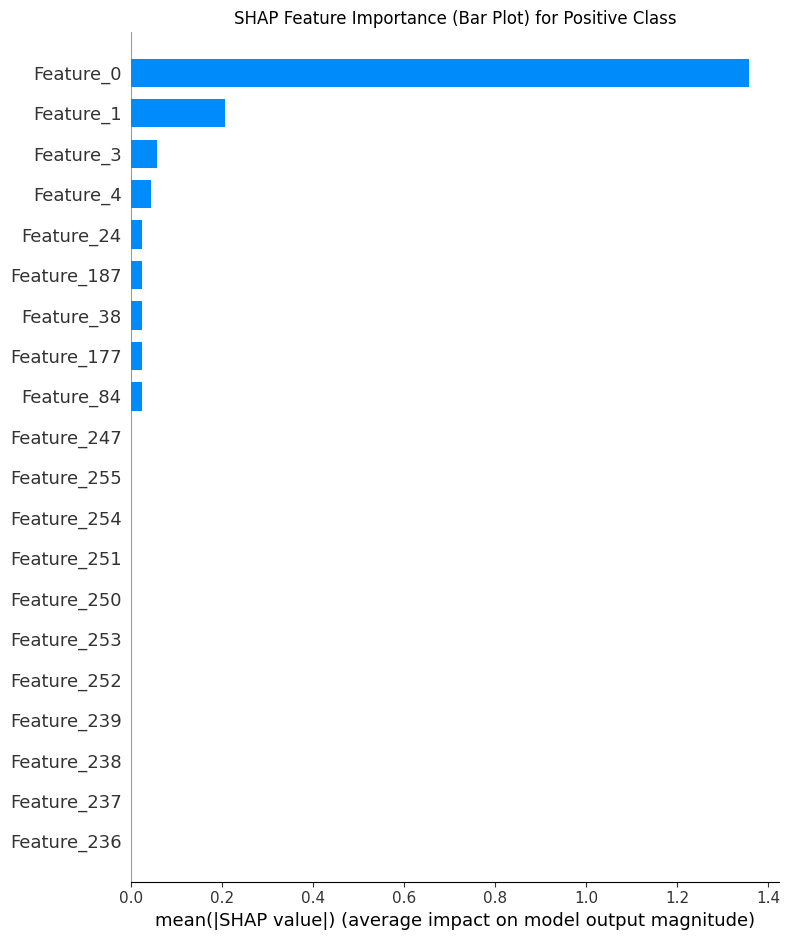

SHAP summary bar plot saved to: /content/drive/MyDrive/Module 1/shapResults/shap_summary_bar.png


In [ ]:
# SHAP Summary Plot (Bar) for the positive class
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot) for Positive Class")
plt.tight_layout()
plt.savefig(os.path.join(SHAP_RESULTS_DIR, "shap_summary_bar.png"))
plt.show()
print(f"SHAP summary bar plot saved to: {os.path.join(SHAP_RESULTS_DIR, 'shap_summary_bar.png')}")

### Global Feature Importance: SHAP Beeswarm Plot

The beeswarm plot shows the distribution of SHAP values for each feature across the dataset, revealing how each feature impacts the model's output for different instances.

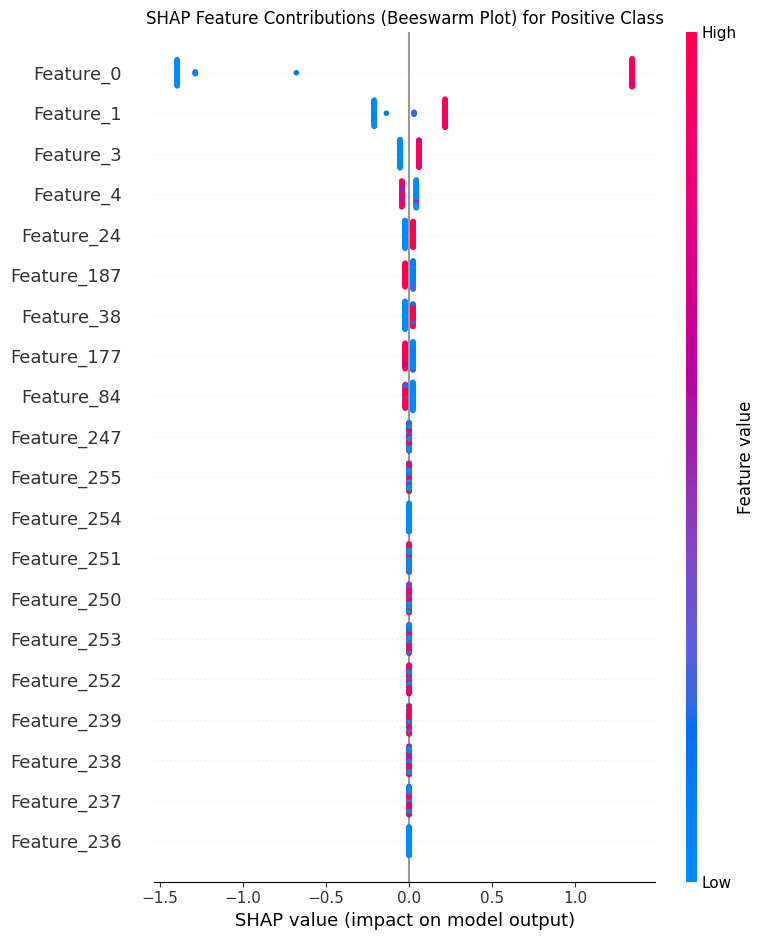

SHAP beeswarm plot saved to: /content/drive/MyDrive/Module 1/shapResults/shap_summary_beeswarm.png


In [ ]:
# SHAP Summary Plot (Beeswarm) for the positive class
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False) # Default is beeswarm
plt.title("SHAP Feature Contributions (Beeswarm Plot) for Positive Class")
plt.tight_layout()
plt.savefig(os.path.join(SHAP_RESULTS_DIR, "shap_summary_beeswarm.png"))
plt.show()
print(f"SHAP beeswarm plot saved to: {os.path.join(SHAP_RESULTS_DIR, 'shap_summary_beeswarm.png')}")

### Local Explanations: SHAP Force Plots

Force plots visualize how individual feature contributions push the prediction from the base value (average prediction) to the final prediction for a specific instance. We will show examples for a correctly classified positive case and a correctly classified negative case.

_Note: SHAP force plots are interactive in a live notebook environment, but will be displayed as static images here (if supported by the rendering environment). Direct saving as a static image is not straightforward with the default `shap.force_plot()` method._

In [ ]:
# Make predictions to find correctly classified samples
y_pred_test = xgb_model.predict(X_test)

# Find a correctly classified positive sample (true_label = 1, predicted_label = 1)
positive_indices = np.where((y_test == 1) & (y_pred_test == 1))[0]
if len(positive_indices) > 0:
    sample_idx_positive = positive_indices[0]
    print(f"Displaying Force Plot for a correctly classified Positive sample (index {sample_idx_positive})...")
    shap.initjs()
    # Corrected: Use scalar explainer.expected_value and shap_values[sample_idx] (a vector for that sample)
    force_plot_positive = shap.force_plot(explainer.expected_value, shap_values[sample_idx_positive], X_test_df.iloc[sample_idx_positive])
    # Display the plot (it's interactive in a live notebook)
    display(force_plot_positive)
else:
    print("No correctly classified positive samples found for force plot demonstration.")

# Find a correctly classified negative sample (true_label = 0, predicted_label = 0)
negative_indices = np.where((y_test == 0) & (y_pred_test == 0))[0]
if len(negative_indices) > 0:
    sample_idx_negative = negative_indices[0]
    print(f"\nDisplaying Force Plot for a correctly classified Negative sample (index {sample_idx_negative})...")
    shap.initjs()
    # Corrected: Use scalar explainer.expected_value and shap_values[sample_idx] (a vector for that sample)
    force_plot_negative = shap.force_plot(explainer.expected_value, shap_values[sample_idx_negative], X_test_df.iloc[sample_idx_negative])
    # Display the plot (it's interactive in a live notebook)
    display(force_plot_negative)
else:
    print("No correctly classified negative samples found for force plot demonstration.")

print("\nNote: SHAP force plots are interactive and not directly savable as static images using `plt.savefig()` with the default `shap.force_plot()` method. They are best viewed in a live notebook session.")

Displaying Force Plot for a correctly classified Positive sample (index 3)...



Displaying Force Plot for a correctly classified Negative sample (index 0)...



Note: SHAP force plots are interactive and not directly savable as static images using `plt.savefig()` with the default `shap.force_plot()` method. They are best viewed in a live notebook session.


### Conceptual Branch-Attributed SHAP Importance

Given the challenges with direct attribution from adaptively fused features, this section presents a conceptual branch-attributed SHAP importance graph. We arbitrarily divide the 256 fused features into two equally sized groups to represent 'Video-dominant Fused Features' and 'Audio-dominant Fused Features'. This allows us to aggregate SHAP values per conceptual branch.

**Note on Interpretation**: The division into 'Video-dominant' and 'Audio-dominant' features is purely *conceptual and arbitrary* for this visualization. The Adaptive Fusion layer creates a complex, non-linear blend of features, so individual fused features do not strictly belong to one modality. This plot serves as an illustrative example under this simplifying assumption.

/tmp/ipykernel_712/2011412660.py:19: UserWarning: [15:29:32] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  xgb_model = pickle.load(f)
/tmp/ipykernel_712/2011412660.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Branch', y='Total_Mean_Abs_SHAP', data=branch_importance_df, palette='viridis')


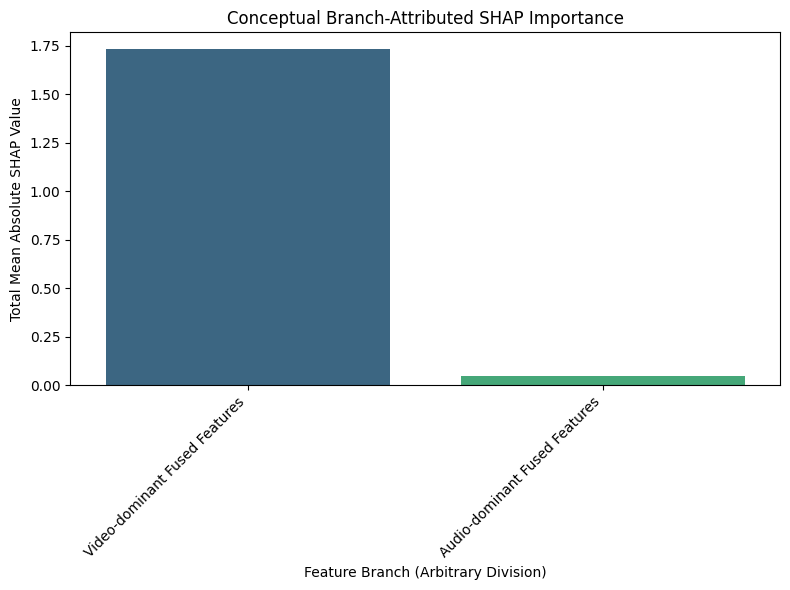

Conceptual branch-attributed SHAP importance plot saved to: /content/drive/MyDrive/Module 1/shapResults/shap_branch_attributed_plot.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import shap
import pickle
import xgboost as xgb

# --- Load necessary components from previous cells to make this block self-contained ---
EXPERIMENT_DIR = "/content/drive/MyDrive/Module 1/Attention_BiLSTM_BiGRU"
FINAL_OPTUNA_DIR = os.path.join(EXPERIMENT_DIR, "optuna_xgboost_final")
SHAP_RESULTS_DIR = "/content/drive/MyDrive/Module 1/shapResults"
os.makedirs(SHAP_RESULTS_DIR, exist_ok=True)

# Load the optimized XGBoost model
optimized_model_path = os.path.join(FINAL_OPTUNA_DIR, "optimized_xgboost.pkl")
with open(optimized_model_path, "rb") as f:
    xgb_model = pickle.load(f)

# Load X_test
FEATURE_DIR = os.path.join(EXPERIMENT_DIR, "fused_features")

def load_features_and_labels(path):
    data = np.load(path, allow_pickle=True)
    keys = list(data.files)
    feature_candidates = ["features", "feature", "X", "x", "fused_features", "fused_feature", "embeddings", "embedding", "data"]
    label_candidates = ["labels", "label", "y", "Y", "targets", "target"]
    feature_key = None
    label_key = None
    for key in feature_candidates:
        if key in keys:
            arr = data[key]
            if arr.ndim >= 2:
                feature_key = key
                break
    for key in label_candidates:
        if key in keys:
            arr = data[key]
            if arr.ndim <= 2:
                label_key = key
                break
    if feature_key is None:
        possible_features = []
        for key in keys:
            arr = data[key]
            if (isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] > 1):
                possible_features.append(key)
        if len(possible_features) == 1:
            feature_key = possible_features[0]
    if label_key is None:
        possible_labels = []
        for key in keys:
            arr = data[key]
            if not isinstance(arr, np.ndarray):
                continue
            if arr.ndim == 1 and len(arr) > 1:
                unique_values = np.unique(arr)
                if len(unique_values) <= 10:
                    possible_labels.append(key)
        if len(possible_labels) == 1:
            label_key = possible_labels[0]
    if feature_key is None or label_key is None:
        raise KeyError("Could not automatically identify feature/label arrays.")
    X = np.asarray(data[feature_key], dtype=np.float32)
    y = np.asarray(data[label_key], dtype=np.int64)
    y = y.reshape(-1)
    unique_labels = np.unique(y)
    if not np.array_equal(unique_labels, np.array([0, 1])):
        mapping = {value: idx for idx, value in enumerate(sorted(unique_labels))}
        y = np.array([mapping[value] for value in y], dtype=np.int64)
    return X, y

X_test, y_test = load_features_and_labels(os.path.join(FEATURE_DIR, "test_features.npz"))

# Initialize SHAP TreeExplainer and calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Generate feature names for plotting
feature_names = [f"Feature_{i}" for i in range(X_test.shape[1])]
# --- End of necessary component loading ---


# Calculate mean absolute SHAP values for each feature
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

# Arbitrarily divide features into conceptual video and audio components
# Assuming 128 features for video and 128 for audio for illustrative purposes
num_video_features = 128
num_audio_features = 128

# Ensure the total features match the SHAP values dimension
if len(mean_abs_shap_values) != (num_video_features + num_audio_features):
    print(f"Warning: Total feature count ({len(mean_abs_shap_values)}) does not match assumed split ({num_video_features + num_audio_features}). Adjusting split.")
    # If the total doesn't match, dynamically adjust for plotting
    total_features = len(mean_abs_shap_values)
    num_video_features = total_features // 2
    num_audio_features = total_features - num_video_features

# Aggregate SHAP importance for each conceptual branch
video_branch_shap_importance = mean_abs_shap_values[:num_video_features].sum()
audio_branch_shap_importance = mean_abs_shap_values[num_video_features:].sum()

# Create a DataFrame for plotting
branch_importance_df = pd.DataFrame({
    'Branch': ['Video-dominant Fused Features', 'Audio-dominant Fused Features'],
    'Total_Mean_Abs_SHAP': [video_branch_shap_importance, audio_branch_shap_importance]
})

# Plotting the branch-attributed importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Branch', y='Total_Mean_Abs_SHAP', data=branch_importance_df, palette='viridis')
plt.title('Conceptual Branch-Attributed SHAP Importance')
plt.ylabel('Total Mean Absolute SHAP Value')
plt.xlabel('Feature Branch (Arbitrary Division)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the plot
shap_branch_plot_path = os.path.join(SHAP_RESULTS_DIR, "shap_branch_attributed_plot.png")
plt.savefig(shap_branch_plot_path)
plt.show()

print(f"Conceptual branch-attributed SHAP importance plot saved to: {shap_branch_plot_path}")